# 📘 机器学习 + 深度学习 基础完整笔记

> 一份**自包含、可运行、带可视化与记忆标记**的完整学习笔记，覆盖机器学习与深度学习的全部基础内容。

## 课程来源

- 📺 **主课程**：2026 李宏毅机器学习入门（B 站，共 67 讲）
  👉 https://www.bilibili.com/video/BV1RnikBvE8m
- 📺 **辅助教材**：李沐《动手学深度学习 V2》（PyTorch 版，用于补充 PyTorch 实战）
  👉 https://www.bilibili.com/video/BV1EY6FBwE8P
- 🎯 **结合材料**：`暑假40天学习计划_张豪实验室_米哈游游戏测试.docx`（第三阶段「机器学习入门 + PyTorch 实战」）

## 笔记结构

- **第一部分：机器学习基础**（课程主线）—— 第一章 ~ 第十章
- **第二部分：深度学习**（课程主线）—— 第十一章 ~ 第十三章
- **第三部分：PyTorch 实战与进阶**（40 天计划补充）—— 第十四章 ~ 第十九章
- **附录**：公式速查表 + 记忆清单

## 使用说明

1. 请从**第一个代码单元格**开始**按顺序运行**，后面的代码会复用前面定义好的变量与函数；
2. 每个代码单元格都加了详细注释，标了 `🔑 记忆` 的写法是需要背下来的；
3. 图表全部用 matplotlib 绘制，`plt.rcParams` 已配好中文显示。

## 标记说明

| 标记 | 含义 |
| --- | --- |
| 📌 **出处** | 这段内容来自课程哪一讲 / 哪个视频 / 40 天计划哪一天 |
| 🔑 **记忆** | 需要**背下来**的公式、代码写法、关键结论 |
| ⭐ | 40 天学习计划点名的**重点**（对应实验室 / 米哈游岗位要求） |
| 💡 | 补充的直觉理解 / 易错点提醒 |

---


In [1]:
# ==================== 环境准备（全笔记的第一个代码单元格）====================
# 后面所有章节都会复用这里导入的库、字体设置和配色，请务必先运行本格。

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

# 让 matplotlib 能正常显示中文（Windows 常见字体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False   # 让负号 "-" 正常显示

# 全笔记统一配色（风格一致，方便看图）
蓝 = '#2b7bba'   # 主色：数据点 / 类别 A
橙 = '#e69f00'   # 强调：拟合线 / 类别 B
灰 = '#999999'   # 辅助：真实值 / 背景
红 = '#d62728'   # 警示：发散 / 过拟合
绿 = '#2ca02c'   # 成功：收敛 / 正确
紫 = '#9467bd'   # 第三类

np.random.seed(0)   # 固定随机种子，保证结果可复现
torch.manual_seed(0)   # 固定 PyTorch 随机种子

print("✓ 环境准备完成：numpy", np.__version__, "| torch", torch.__version__)


✓ 环境准备完成：numpy 2.2.5 | matplotlib 3.10.9


# 📑 目录

> 本笔记按**课程主线**组织为「机器学习基础 → 深度学习 → PyTorch 实战」三部分，外加「李沐 d2l 补充章节」和附录。共 **23 章 + 附录**。请按顺序阅读，每章的「📌 出处」都标注了对应的课程讲次，方便回到 B 站对照原视频；标注「李沐《动手学深度学习 V2》」的小节为后续融合进来的补充内容，配套代码在 `实战代码_李沐/` 文件夹。

---

## 第一部分 · 机器学习基础

**第一章 机器学习基本概念**（课程第 1 讲）
- 1.1 机器学习是什么：从「人写规则」到「机器自己找函数」
- 1.2 三大类型：回归 / 分类 / 结构化学习
- 1.3 三种学习方式：监督 / 无监督 / 强化学习
- 1.4 训练三步曲：模型 → 损失 → 优化
- 1.5 损失函数 Loss：给参数「打分」的标准
- 1.6 梯度下降：一步步滑向损失最低点
- 1.7 学习率：步长是门学问
- 1.8 过拟合与正则化直觉
- 1.9 本章小结

**第二章 深度学习基本概念**（课程第 2 讲）
- 2.1 神经网络：一大堆「神经元」搭起来的函数
- 2.2 单个神经元：加权求和 + 激活函数
- 2.3 激活函数：Sigmoid / tanh / ReLU
- 2.4 层、深度：把神经元叠起来
- 2.5 训练神经网络，还是那「三步曲」
- 2.6 本章小结

**第三章 机器学习任务攻略：偏差、方差与交叉验证**（课程第 3 讲）
- 3.1 模型效果不好，怎么办
- 3.2 数据三划分：训练 / 验证 / 测试
- 3.3 诊断：对比训练误差和验证误差
- 3.4 偏差与方差
- 3.5 对症下药：欠拟合和过拟合怎么解决
- 3.6 交叉验证 Cross-Validation
- 3.7 模型验证：训练/验证/测试 + K 折 + 学习曲线（李沐 实用ML）
- 3.8 本章小结

**第四章 线性回归与正规方程**（课程第 4~9 讲）
- 4.1 线性回归：最基础的模型
- 4.2 代价函数 MSE
- 4.3 正规方程：一步解出最优参数
- 4.4 正规方程的推导
- 4.5 sklearn 实战：LinearRegression
- 4.6 线性回归从零实现（李沐 d2l）
- 4.7 线性回归简洁实现（李沐 d2l）
- 4.8 本章小结

**第五章 梯度下降**（课程第 10~17 讲）
- 5.1 回顾：梯度下降在做什么
- 5.2 三种梯度下降：BGD / SGD / MBGD
- 5.3 学习率与特征缩放
- 5.4 动量 Momentum
- 5.5 本章小结

**第六章 Batch 与优化器**（课程第 22~35 讲）
- 6.1 Batch Size：一次更新用多少数据
- 6.2 局部最小值 vs 鞍点
- 6.3 为什么需要「自动调整学习率」
- 6.4 三种优化器：AdaGrad / RMSProp / Adam
- 6.5 学习率调度
- 6.6 Adadelta：连学习率都不用设（李沐 d2l）
- 6.7 凸性：为什么凸优化能保证收敛（李沐 d2l）
- 6.8 本章小结

**第七章 特征工程**（课程第 36~40 讲）
- 7.1 什么是特征工程
- 7.2 特征缩放：Min-Max / Z-Score
- 7.3 类别编码：label / one-hot
- 7.4 缺失值处理
- 7.5 特征组合
- 7.6 特征选择
- 7.7 数据获取、EDA 与数据清理（李沐 实用ML）
- 7.8 本章小结

**第八章 过拟合与正则化**（课程第 41~50 讲）
- 8.1 过拟合的本质与正则化思路
- 8.2 L2 正则化：岭回归 Ridge
- 8.3 L1 正则化：套索回归 Lasso
- 8.4 L1 vs L2：几何直觉
- 8.5 ElasticNet
- 8.6 权重衰减与 Dropout
- 8.7 早停 Early Stopping
- 8.8 权重衰减与 Dropout 的 PyTorch 实现（李沐 d2l）
- 8.9 本章小结

**第九章 逻辑回归**（分类专题）
- 9.1 从「预测数值」到「预测类别」
- 9.2 Sigmoid 函数
- 9.3 决策边界
- 9.4 交叉熵损失
- 9.5 多分类：OVR 与 Softmax
- 9.6 sklearn 实战
- 9.7 softmax 从零实现（李沐 d2l）
- 9.8 softmax 简洁实现（李沐 d2l）
- 9.9 本章小结

**第十章 损失函数全家桶**（损失函数专题）
- 10.1 损失函数：模型和优化器之间的「裁判」
- 10.2 MSE
- 10.3 MAE
- 10.4 交叉熵
- 10.5 Hinge Loss
- 10.6 怎么选：一张表记住
- 10.7 本章小结

---

## 第二部分 · 深度学习

**第十一章 神经网络与反向传播**（神经网络专题）
- 11.1 从逻辑回归到神经网络
- 11.2 前向传播
- 11.3 反向传播：链式法则
- 11.4 反向传播逐步推导
- 11.5 完整训练循环：XOR
- 11.6 梯度消失与梯度爆炸
- 11.7 多层感知机 MLP：从零与简洁实现（李沐 d2l）
- 11.8 本章小结

**第十二章 卷积神经网络 CNN**（CNN 专题）
- 12.1 为什么图像不能用全连接
- 12.2 卷积操作
- 12.3 步长与填充
- 12.4 池化 Pooling
- 12.5 经典结构：LeNet
- 12.6~12.12 现代 CNN（李沐 d2l）：AlexNet / VGG / NiN / GoogLeNet / BatchNorm / ResNet / DenseNet
- 12.13 本章小结

**第十三章 Transformer 与注意力机制**（Transformer 专题）
- 13.1 从 CNN 到 Transformer
- 13.2 Query / Key / Value
- 13.3 自注意力 Self-Attention
- 13.4 多头注意力 Multi-Head
- 13.5 位置编码
- 13.6 Transformer 完整结构
- 13.7 注意力评分函数：加性 vs 缩放点积（李沐 d2l）
- 13.8 Bahdanau 注意力：注意力用于 seq2seq（李沐 d2l）
- 13.9 本章小结

---

## 第三部分 · PyTorch 实战与进阶（40 天计划补充）

**第十四章 PyTorch 基础：Tensor 与 Autograd**
- 14.1 为什么需要 PyTorch
- 14.2 Tensor 张量
- 14.3 Autograd 自动求导
- 14.4 Autograd 三个关键细节
- 14.5 预备知识·线性代数（李沐 d2l）
- 14.6 预备知识·概率（李沐 d2l）
- 14.7 数据预处理与查阅文档（李沐 d2l）
- 14.8 本章小结

**第十五章 数据加载与数据增强**
- 15.1 Dataset 和 DataLoader
- 15.2 DataLoader 三个关键参数
- 15.3 数据增强
- 15.4 图像数据标准流水线
- 15.5 图像增广：翻转/裁剪/颜色抖动（李沐 d2l）
- 15.6 本章小结

**第十六章 模型搭建与标准训练循环**
- 16.1 用 nn.Module 定义模型
- 16.2 常用层
- 16.3 损失函数与优化器
- 16.4 标准训练循环（五段式）
- 16.5 分类训练循环（含准确率）
- 16.6 保存与加载 checkpoint
- 16.7 深度学习计算：自定义块/参数管理/读写模型（李沐 d2l）
- 16.8 本章小结

**第十七章 模型评估：混淆矩阵、精确率、召回率、F1**
- 17.1 为什么「准确率」不够用
- 17.2 混淆矩阵
- 17.3 精确率与召回率
- 17.4 F1 分数
- 17.5 ROC 与 AUC
- 17.6 多分类评估
- 17.7 本章小结

**第十八章 迁移学习**
- 18.1 为什么需要迁移学习
- 18.2 底层通用、高层专用
- 18.3 特征提取 vs 微调
- 18.4 PyTorch 迁移学习标准流程
- 18.5 常见预训练模型
- 18.6 本章小结

**第十九章 大模型概念：GPT、LLaMA 与 LoRA**
- 19.1 什么是大语言模型
- 19.2 GPT 与自回归生成
- 19.3 LLaMA 与开源大模型
- 19.4 训练三阶段：预训练 → 微调 → 对齐
- 19.5 LoRA 低秩适配
- 19.6 大模型使用的重要概念
- 19.7 本章小结
---

## 第四部分 · 李沐《动手学深度学习 V2》补充章节

> 以下章节为李沐 d2l 的补充内容（现有笔记原缺），逻辑上属于「深度学习」（RNN 是序列模型，位于 CNN 与 Transformer 之间），编号接在现有章节之后、放在附录之前。

**第二十章 循环神经网络 RNN**（d2l 第 8 章）
- 20.1 为什么需要 RNN：处理「序列」数据
- 20.2 循环结构：隐藏状态 + 参数共享
- 20.3 从零 vs 简洁实现
- 20.4 通过时间反向传播 BPTT

**第二十一章 现代循环神经网络：GRU / LSTM / seq2seq**（d2l 第 9 章）
- 21.1 为什么要「门」：RNN 记不住长依赖
- 21.2 GRU（门控循环单元）
- 21.3 LSTM（长短期记忆网络）
- 21.4 seq2seq 与机器翻译

**第二十二章 计算机视觉实战：目标检测 / 语义分割 / 风格迁移**（d2l 第 13 章）
- 22.1 计算机视觉的四大任务
- 22.2 目标检测：边界框与锚框
- 22.3 IoU 与非极大值抑制 NMS
- 22.4 单发多框检测 SSD
- 22.5 语义分割与转置卷积
- 22.6 全卷积网络 FCN
- 22.7 风格迁移：内容 + 风格损失

**第二十三章 树模型与集成学习**（李沐《实用机器学习》）
- 23.1 为什么表格数据用树模型
- 23.2 决策树：递归切分
- 23.3 随机森林：并行投票（降方差）
- 23.4 梯度提升树 GBDT：串行补漏（降偏差）
- 23.5 集成三大流派对比
- 23.6 树模型 vs 深度学习：怎么选
- 23.7 本章小结

---

## 附录

**附录：公式速查表与记忆清单**
- A.1 公式速查表
- A.2 记忆清单（全书 🔑 汇总）
- A.3 学习路线回顾
- A.4 40 天计划与本笔记的对照

---


# 第一部分 · 机器学习基础

# 第一章 机器学习基本概念

> 📌 **出处**：李宏毅 2026《机器学习》**第 1 讲「机器学习基本概念简介」**（B 站 BV1RnikBvE8m）
> ⭐ **40 天重点**：这一章是整个系列的地基。对应 40 天计划 Day11「最优化基础」与 Day15「机器学习概览」的能力要求——*理解监督/无监督学习、损失函数、梯度下降、过拟合与正则化*。

---

## 1.1 机器学习是什么：从「人写规则」到「机器自己找函数」

要理解机器学习，先看传统程序和机器学习的区别。

**传统程序**是人把规则一条条写死：程序员先想清楚「遇到什么情况该做什么」，再用 `if / else` 把这些规则翻译成代码。比如判断一封邮件是不是垃圾邮件，传统做法是人工总结一堆规则：出现了「中奖」两个字 → 加 2 分；出现了「点击链接」→ 加 1 分；分数超过阈值 → 判为垃圾邮件。

这种做法的致命问题是：**规则是人想出来的，而人的经验往往是片面的、难以穷尽的**。垃圾邮件的花样每天都在变，你今天写死「中奖」两个字，明天骗子就改成「恭喜您抽中」——你的规则就失效了。对于人脸识别、语音识别、下围棋这类任务，人根本无法用几条规则描述清楚「怎么做」，更别说写出来。

**机器学习**换了一种思路：我不再手写规则，而是**让机器自己从数据里找出一个「函数」**。

$$\text{机器学习} = \text{根据数据，自动找出一个函数 } f:\ \text{输入} \to \text{输出}$$

这里要理解三个东西：

- **输入（input）**：给机器的原材料。可以是一张图片、一段语音、一行表格数据、一段文字……
- **输出（output）**：机器要给出的结果。可以是一个数值、一个类别、一段文字、一张图……
- **函数 $f$**：把输入映射到输出的那个「规则」。在机器学习里，这个函数不是人写的，而是**由一堆参数（parameter）决定**、再由机器「学」出来的。这个函数就是所谓的**模型（model）**。

> 💡 李宏毅老师最经典的一句话：**机器学习就是让机器自己寻找一个函数**。你只需要给它数据和目标，它负责把「输入 → 输出」的映射关系找出来。

举几个具体例子，感受一下「函数」这个抽象说法到底指什么：

| 任务 | 输入（函数的自变量） | 输出（函数的因变量） | 这个函数 $f$ 是什么 |
| --- | --- | --- | --- |
| 预测房价 | 面积、地段、房龄、楼层…… | 一个数值（房价） | 一条「特征 → 价格」的规则 |
| 识别猫狗 | 一张图片 | 一个类别（猫 / 狗） | 一条「图片 → 标签」的规则 |
| 语音识别 | 一段声音波形 | 一句话 | 一条「声音 → 文字」的规则 |

所以整个机器学习，本质上就是在回答一个问题：**怎么找到这个函数 $f$？** 后面所有章节，都在为「找函数」服务——先确定函数的「候选形式」（模型），再定义一个「打分标准」判断哪个函数好（损失），最后用算法把最好的那个函数挑出来（优化）。


## 1.2 机器学习的三大类型：按「输出长什么样」分类

机器学习的任务五花八门，但按照**函数输出的类型**，可以干净地分成三大类。这个分类很重要，因为它直接决定了后面你要选什么模型、用什么损失函数。

### ① 回归（Regression）：输出一个数值

如果函数输出的**一个连续的数值**，就叫回归任务。它的核心特点是：**输出是"多少"**。

- 预测明天的气温（多少度）
- 预测某个房子的价格（多少万）
- 预测 PM2.5 浓度（多少微克/立方米）
- 预测股票明天的涨跌幅（百分之几）

回归的输出是一个可以在数轴上连续取值的实数。评价回归好坏的标准也很自然：**预测的数值和真实数值差多少**。

### ② 分类（Classification）：输出一个类别

如果函数输出的是**一个离散的类别**，就叫分类任务。它的核心特点是：**输出是"是哪一个"**。

- 判断一封邮件是不是垃圾邮件（是 / 否，二分类）
- 识别图片里是猫还是狗（猫 / 狗 / ……，多分类）
- 判断病人有没有某种疾病（有 / 无）

分类的输出是有限个「选项」中的一个。注意：很多分类模型内部其实先算出一个「属于每个类别的概率」，再挑概率最大的那个类别作为输出——这个细节在第九章逻辑回归会展开。

### ③ 结构化学习（Structured Learning）：输出一个「有结构」的对象

如果函数输出的是一个**有结构的、复杂的对象**，就叫结构化学习。所谓「有结构」，指的是输出不是一个数也不是一个标签，而是一整段东西：

- 机器翻译：输入一句英文，输出一句中文（输出是一整个句子）
- 语音识别：输入一段声音，输出一段文字
- 图像生成：输入一段文字描述，输出一张图片
- 现在大火的大语言模型（LLM，如 ChatGPT）本质上就是结构化学习——输入一句话，输出一句话

> 📌 本系列课程的主线是**监督学习下的回归与分类**（这是机器学习最基础、最核心的两类），先把这两类彻底吃透，结构化学习（尤其是 Transformer、大模型）在第十三章和第十九章会讲。


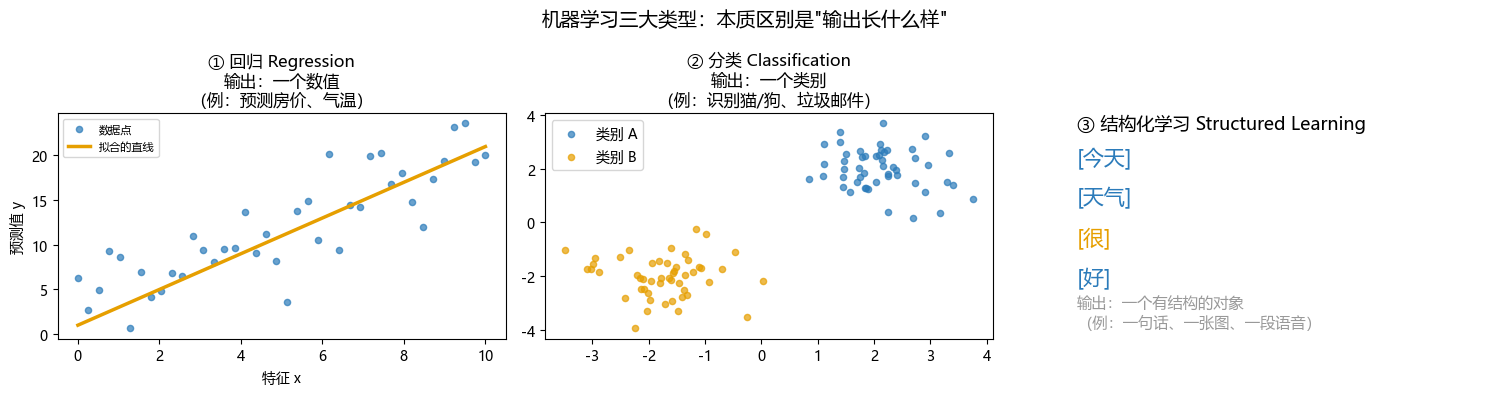

In [2]:
# ---- 机器学习三大类型：回归 / 分类 / 结构化学习 的可视化 ----
# 用三张图直观感受三种任务的"输出"到底长什么样

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ① 回归：输出是一个连续的数值
#    数据是一堆散点，模型是一条穿过它们的直线（拟合），
#    对一个新的 x，模型给出一个对应的 y（数值）。
x = np.linspace(0, 10, 40)
y = 2 * x + 1 + np.random.randn(40) * 3          # 真实关系 y=2x+1 再加噪声
axes[0].scatter(x, y, color=蓝, alpha=0.7, s=20, label='数据点')
axes[0].plot(x, 2 * x + 1, color=橙, lw=2.5, label='拟合的直线')
axes[0].set_title('① 回归 Regression\n输出：一个数值\n（例：预测房价、气温）')
axes[0].set_xlabel('特征 x'); axes[0].set_ylabel('预测值 y')
axes[0].legend(fontsize=8)

# ② 分类：输出是一个离散的类别
#    两堆不同颜色的点，模型要找一条"边界"把它们分开，
#    对一个新的点，模型判断它属于 A 类还是 B 类。
np.random.seed(1)
A = np.random.randn(50, 2) * 0.8 + [2, 2]        # 类别 A（右上）
B = np.random.randn(50, 2) * 0.8 + [-2, -2]      # 类别 B（左下）
axes[1].scatter(A[:, 0], A[:, 1], color=蓝, alpha=0.7, s=20, label='类别 A')
axes[1].scatter(B[:, 0], B[:, 1], color=橙, alpha=0.7, s=20, label='类别 B')
axes[1].set_title('② 分类 Classification\n输出：一个类别\n（例：识别猫/狗、垃圾邮件）')
axes[1].legend()

# ③ 结构化学习：输出一个有结构的对象
#    示意：输入一句话，输出一句话（每个词都是输出结构的一部分）。
句子 = ['今天', '天气', '很', '好']
axes[2].axis('off')
for i, w in enumerate(句子):
    axes[2].text(0.1, 0.78 - i * 0.18, f'[{w}]', fontsize=15,
                 color=[蓝, 蓝, 橙, 蓝][i], transform=axes[2].transAxes)
axes[2].text(0.1, 0.93, '③ 结构化学习 Structured Learning', fontsize=13, transform=axes[2].transAxes)
axes[2].text(0.1, 0.05, '输出：一个有结构的对象\n（例：一句话、一张图、一段语音）',
             fontsize=11, color=灰, transform=axes[2].transAxes)

plt.suptitle('机器学习三大类型：本质区别是"输出长什么样"', fontsize=14)
plt.tight_layout()
plt.show()


## 1.3 按「有没有标准答案」分类：监督 / 无监督 / 强化学习

除了按输出类型分，机器学习还有另一种重要的分法——**按训练数据「有没有标准答案」来分**。这个分类回答的问题是：机器在学习时，能不能看到「这道题的正确答案」。

### 监督学习（Supervised Learning）：有标准答案

训练数据里，**每一个输入都配了一个正确的输出（标签 label）**。机器学的就是「输入 → 正确答案」的映射。

- 给机器看 1 万张图片，每张都标好了「这是猫 / 这是狗」，机器学「看图 → 判猫狗」。
- 给机器看 1 万条历史房价记录，每条都标好了真实成交价，机器学「特征 → 房价」。

打个比方：监督学习就像**有老师拿着标准答案批改作业**——你做错了，老师告诉你正确答案是什么，你照着改。前面说的回归和分类，绝大多数都属于监督学习（因为训练时确实知道正确答案）。**本系列课程的主线就是监督学习。**

### 无监督学习（Unsupervised Learning）：没有标准答案

训练数据**没有标签**，机器要自己在数据里「发现结构」。机器不知道「正确答案」是什么，只能靠数据本身的规律。

- **聚类**：把一堆没有标签的样本自动分成几群（比如把用户自动分成几类人群）。
- **降维**：把高维数据压缩到低维，同时尽量保留信息（比如 PCA 主成分分析）。

打个比方：无监督学习就像**没有老师，只有一堆没有答案的题目**，你得自己发现这些题目之间有什么共性、能分成几类。

### 强化学习（Reinforcement Learning）：只有奖励，没有标准答案

既没有标签，但环境会给一个**奖励 / 惩罚信号（reward）**，机器通过「试错」不断调整策略，目标是让累计奖励最大。

- AlphaGo 下围棋：没有人告诉它每一步「正确答案」是什么，但它赢了会得到奖励，输了得到惩罚，久而久之学会下棋。
- 游戏 AI：让机器自己玩，赢了加分、输了扣分，它慢慢学会怎么玩。

打个比方：强化学习就像**训练宠物**——没有标准答案，做对了给零食、做错了不给，它自己摸索出「怎么做才能吃到零食」。

> 💡 三种学习方式的核心区别只有一句话：**监督学习看答案，无监督学习看规律，强化学习看奖励。** 本课程先全力攻克监督学习。


## 1.4 训练三步曲：模型 → 损失 → 优化

这是**全系列最重要的一张地图**。李宏毅老师把「训练一个机器学习模型」总结成三个步骤，后面学任何模型——线性回归、逻辑回归、神经网络、Transformer——都逃不出这三步。所以这一节要彻底理解，而不是背过。

### Step 1 定义模型：先猜一个「带未知参数的函数」

我们要找函数 $f$，但函数有无数种可能（直线、曲线、折线、乱七八糟的……）。第一步是**缩小搜索范围**：先假设函数长成某种「形式」，这个形式里带一些**未知的参数（unknown parameters）**。

最经典的例子是**线性模型**：

$$y = w \cdot x + b$$

- $x$ 是输入特征，$y$ 是输出，这些都是数据给的，是「已知」的；
- $w$（权重 weight）和 $b$（偏置 bias）是**未知参数**——我们暂时不知道它们该是多少。

这个式子「定义」了一整个**函数族**：$w$、$b$ 每取一组不同的值，就得到一条不同的直线。所谓「训练模型」，本质就是**在这个函数族里，把 $w$、$b$ 调成最合适的那组值**。

> 💡 所以「模型」这个词在机器学习里有两层含义：一是指「函数的形式」（比如线性模型这个模板），二是指「一组具体的参数」（比如 $w=2,\ b=1$ 这条具体的直线）。听课时注意区分语境。

### Step 2 定义损失：给每组参数「打分」

现在函数族里有无数组 $(w, b)$，哪一组好、哪一组差？需要一个**打分标准**，这就是**损失函数（loss function）** $L(w,b)$：

- 它的输入是**一组参数**（比如一组 $(w,b)$）；
- 它的输出是**一个数**——这组参数有多「差」；
- **损失越大 = 这组参数越差；损失越小 = 这组参数越好**。

怎么衡量「差」？很自然：把这组参数代入模型，算出预测值，再看**预测值和真实答案差多少**。差得越多，损失越大。最常用的是**均方误差 MSE**（下一节细讲）。

### Step 3 优化：找一组参数让损失最小

有了打分标准，最后一步就是：**在函数族里，找到让损失最小的那组参数**。怎么找？

- 一种办法是**暴力搜索**：把所有可能的 $(w,b)$ 都试一遍，谁损失最小就选谁。但参数是连续的、有无数种取值，根本试不完。
- 更聪明的办法是**梯度下降（gradient descent）**：从某个初始点出发，每次朝「损失下降最快」的方向挪一小步，反复迭代，一步步逼近最低点。这是机器学习最核心的优化算法，1.6 节详细讲。

> 🔑 **记忆**：**模型 → 损失 → 优化**，这三步是机器学习所有方法的共同骨架。后面遇到任何新模型，都先问三个问题：① 它的函数形式是什么？② 它的损失函数怎么定义？③ 它用什么优化算法？


训练结果：w ≈ 1.986（真实 2.0），b ≈ 0.998（真实 1.0）
损失从 4.32 一路降到 0.0118


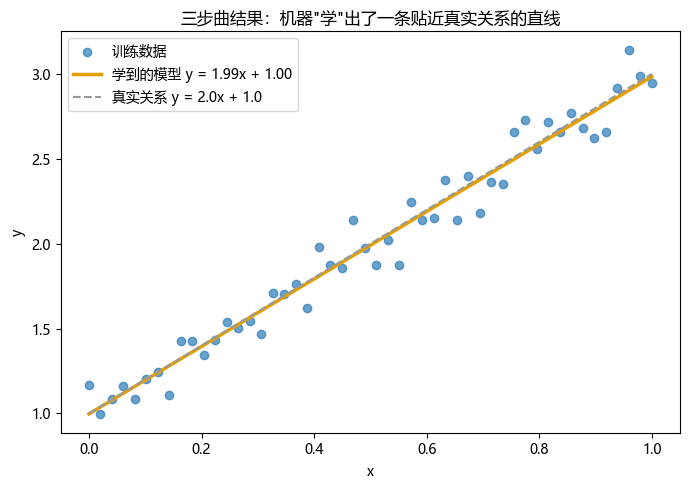

In [3]:
# ---- 训练三步曲完整演示：用线性模型 y = w·x + b 拟合数据 ----
# 下面把"三步曲"走一遍，让抽象概念落地成具体代码。
np.random.seed(7)

# 造一批"带噪声"的数据。真实关系是 y = 2x + 1，但我们假装不知道，
# 手上只有一堆 (x, y) 数据点，要让机器自己"猜"出这条关系。
X = np.linspace(0, 1, 50)                            # 特征 x，归一化到 [0,1] 让梯度下降更稳
真实w, 真实b = 2.0, 1.0
y = 真实w * X + 真实b + np.random.randn(50) * 0.1    # 目标值：真实关系 + 一点噪声

# ============ Step 1：定义模型（带未知参数的函数）============
def 模型(x, w, b):
    """线性模型 y = w·x + b。w、b 是未知参数，训练的目的就是把它们找出来。"""
    return w * x + b

# ============ Step 2：定义损失（MSE 均方误差）============
def 损失(w, b):
    """给一组 (w, b) 打分：预测值和真实值的平均平方误差，越小越好。"""
    y_pred = 模型(X, w, b)                    # 用当前参数算预测值
    return np.mean((y_pred - y) ** 2)         # 平均平方误差

# ============ Step 3：优化（梯度下降）============
w, b = 0.0, 0.0                 # 随便给个初始参数（从 (0,0) 出发）
学习率 = 0.2
轨迹 = [(w, b, 损失(w, b))]     # 记录每一步的参数和损失，之后画轨迹用

for _ in range(300):
    y_pred = 模型(X, w, b)
    # MSE 对 w、b 的梯度（求偏导）。这两行是手推出来的，1.6 节会解释怎么来。
    dw = np.mean(2 * (y_pred - y) * X)     # ∂L/∂w
    db = np.mean(2 * (y_pred - y))         # ∂L/∂b
    w -= 学习率 * dw                        # 参数沿着负梯度方向更新
    b -= 学习率 * db
    轨迹.append((w, b, 损失(w, b)))

print(f"训练结果：w ≈ {w:.3f}（真实 {真实w}），b ≈ {b:.3f}（真实 {真实b}）")
print(f"损失从 {轨迹[0][2]:.2f} 一路降到 {轨迹[-1][2]:.4f}")

# 画出拟合结果：机器"学"出的直线 vs 真实关系
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X, y, color=蓝, alpha=0.7, label='训练数据')
ax.plot(X, 模型(X, w, b), color=橙, lw=2.5, label=f'学到的模型 y = {w:.2f}x + {b:.2f}')
ax.plot(X, 模型(X, 真实w, 真实b), color=灰, lw=1.5, ls='--', label=f'真实关系 y = {真实w}x + {真实b}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('三步曲结果：机器"学"出了一条贴近真实关系的直线')
ax.legend()
plt.tight_layout()
plt.show()


## 1.5 损失函数 Loss：给参数「打分」的标准

上一节的 Step 2 提到，损失函数用来衡量一组参数有多差。这一节把它讲透——因为**损失函数选得对不对，直接决定了模型学出来的东西对不对**。

### 为什么需要损失函数？

训练模型就是「在一堆候选函数里挑最好的」。要「挑」，就得有「标准」。损失函数就是这个标准：**给每一组参数打一个分数（损失值），分数越低说明这组参数越好**。

### 最常用的：均方误差 MSE（Mean Squared Error）

对回归问题，最自然的标准是看「预测值和真实值差多少」。但「差多少」有好几种度量方式，最常用的是**均方误差**：

$$L = \frac{1}{n}\sum_{i=1}^{n}\big(\hat y_i - y_i\big)^2$$

逐项解释：

- $\hat y_i$：第 $i$ 个样本的**预测值**（把 $x_i$ 代入模型算出来的）；
- $y_i$：第 $i$ 个样本的**真实值**（数据里给的答案）；
- $(\hat y_i - y_i)^2$：这条样本的**误差的平方**。为什么要平方？因为误差有正有负，直接相加会互相抵消；平方之后所有误差都变正，而且**误差越大，被惩罚得越狠**（误差 2 的平方是 4，误差 10 的平方是 100，差 5 倍误差被罚 25 倍）；
- $\frac{1}{n}\sum$：对所有样本取**平均**，得到一个「平均而言差多少」的数。

### 另外两个常见的：MAE 和交叉熵

- **平均绝对误差 MAE**：$L = \frac{1}{n}\sum_i |\hat y_i - y_i|$。和 MSE 的区别是**取绝对值而不是平方**，所以对「个别特别大的误差（离群点）」没那么敏感——因为大误差不会被平方放大。
- **交叉熵 Cross-Entropy**：分类问题专用的损失函数，衡量「预测的概率分布」和「真实的概率分布」有多像。这个在第九章逻辑回归会完整推导。

> 💡 一句话总结：**损失函数就是「打分表」，给每组参数打分，分数越低（损失越小）参数越好。优化的目标就是让这个分数尽量低。** 更完整的损失函数对比（含 Hinge Loss 等）见第十章。


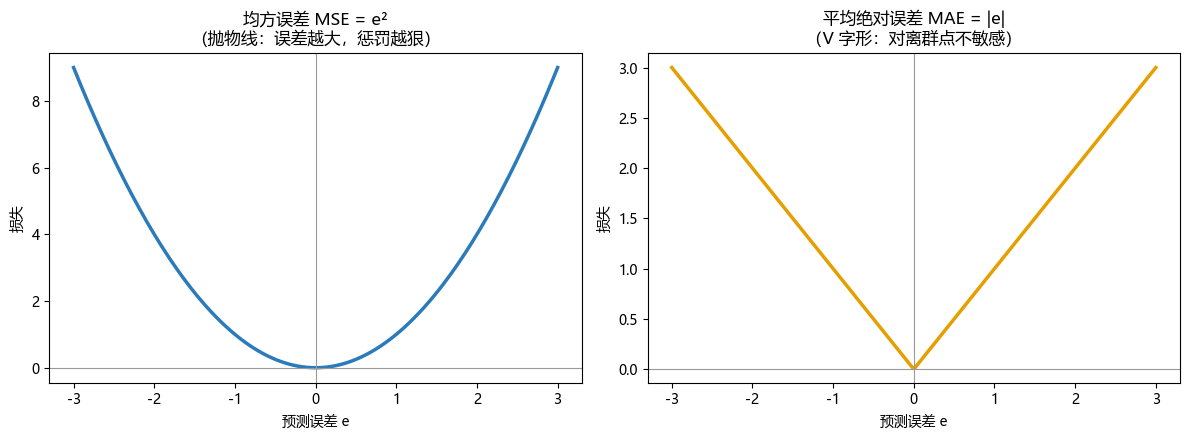

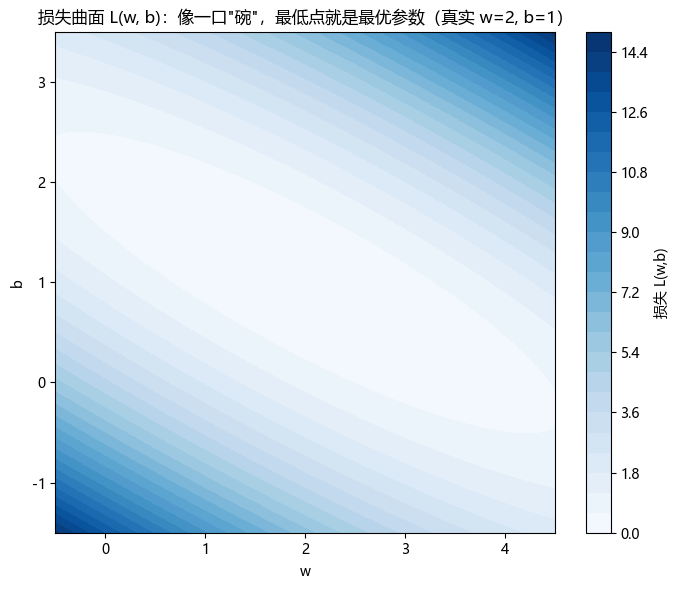

In [4]:
# ---- 损失函数可视化：误差 e 越大，损失越大 ----
# 画出 MSE 和 MAE 的形状，直观理解"平方"和"绝对值"的区别。
e = np.linspace(-3, 3, 200)     # 预测误差 e = y_pred - y（正负都可能）

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 左：MSE = e²（抛物线）
axes[0].plot(e, e**2, color=蓝, lw=2.5)
axes[0].axhline(0, color=灰, lw=0.8); axes[0].axvline(0, color=灰, lw=0.8)
axes[0].set_title('均方误差 MSE = e²\n（抛物线：误差越大，惩罚越狠）')
axes[0].set_xlabel('预测误差 e'); axes[0].set_ylabel('损失')

# 右：MAE = |e|（V 字形）
axes[1].plot(e, np.abs(e), color=橙, lw=2.5)
axes[1].axhline(0, color=灰, lw=0.8); axes[1].axvline(0, color=灰, lw=0.8)
axes[1].set_title('平均绝对误差 MAE = |e|\n（V 字形：对离群点不敏感）')
axes[1].set_xlabel('预测误差 e'); axes[1].set_ylabel('损失')

plt.tight_layout()
plt.show()

# ---- 损失曲面：L(w, b) 是一口"碗" ----
# 把 (w, b) 铺成一个网格，每个网格点算一次损失，就得到三维的"损失曲面"。
# 复用 1.4 定义的 模型() 和 损失()。
ws = np.linspace(-0.5, 4.5, 80)
bs = np.linspace(-1.5, 3.5, 80)
W, B = np.meshgrid(ws, bs)
Z = np.array([[损失(w, b) for w in ws] for b in bs])   # 每个 (w,b) 的损失

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(W, B, Z, levels=25, cmap='Blues')       # 等高线图：颜色越深损失越大
fig.colorbar(c, label='损失 L(w,b)')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('损失曲面 L(w, b)：像一口"碗"，最低点就是最优参数（真实 w=2, b=1）')
plt.tight_layout()
plt.show()


## 1.6 梯度下降 Gradient Descent：一步步滑向损失最低点

有了损失函数（打分表），最后的问题就是：**怎么找到让损失最小的那组参数？** 答案是梯度下降——这是机器学习和深度学习的**核心优化算法**，必须彻底弄懂。

### 更新公式

$$\theta \leftarrow \theta - \eta \cdot \nabla L(\theta)$$

逐项理解这个公式：

- $\theta$：要优化的参数（在上一节的例子里就是 $w$ 和 $b$，可以看成一个「参数向量」）；
- $\nabla L(\theta)$：损失函数 $L$ 对参数 $\theta$ 的**梯度（gradient）**。梯度是一个向量，它的方向指向**损失上升最快**的方向（就像站在山坡上，「最陡的向上方向」）；
- $\eta$：**学习率（learning rate）**，一个正数，控制每一步走多大；
- 因为我们想**减小**损失，所以朝**负梯度方向**（即「最陡的向下方向」）走一小步，步长就是 $\eta$。

### 直觉：闭着眼下山的盲人

想象你闭着眼站在一座山的山坡上，想走到山脚（损失最低点），但你看不见整个地形。你能做的只有一件事：**感受脚下这块地的坡度**，然后朝「最陡的下坡方向」迈一小步。迈一步之后，再感受新位置的坡度，再朝最陡的下坡方向迈一小步……反复这样做，你最终会走到山脚。

- 「感受坡度」= 计算梯度 $\nabla L$；
- 「朝最陡的下坡方向迈一步」= 沿着 $-\nabla L$ 方向更新参数；
- 「一步迈多大」= 学习率 $\eta$。

### 两个经典问题：局部最小值与鞍点

这个「盲人下山」的方法有两个隐患：

- **局部最小值（local minimum）**：如果这座山不止一个山谷（损失函数不是凸的），盲人可能走进一个「小坑」里，四周都比坑底高，但远处还有更低的谷底。他感觉「脚下四面都是上坡」，以为到山脚了，其实只是到了一个小坑。
- **鞍点（saddle point）**：有些地方看起来是平的，但其实是「马鞍形」——沿着一个方向是下坡、沿着另一个方向是上坡。站在鞍点，梯度接近 0，盲人会以为自己到了，其实还可以继续走。

> 💡 一个重要的认知：在早期，人们担心「局部最小值」会让梯度下降卡住。但后来在深度学习里发现，**真正的问题往往不是局部最小值，而是鞍点和损失曲面的形状**——高维空间里「四面都是上坡」的严格局部最小值其实很少见，而鞍点到处都是。这个话题在第六章会结合「为什么需要 Momentum、Adam」继续深入。


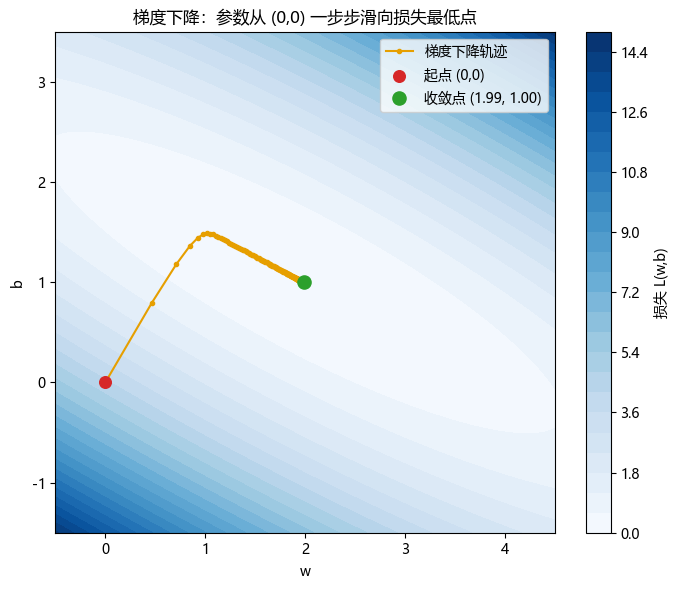

In [5]:
# ---- 梯度下降轨迹：在损失曲面上看参数怎么"滑"到最低点 ----
# 把 1.4 记录下来的轨迹画到损失曲面上，直观看到"一步步逼近最低点"的过程。
轨迹arr = np.array([(w, b) for w, b, _ in 轨迹])   # 复用 1.4 记录的轨迹

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(W, B, Z, levels=25, cmap='Blues')   # 复用 1.5 画的损失曲面 W,B,Z
fig.colorbar(c, label='损失 L(w,b)')
ax.plot(轨迹arr[:, 0], 轨迹arr[:, 1], 'o-', color=橙, lw=1.5, ms=3, label='梯度下降轨迹')
ax.scatter(*轨迹arr[0], color=红, s=70, zorder=5, label='起点 (0,0)')
ax.scatter(*轨迹arr[-1], color=绿, s=90, zorder=5, label=f'收敛点 ({w:.2f}, {b:.2f})')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('梯度下降：参数从 (0,0) 一步步滑向损失最低点')
ax.legend()
plt.tight_layout()
plt.show()

# 注意上面轨迹的特点：越靠近最低点，步子越小（因为坡度越缓、梯度越小），
# 所以点在前半段稀疏、后半段密集——这正是"梯度越小走越慢"的直观体现。


## 1.7 学习率 Learning Rate：步长是门学问

学习率 $\eta$ 决定**每一步走多大**，它是训练中最常调、也最容易调错的超参数。为什么难调？因为同一张损失曲面上，不同学习率的表现天差地别：

| 学习率 | 现象 | 类比 |
| --- | --- | --- |
| **太小** | 每步走一点点，收敛极慢，训半天到不了谷底 | 蚂蚁爬 |
| **合适** | 平稳、快速地收敛 | 正常人下山 |
| **太大** | 每步迈太大，在谷底附近来回震荡，甚至**发散**（损失越训越大，直接飞出谷底） | 青蛙乱跳 |

**为什么会「太大就发散」？** 想想下山的盲人：如果他一步迈得太大，会直接从山谷的这一侧「冲」到另一侧的山坡上，下一步又冲回来，在谷底两侧来回震荡；如果步子再大一点，甚至可能越冲越远，损失不降反升，这就是「发散」。

**那怎么选学习率？** 没有放之四海而皆准的答案，通常靠实验：从 $0.1$、$0.01$、$0.001$ 这类数量级开始试，观察损失曲线是否平稳下降。更省心的做法是用**自适应学习率**的优化器（AdaGrad、RMSProp、Adam），让每个参数自动拥有合适的学习率——这是第六章「Batch 与优化器」的重点。

> 📌 **出处**：学习率、BGD/SGD/MBGD、特征缩放、Momentum 的完整讲解在**第五章「梯度下降」**，自适应学习率在**第六章「Batch 与优化器」**。


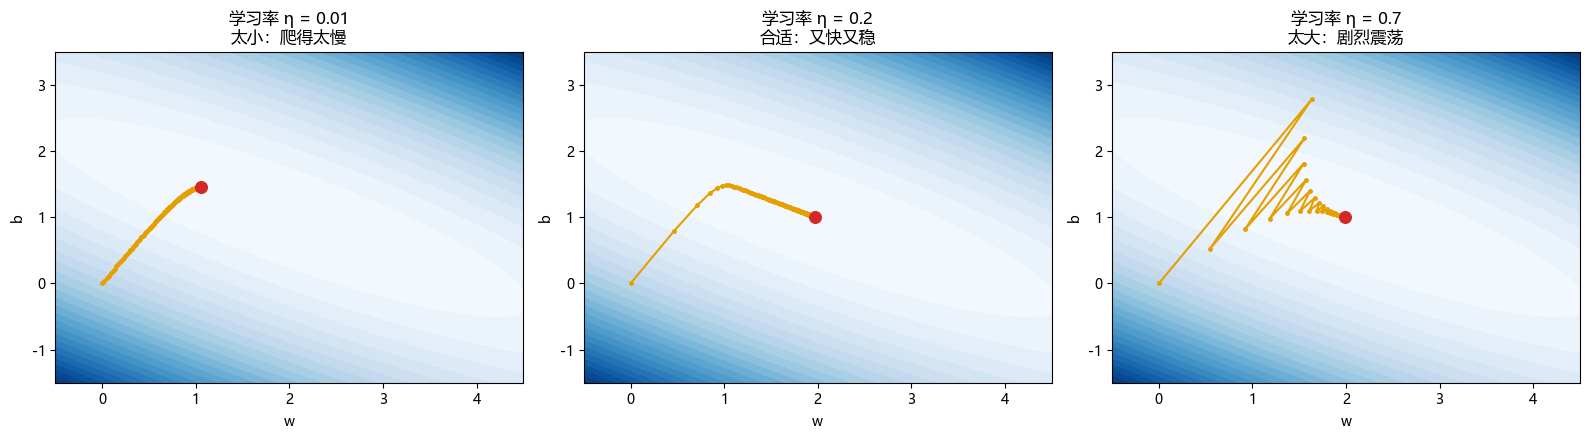

In [6]:
# ---- 不同学习率对梯度下降的影响 ----
# 用同一张损失曲面，跑三个不同学习率，直观对比"太小/合适/太大"。
def 梯度下降(学习率, 初始=(0.0, 0.0), 步数=150):
    """从 初始 点出发，用给定学习率跑 步数 次梯度下降，返回轨迹。"""
    w, b = 初始
    轨 = [(w, b)]
    for _ in range(步数):
        y_pred = 模型(X, w, b)
        dw = np.mean(2 * (y_pred - y) * X)      # ∂L/∂w
        db = np.mean(2 * (y_pred - y))          # ∂L/∂b
        w -= 学习率 * dw
        b -= 学习率 * db
        轨.append((w, b))
    return np.array(轨)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, lr, t in zip(axes, [0.01, 0.2, 0.7], ['太小：爬得太慢', '合适：又快又稳', '太大：剧烈震荡']):
    轨 = 梯度下降(lr)
    ax.contourf(W, B, Z, levels=25, cmap='Blues')   # 复用损失曲面
    ax.plot(轨[:, 0], 轨[:, 1], 'o-', color=橙, lw=1.5, ms=2.5)
    ax.scatter(*轨[-1], color=红, s=70, zorder=5)
    ax.set_title(f'学习率 η = {lr}\n{t}')
    ax.set_xlabel('w'); ax.set_ylabel('b')
plt.tight_layout()
plt.show()

# 看最右那张图（η=0.7）：轨迹在谷底附近大幅来回震荡、迟迟不收敛。
# 如果 η 再大一点，轨迹会直接飞出图外，损失发散——这就是"学习率太大"的后果。


## 1.8 过拟合与正则化：模型别「死记硬背」

这一节建立两个极其重要的概念——**过拟合**和**正则化**，它们在后面会反复出现（第三章、第八章会系统展开）。

### 欠拟合 vs 过拟合

- **欠拟合（underfitting）**：模型**太简单**，连训练数据本身都拟合不好。比如用一条直线去拟合一个明显是曲线（比如正弦波）的数据，无论怎么调，直线都不可能贴住那些弯弯曲曲的点。这时模型「没学够」，训练误差本身就很大。
- **过拟合（overfitting）**：模型**太复杂**，把训练数据的**噪声**都「背」下来了。模型在训练数据上表现近乎完美，但换一批新数据就崩。就像学生只会死记硬背题目，遇到没见过的题就不会做——它「记住了」而不是「学会了规律」。

**为什么会过拟合？** 训练数据里除了真实的规律，还混着**噪声**（测量误差、偶然波动）。一个太复杂的模型，有能力把每个数据点（包括噪声）都精确穿过。它把噪声当成了规律的一部分一起记下来，于是训练误差极小，但真正反映规律的泛化能力反而变差。

### 正则化：给损失函数加「惩罚」，抑制过拟合

**正则化（regularization）** 是抑制过拟合的一大类方法，核心思想是：**在损失函数后面加一个「惩罚项」，限制参数不要太大**。

$$L_{\text{新}} = L_{\text{原}} + \lambda \sum w^2$$

直觉是：**参数 $w$ 越小，函数越「平滑」，越不容易过拟合**。为什么？因为 $w$ 很大的话，输入 $x$ 的微小变化就会被放大成输出的剧烈波动——这样的函数非常「敏感」，容易把噪声也放大了。而 $w$ 小的函数比较「温和」，更可能捕捉到数据里平滑的真实规律。

常见的两种正则化（第八章详细推导）：

- **L2 正则化（岭回归 Ridge）**：加 $\lambda\sum w^2$，让参数整体变小但不会变 0；
- **L1 正则化（套索 Lasso）**：加 $\lambda\sum |w|$，能让部分参数直接变成 0（得到「稀疏」解，顺便做了特征选择）。

> 📌 **出处**：过拟合/欠拟合的**系统诊断**（偏差-方差分解、交叉验证）见**第三章「机器学习任务攻略」**；L1/L2/Lasso/Ridge/ElasticNet 的完整推导与实战见**第八章「过拟合与正则化」**。这里先建立直觉。


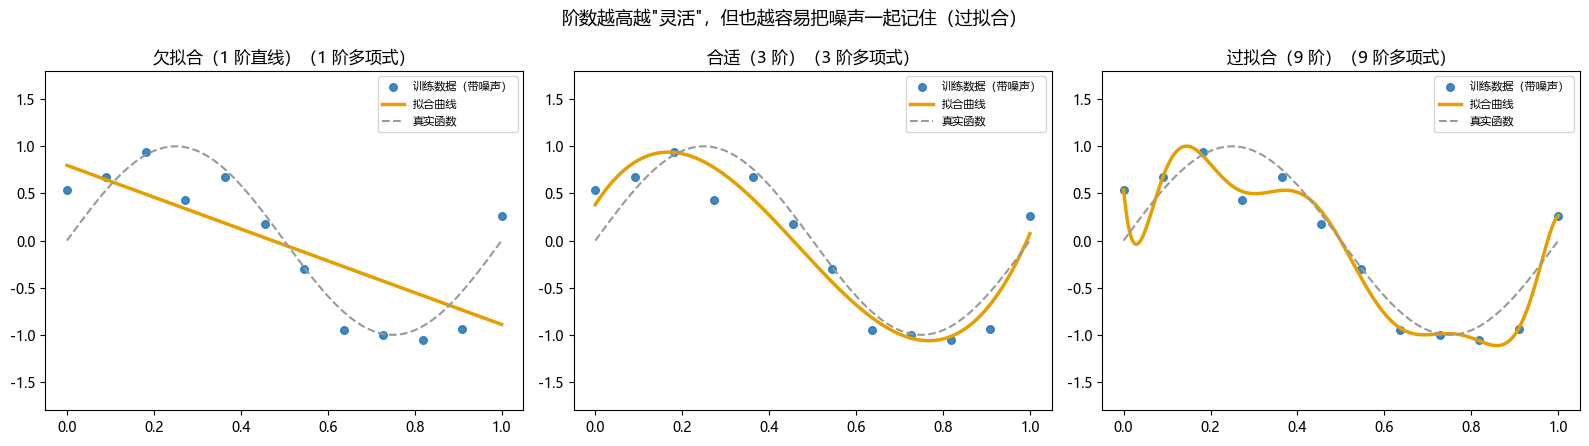

In [7]:
# ---- 欠拟合 / 合适 / 过拟合：多项式阶数对比 ----
# 用 1 阶、3 阶、9 阶多项式去拟合同一批带噪声的正弦波数据，直观看到三种情况。
np.random.seed(3)
x = np.linspace(0, 1, 12)
y真实 = np.sin(2 * np.pi * x)      # 真实关系是一个正弦波
y = y真实 + np.random.randn(12) * 0.3   # 加噪声（模拟真实世界的数据）

xs = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, 阶数, t in zip(axes, [1, 3, 9], ['欠拟合（1 阶直线）', '合适（3 阶）', '过拟合（9 阶）']):
    系数 = np.polyfit(x, y, 阶数)              # 用最小二乘法拟合多项式
    ax.scatter(x, y, color=蓝, s=30, alpha=0.9, label='训练数据（带噪声）')
    ax.plot(xs, np.polyval(系数, xs), color=橙, lw=2.5, label='拟合曲线')
    ax.plot(xs, np.sin(2 * np.pi * xs), color=灰, lw=1.5, ls='--', label='真实函数')
    ax.set_title(f'{t}（{阶数} 阶多项式）')
    ax.set_ylim(-1.8, 1.8)
    ax.legend(fontsize=8)

plt.suptitle('阶数越高越"灵活"，但也越容易把噪声一起记住（过拟合）', fontsize=13)
plt.tight_layout()
plt.show()

# 看三张图：
#   左（1阶）：一条直线，怎么都贴不住波浪 → 欠拟合；
#   中（3阶）：大致描出正弦的轮廓，忽略掉噪声 → 合适；
#   右（9阶）：强行穿过每一个点（包括噪声），剧烈抖动 → 过拟合。


## 1.9 本章小结

这一章建立了机器学习的**全局地图**，后面所有内容都是这张地图的展开。回顾一下关键脉络：

1. **机器学习 = 让机器从数据里自动找一个函数** $f$（输入 → 输出）；
2. 按输出类型分**回归 / 分类 / 结构化学习**，按有没有答案分**监督 / 无监督 / 强化学习**；
3. 训练任何一个模型，都走**三步曲**：① 定义模型（带未知参数的函数）→ ② 定义损失（给参数打分）→ ③ 优化（找让损失最小的参数）；
4. **损失函数**是打分标准（回归常用 MSE/MAE，分类用交叉熵）；
5. **梯度下降**是找最低点的算法：每次朝负梯度方向走一小步，步长由**学习率**控制；
6. 模型太简单会**欠拟合**，太复杂会**过拟合**，用**正则化**（给损失加惩罚项）抑制过拟合。

🔑 **需要背下来的核心公式**：

$$\text{模型：}\ y = wx + b \qquad \text{损失：}\ L = \frac{1}{n}\sum_i(\hat y_i - y_i)^2 \qquad \text{更新：}\ \theta \leftarrow \theta - \eta \nabla L(\theta)$$


# 第二章 深度学习基本概念

> 📌 **出处**：李宏毅 2026《机器学习》**第 2 讲「深度学习基本概念简介」**（B 站 BV1RnikBvE8m）
> ⭐ **40 天重点**：对应计划 Day15/Day17 的能力要求——*了解 MLP（多层感知机）基本原理、激活函数*。这一章告诉你「深度学习」这词听起来吓人，本质是什么。

---

## 2.1 神经网络：一大堆「神经元」搭起来的函数

第一章说过：**机器学习就是找一个函数**。问题是，如果我们要找的函数非常复杂（比如「图片 → 猫还是狗」这种函数，你根本没法用一个简单的式子写出来），怎么办？

答案是：**用神经网络（Neural Network）去逼近这个复杂函数**。神经网络本质上是一种**特别能拟合复杂函数的模型**——它由许多个**神经元（neuron）**按层连接而成。

那什么是「神经元」？其实它做的事非常简单，两步而已（下一节展开）：

1. 把输入各自乘上一个**权重 $w$**，加起来再加一个**偏置 $b$**（这一步叫**加权求和**）；
2. 把结果送进一个**非线性函数**（这一步叫**激活**）。

单个神经元做的事情 ≈ 逻辑回归（第九章会看到）。但**把很多很多个神经元一层层叠起来**，这个整体就有了拟合「任意复杂函数」的能力——这就是「神经网络」。所谓「深度」，就是「层数多」。

> 💡 关键认知：**神经网络不是什么神秘的黑箱，它就是一个「由简单零件（神经元）拼成的复杂函数」**。每个零件很简单，拼在一起就很强大。就像乐高：单块积木很简单，拼起来能搭出任何东西。


## 2.2 单个神经元：加权求和 + 激活函数

先彻底看清一个神经元到底在算什么。一个神经元接收 $n$ 个输入 $x_1, x_2, \dots, x_n$，输出一个值 $a$，中间就两步：

$$a = \sigma\Big(\underbrace{w_1x_1 + w_2x_2 + \cdots + w_nx_n + b}_{\text{加权求和，记作 } z}\Big)$$

### 第一步：加权求和（weighted sum）

把每个输入 $x_i$ 乘上一个对应的**权重 $w_i$**，全部加起来，再加上一个**偏置 $b$**，得到一个数 $z$：

$$z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b = \mathbf{w}^\top \mathbf{x} + b$$

这一步的几何意义：它就是一个**线性变换**。权重 $w_i$ 决定了「第 $i$ 个输入对这个神经元的输出贡献多大」——权重越大，这个输入越重要；偏置 $b$ 则是「基础偏移量」，让神经元在输入全为 0 时也能输出一个非零值。

### 第二步：激活函数（activation function）

把 $z$ 送进一个非线性函数 $\sigma(\cdot)$，得到最终输出 $a = \sigma(z)$。

**为什么一定要这个非线性函数？** 这是最关键的一点：如果去掉激活函数（即 $a = z$），那神经元就只是一个线性变换。而**一堆线性变换叠在一起，结果还是线性变换**——也就是说，无论你把多少层神经元叠起来，整体仍然等价于「一条直线 / 一个超平面」，能力没有任何提升。

激活函数给神经元注入了**非线性**，才让「多层的神经网络」拥有了「单层线性模型」永远达不到的表达能力。这也是「深度」为什么有效的根本原因之一。


In [8]:
# ---- 单个神经元的计算：加权求和 → 激活函数 ----
# 手写一个神经元，看清楚"两步"是怎么算的。

def 神经元(x, w, b, 激活=np.tanh):
    """一个神经元：先加权求和 z = w·x + b，再过激活函数 a = 激活(z)。
    返回 (z, a) 两个值，方便观察激活前后的变化。"""
    z = np.dot(w, x) + b      # 第一步：加权求和（向量点积 + 偏置）
    return z, 激活(z)          # 第二步：激活

# 一个具体的例子：3 个输入，同时算 3 个神经元（每行权重对应一个神经元）
x = np.array([0.5, -0.3, 0.8])           # 输入：3 个特征
W = np.array([[0.2, -0.5, 0.4],          # 3 个神经元各自的权重（3 行 = 3 个神经元）
              [0.8, 0.1, -0.7],
              [-0.3, 0.6, 0.5]])
b = np.array([0.1, -0.2, 0.0])           # 3 个神经元的偏置

z, a = 神经元(x, W, b)                    # 一次算出 3 个神经元的输出
print("加权求和 z =", np.round(z, 3))
print("激活输出 a =", np.round(a, 3))
print()
print("→ 观察：原始线性加权 z 经过激活函数后，变成非线性的输出 a。")
print("→ 这正是神经网络的'非线性'来源：没有激活函数，无论多少层都等价于一条直线。")


加权求和 z = [ 0.67 -0.39  0.07]
激活输出 a = [ 0.585 -0.371  0.07 ]

→ 观察：原始线性加权 z 经过激活函数后，变成非线性的输出 a。
→ 这正是神经网络的'非线性'来源：没有激活函数，无论多少层都等价于一条直线。


## 2.3 激活函数：给网络注入「非线性」的几种选择

上一节讲了激活函数的重要性。那么常用的激活函数有哪些？它们的区别是什么？这一节逐个看。

| 激活函数 | 公式 | 输出范围 | 特点 |
| --- | --- | --- | --- |
| **Sigmoid** | $\sigma(z)=\dfrac{1}{1+e^{-z}}$ | $(0, 1)$ | 早期常用，输出像概率；但两端梯度趋近 0，深层网络里容易「梯度消失」 |
| **tanh** | $\tanh(z)=\dfrac{e^z-e^{-z}}{e^z+e^{-z}}$ | $(-1, 1)$ | 是 Sigmoid 的「中心化」版本（输出以 0 为中心），比 Sigmoid 稍好 |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | 计算极快、缓解梯度消失，**现代网络隐藏层最常用** |

### 为什么现代网络几乎都用 ReLU？

- **计算快**：ReLU 就是「负数取 0，正数原样输出」，一个 `max` 就搞定，而 Sigmoid 要算指数函数，慢得多。
- **缓解梯度消失**：Sigmoid 在 $z$ 很大或很小时，曲线变得非常平（梯度 ≈ 0），反向传播时梯度一路相乘会迅速消失，深层网络学不动；而 ReLU 在正半轴梯度恒为 1，不会消失。

> 💡 使用上的约定（记住即可）：
> - **隐藏层**默认用 **ReLU**（或它的变体，如 LeakyReLU、GeLU）；
> - **输出层**根据任务选：回归 → 线性（不用激活）；二分类 → Sigmoid；多分类 → Softmax（第九章讲）。


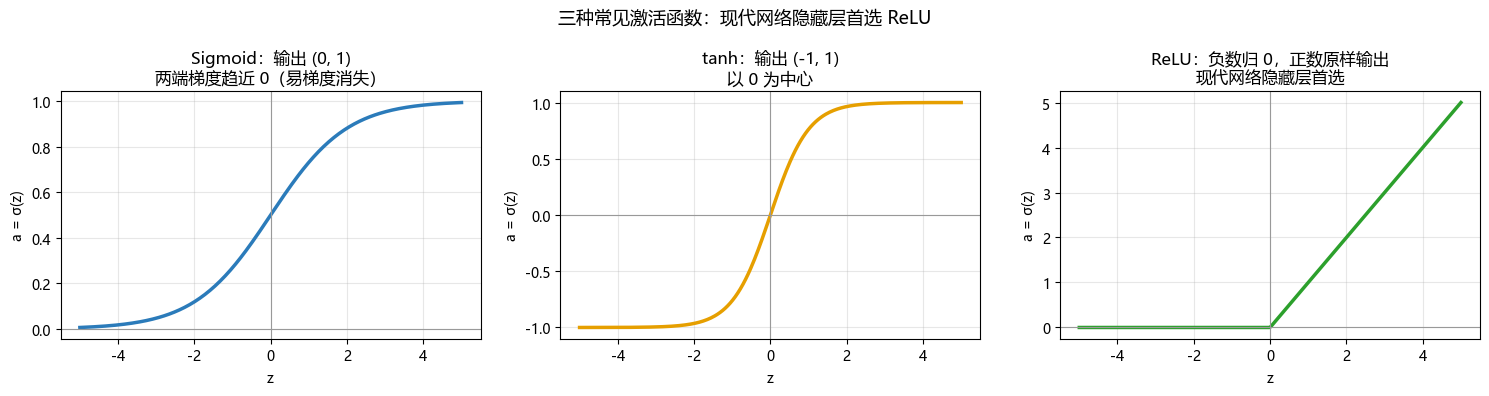

In [9]:
# ---- 三种常用激活函数可视化 ----
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z, sigmoid(z), color=蓝, lw=2.5)
axes[0].set_title('Sigmoid：输出 (0, 1)\n两端梯度趋近 0（易梯度消失）')
axes[1].plot(z, np.tanh(z), color=橙, lw=2.5)
axes[1].set_title('tanh：输出 (-1, 1)\n以 0 为中心')
axes[2].plot(z, np.maximum(0, z), color=绿, lw=2.5)
axes[2].set_title('ReLU：负数归 0，正数原样输出\n现代网络隐藏层首选')

for ax in axes:
    ax.axhline(0, color=灰, lw=0.8); ax.axvline(0, color=灰, lw=0.8)
    ax.set_xlabel('z'); ax.set_ylabel('a = σ(z)')
    ax.grid(alpha=0.3)

plt.suptitle('三种常见激活函数：现代网络隐藏层首选 ReLU', fontsize=13)
plt.tight_layout()
plt.show()

# 重点看 ReLU（右图）：z<0 时输出恒 0（"关掉"这个神经元），z>0 时是斜率为 1 的直线。
# 这种"一半关掉一半原样"的简单形状，反而在深层网络里表现最好。


## 2.4 层、深度：把神经元叠起来

单个神经元能力有限，但把神经元**按层（layer）组织**起来，就形成了神经网络：

- **输入层（input layer）**：最左边的原始特征，它本身不参与计算，只是「入口」；
- **隐藏层（hidden layer）**：中间那些层，负责层层提取特征。它们的输入输出我们都看不到（所以叫「隐藏」）；
- **输出层（output layer）**：最后一层，给出最终结果（数值 / 类别 / 概率）。

**「深度」 = 隐藏层的层数**。层数多 → 就叫**深度学习（Deep Learning）**。所以：

> 💡 **深度学习 = 有很多隐藏层的神经网络**。名字很玄，本质就是「又深又宽的神经网络」。

### 为什么「深」有效？——层层抽象

直觉上，网络是一层层递进的：

- **底层**学到**简单特征**：边缘、颜色、简单的纹理（比如图像里的横线竖线）；
- **中层**把简单特征组合成**较复杂特征**：轮廓、局部形状（比如眼睛、轮子）；
- **高层**组合成**语义特征**：整个人脸、整个物体、整句话的含义。

一层层抽象下去，就能表达越来越复杂、越来越「抽象」的函数。这也是为什么深度神经网络能处理图像、语音、语言这些复杂任务——它自动学会了「从低层细节到高层语义」的分层表达。


最终损失(MSE) = 0.0002

异或真值表（训练后）：
  (np.int64(0), np.int64(0)) -> 真实 0，预测 0 ✓
  (np.int64(0), np.int64(1)) -> 真实 1，预测 1 ✓
  (np.int64(1), np.int64(0)) -> 真实 1，预测 1 ✓
  (np.int64(1), np.int64(1)) -> 真实 0，预测 0 ✓


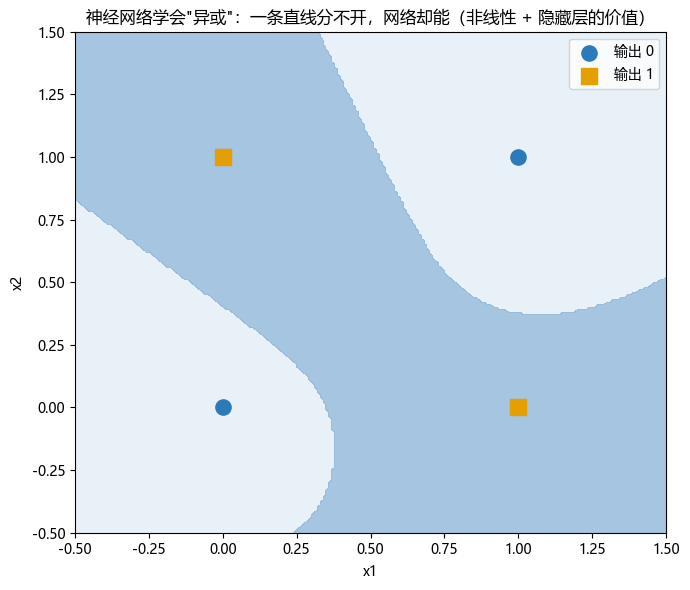

In [10]:
# ---- 从零实现一个两层神经网络，学习"异或 XOR" ----
# XOR 是经典的"一条直线分不开"的问题：
#   (0,0)->0, (1,1)->0, 但 (0,1)->1, (1,0)->1
# 用一条直线（线性模型）无论如何分不开这四类点，但加了隐藏层的神经网络可以。
# 这个例子直观展示了"非线性 + 隐藏层"带来的能力跃升。

np.random.seed(0)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])          # 输入 (4, 2)：4 个样本，2 个特征
y = np.array([[0], [1], [1], [0]])                       # 目标 (4, 1)：异或真值

输入维度, 隐藏维度, 输出维度 = 2, 4, 1
W1 = np.random.randn(输入维度, 隐藏维度) * 0.5            # 第一层权重 (2, 4)：2 个输入 -> 4 个隐藏神经元
b1 = np.zeros(隐藏维度)
W2 = np.random.randn(隐藏维度, 输出维度) * 0.5            # 第二层权重 (4, 1)：4 个隐藏 -> 1 个输出
b2 = np.zeros(输出维度)

def 前向(x):
    """前向传播：输入 x -> 隐藏层(tanh) -> 输出层(sigmoid)。返回 (隐藏激活, 输出)。"""
    z1 = x @ W1 + b1          # 隐藏层加权求和
    a1 = np.tanh(z1)          # 隐藏层激活：tanh（非线性！）
    z2 = a1 @ W2 + b2         # 输出层加权求和
    a2 = 1 / (1 + np.exp(-z2))  # 输出层激活：sigmoid（输出概率 0~1）
    return a1, a2

学习率 = 0.5
for epoch in range(3000):
    a1, a2 = 前向(X)
    # ---- 反向传播：用链式法则求每一层参数的梯度（第十一章会完整推导）----
    dz2 = (a2 - y) * a2 * (1 - a2)          # 输出层误差（MSE + sigmoid 导数的组合）
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0)
    dz1 = (dz2 @ W2.T) * (1 - a1**2)        # 隐藏层误差（tanh 的导数 = 1 - tanh²）
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    # ---- 梯度下降更新 ----
    W1 -= 学习率 * dW1; b1 -= 学习率 * db1
    W2 -= 学习率 * dW2; b2 -= 学习率 * db2

_, a2 = 前向(X)
print(f"最终损失(MSE) = {np.mean((a2 - y) ** 2):.4f}")
print("\n异或真值表（训练后）：")
for 输入, 目标 in zip(X, y):
    _, a2i = 前向(输入.reshape(1, -1))
    预测 = 1 if a2i[0, 0] > 0.5 else 0
    print(f"  {tuple(输入)} -> 真实 {目标[0]}，预测 {预测} {'✓' if 预测 == 目标[0] else '✗'}")

# ---- 决策边界可视化：单条直线分不开 XOR，但网络能画出弯曲的边界 ----
xx = np.linspace(-0.5, 1.5, 200)
XX, YY = np.meshgrid(xx, xx)
_, a2grid = 前向(np.c_[XX.ravel(), YY.ravel()])
Zgrid = (a2grid.reshape(XX.shape) > 0.5).astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(XX, YY, Zgrid, alpha=0.4, cmap='Blues', levels=[-0.5, 0.5, 1.5])
ax.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], s=120, color=蓝, label='输出 0')
ax.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], s=120, color=橙, marker='s', label='输出 1')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('神经网络学会"异或"：一条直线分不开，网络却能（非线性 + 隐藏层的价值）')
ax.legend()
plt.tight_layout()
plt.show()

# 看决策边界：蓝色背景是判 0 的区域，白色是判 1 的区域。
# 边界是弯曲的（不是一条直线），所以能把对角线上同为 0 或同为 1 的点分开。


## 2.5 训练神经网络，还是那「三步曲」

别被「深度学习」这个词吓到——训练一个神经网络，本质上还是第一章那**三步曲**，一点没变：

1. **模型**：把网络结构（几层、每层几个神经元、用什么激活函数）定下来，这个「网络」就是一个「带未知参数（权重 $w$、偏置 $b$）的函数」；
2. **损失**：用一个损失函数（回归用 MSE、分类用交叉熵）衡量网络输出和真实答案的差距；
3. **优化**：用**梯度下降 + 反向传播（Backpropagation）**，自动算出每一层每个参数的梯度，迭代更新。

### 反向传播是什么？

梯度下降需要「每个参数对损失的梯度」。对神经网络，参数成千上万，手推每个梯度不可能。**反向传播（Backpropagation）** 就是自动、高效地算出所有梯度的算法——它本质只是**链式法则**（微积分里求复合函数导数的法则）在神经网络上的应用：从输出层开始，把误差一层层「传」回前面，逐层算出梯度。

> 📌 **出处**：反向传播的完整推导在**第十一章「神经网络与反向传播」**。这里只需要记住：**反向传播 = 链式法则，目的只是自动求梯度**，没有超出三步曲的框架。


## 2.6 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| **神经元** | 加权求和 + 激活函数，是网络的基本单元 |
| **加权求和** | $z = \mathbf{w}^\top\mathbf{x} + b$，线性变换 |
| **激活函数** | 注入非线性（Sigmoid / tanh / ReLU，现代首选 ReLU） |
| **层 / 深度** | 输入层、隐藏层、输出层；「深度」= 隐藏层层数 |
| **深度学习** | 有很多隐藏层的神经网络，层层提取更抽象的特征 |
| **训练** | 还是三步曲，只是用反向传播自动求梯度 |

🔑 **需要背下来的**：

- 神经元：$a = \sigma(\mathbf{w}^\top\mathbf{x} + b)$；
- **没有激活函数，多层神经网络就退化成线性模型**（这是激活函数存在的根本原因）；
- 隐藏层用 ReLU，输出层按任务选（回归线性 / 二分类 Sigmoid / 多分类 Softmax）。


# 第三章 机器学习任务攻略：偏差、方差与交叉验证

> 📌 **出处**：李宏毅 2026《机器学习》**第 3 讲「机器学习任务攻略」**（B 站 BV1RnikBvE8m）
> ⭐ **40 天重点**：对应计划 Day15「机器学习概览」——*训练/验证/测试集划分、偏差-方差权衡、过拟合与欠拟合诊断*。这一章解决一个最实际的问题：**模型训练效果不好时，到底该怎么办**。

---

## 3.1 从实际问题出发：模型效果不好，怎么办？

先设想一个真实场景：你花了一天训练好一个模型，满怀期待地放到测试集上一看——准确率很差。这时候你该怎么办？

很多人的第一反应是「换个更复杂的模型」或「再多训练一会儿」，但这些都是**瞎撞**。真正高效的做法是：**先诊断问题出在哪，再对症下药**。李宏毅老师在这一讲给了一张「攻略地图」，核心就一句话：

> **分别看训练集误差和验证集误差，判断模型是「没学够」还是「学过头了」。**

这两个数就像医生的两个化验指标，能告诉你病根是「偏差大（欠拟合）」还是「方差大（过拟合）」，然后才能开对药。本章就系统讲清这套诊断方法。

---

## 3.2 为什么要把数据分成三份：训练 / 验证 / 测试

### 为什么不能只看训练集？

第一章讲过「过拟合」：模型可能把训练数据的噪声都背下来，在训练集上表现近乎完美，但换一批新数据就崩。**所以「训练集上的误差」不能代表模型真实的好坏**——它可能是「背题背出来的高分」。

### 三个集合的分工

为了既训练模型、又客观评价模型，标准做法是把数据切成三份：

| 集合 | 作用 | 类比 |
| --- | --- | --- |
| **训练集 train** | 用来**训练**模型（更新参数） | 平时做作业 |
| **验证集 validation** | 用来**调超参数、选模型**（比如挑学习率、挑模型复杂度），**不参与训练** | 模拟考试 |
| **测试集 test** | **只在最后**评估一次模型的最终泛化能力 | 高考 |

> 🔑 **记忆**：三个集合的分工是「训练集出参数，验证集出选择，测试集出成绩」。**测试集从头到尾只能碰一次**，绝对不能拿它反复调模型，否则测试集就变成了「另一个验证集」，评估结果会虚高。

### 为什么需要单独的验证集？

因为「调超参数」本身也是一种「拟合」：你反复在验证集上挑最好的模型/参数，其实是在「拟合验证集」。如果验证集和测试集是同一份，那你等于在测试集上调参，最终成绩必然虚高。所以需要**把验证集和测试集分开**，保证测试集是「从没被模型/你见过」的干净数据。


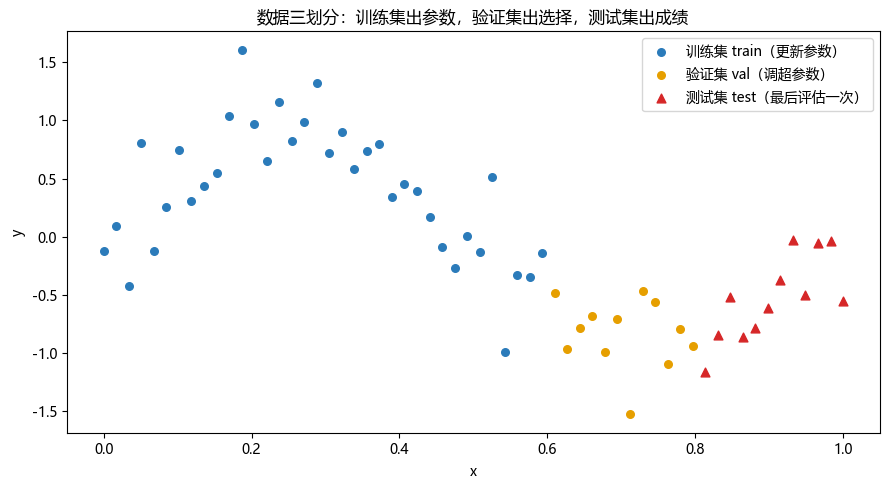

In [11]:
# ---- 数据划分可视化：训练 / 验证 / 测试 三份的分工 ----
# 用颜色把同一批数据标成三段，直观理解"谁用来训练、谁用来调参、谁用来考试"。
np.random.seed(2)
n = 60
X3 = np.linspace(0, 1, n)
y3 = np.sin(2 * np.pi * X3) + np.random.randn(n) * 0.3

# 按 60% / 20% / 20% 划分（这里只做示意，实际用 sklearn 的 train_test_split 更规范）
train_end, val_end = int(n * 0.6), int(n * 0.8)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X3[:train_end], y3[:train_end], color=蓝, s=30, label='训练集 train（更新参数）')
ax.scatter(X3[train_end:val_end], y3[train_end:val_end], color=橙, s=30, label='验证集 val（调超参数）')
ax.scatter(X3[val_end:], y3[val_end:], color=红, s=40, marker='^', label='测试集 test（最后评估一次）')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('数据三划分：训练集出参数，验证集出选择，测试集出成绩')
ax.legend()
plt.tight_layout()
plt.show()


## 3.3 诊断第一步：对比「训练误差」和「验证误差」

拿到一个效果不好的模型，先算两个数：

- **训练误差（training error）**：模型在**训练集**上的误差；
- **验证误差（validation error）**：模型在**验证集**（训练时没见过的数据）上的误差。

这两个数的大小关系，直接暴露问题所在：

| 现象 | 诊断 | 通俗说法 |
| --- | --- | --- |
| 训练误差**大**，验证误差也大 | **偏差大** → 欠拟合 | 模型太简单，连训练数据都没学好 |
| 训练误差**小**，但验证误差**大** | **方差大** → 过拟合 | 模型太复杂，只会背题不会举一反三 |
| 训练误差小，验证误差也小 | 刚刚好 | 理想状态 |

> 💡 一句话：**训练误差大 = 没学够（欠拟合）；训练误差小但验证误差大 = 学过头（过拟合）。** 诊断出是哪一种，下一节的对策才有方向。


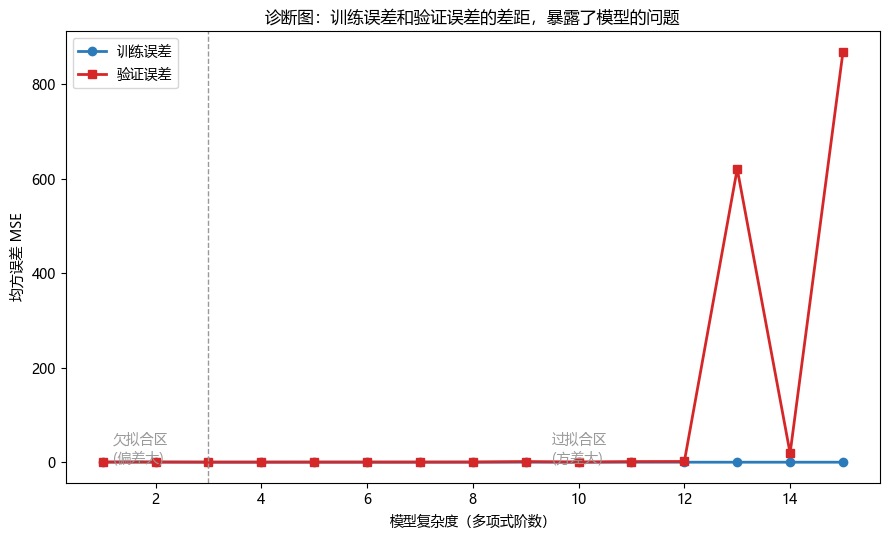

In [12]:
# ---- 模型复杂度 vs 训练/验证误差：诊断 U 型曲线 ----
# 用不同阶数的多项式拟合同一份数据，分别算训练误差和验证误差，
# 画出"模型复杂度 → 误差"的曲线，这是诊断欠拟合/过拟合的核心图。
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(5)
X4 = np.linspace(0, 1, 30)
y4 = np.sin(2 * np.pi * X4) + np.random.randn(30) * 0.4
X_tr, X_va, y_tr, y_va = train_test_split(X4, y4, test_size=0.4, random_state=0)

复杂度 = list(range(1, 16))          # 多项式阶数 1~15
训练误差, 验证误差 = [], []
for d in 复杂度:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_tr.reshape(-1, 1), y_tr)
    训练误差.append(mean_squared_error(y_tr, model.predict(X_tr.reshape(-1, 1))))
    验证误差.append(mean_squared_error(y_va, model.predict(X_va.reshape(-1, 1))))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(复杂度, 训练误差, 'o-', color=蓝, lw=2, label='训练误差')
ax.plot(复杂度, 验证误差, 's-', color=红, lw=2, label='验证误差')
ax.axvline(3, color=灰, ls='--', lw=1)
ax.text(1.2, 0.35, '欠拟合区\n(偏差大)', fontsize=10, color=灰)
ax.text(9.5, 0.35, '过拟合区\n(方差大)', fontsize=10, color=灰)
ax.set_xlabel('模型复杂度（多项式阶数）'); ax.set_ylabel('均方误差 MSE')
ax.set_title('诊断图：训练误差和验证误差的差距，暴露了模型的问题')
ax.legend()
plt.tight_layout()
plt.show()

# 看图：
#   左端（1~2 阶）：训练误差、验证误差都大 → 欠拟合（偏差大）；
#   右端（8 阶以上）：训练误差越来越小，验证误差反而变大 → 过拟合（方差大）；
#   中间（3~5 阶）：验证误差最低，是最合适的复杂度。


## 3.4 偏差（Bias）与方差（Variance）：两个误差的深层含义

「欠拟合」和「过拟合」背后，是统计学习里两个根本概念：**偏差**和**方差**。

### 偏差 Bias：模型「平均而言」离真相有多远

想象我们反复做实验：每次抽一批不同的训练数据，训练一个模型。**偏差**衡量的是「所有这些模型预测的**平均值**」和「真实值」之间的差距。

- 如果模型**太简单**（比如用直线去拟合正弦波），不管换多少批数据，它预测的平均值都系统性地偏离真相——**偏差就大**。这对应**欠拟合**。

### 方差 Variance：模型对「训练数据的波动」有多敏感

**方差**衡量的是「换一批训练数据，模型的预测会变化多大」。

- 如果模型**太复杂**（比如 15 阶多项式），它会把每一批数据里的噪声都死死记住，于是换一批数据，模型就变成完全不同的形状——预测结果波动巨大，**方差就大**。这对应**过拟合**。

### 误差的分解：误差 = 偏差² + 方差 + 噪声

统计上可以证明（不要求推导，但要记住结论），模型的期望误差可以分解成三项：

$$\text{期望误差} = \underbrace{\text{偏差}^2}_{\text{模型太简单导致}} + \underbrace{\text{方差}}_{\text{模型太复杂导致}} + \underbrace{\text{噪声}}_{\text{数据本身固有的，无法消除}}$$

这个公式揭示了一个**权衡（bias-variance tradeoff）**：模型越简单，偏差越大、方差越小；模型越复杂，偏差越小、方差越大。**好的模型要在两者之间取平衡**——既不太简单（偏差别太大），也不太复杂（方差别太大）。这就是「诊断 U 型曲线」里验证误差先降后升的根本原因。


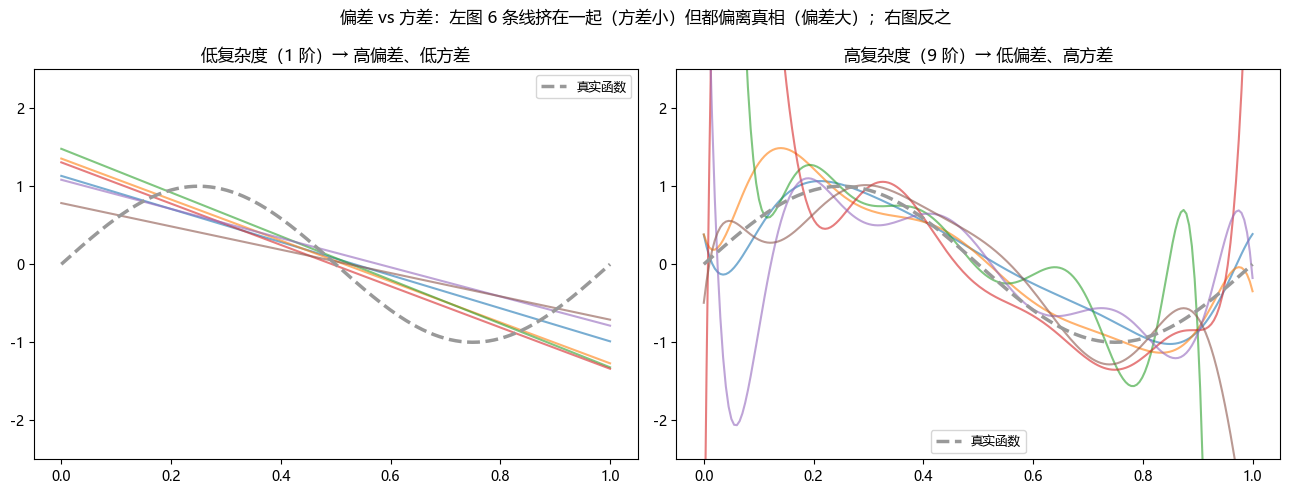

In [13]:
# ---- 偏差 vs 方差：同一复杂度，换多批数据看模型抖不抖 ----
# 固定一个阶数，随机抽多批训练数据各拟合一次，看模型形状的"离散程度"。
def 拟合多项式(X_, y_, d):
    return np.polyfit(X_, y_, d)

xs = np.linspace(0, 1, 200)
真函数 = np.sin(2 * np.pi * xs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, d, t in zip(axes, [1, 9], ['低复杂度（1 阶）→ 高偏差、低方差', '高复杂度（9 阶）→ 低偏差、高方差']):
    for k in range(6):
        np.random.seed(100 + k)
        Xk = np.sort(np.random.rand(20))
        yk = np.sin(2 * np.pi * Xk) + np.random.randn(20) * 0.3
        系数 = 拟合多项式(Xk, yk, d)
        ax.plot(xs, np.polyval(系数, xs), alpha=0.6, lw=1.5)
    ax.plot(xs, 真函数, color=灰, lw=2.5, ls='--', label='真实函数')
    ax.set_title(t)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=9)

plt.suptitle('偏差 vs 方差：左图 6 条线挤在一起（方差小）但都偏离真相（偏差大）；右图反之', fontsize=12)
plt.tight_layout()
plt.show()

# 左边（1 阶）：6 条直线几乎重合（方差小），但它们全是直线、离正弦波很远（偏差大）；
# 右边（9 阶）：6 条曲线各贴各的噪声、彼此差很多（方差大），但平均起来接近真相（偏差小）。


## 3.5 对症下药：欠拟合和过拟合分别怎么解决

诊断出问题之后，对策就很清晰了：

### 如果欠拟合（偏差大，训练误差就大）

核心思路：**让模型更强**。

- **换更复杂的模型**：直线换成高次多项式、浅网络换成深网络；
- **加更多特征**：把更多有用的输入信息喂给模型；
- **减少正则化**：如果正则化太狠把模型「压」得太死，就放松一点。

### 如果过拟合（方差大，训练误差小但验证误差大）

核心思路：**让模型别「死记」，学会「泛化」**。有几类经典手段：

- **收集更多数据**：数据越多，噪声越难被「记住」，模型越容易学到真实规律（最有效的办法，但数据往往不够）；
- **数据增强（data augmentation）**：人为扩充数据，比如把图片旋转、裁剪、变色，相当于「造」更多样本（第十五章会讲）；
- **正则化**：给损失加惩罚项，限制模型复杂度（第八章系统讲 L1/L2/Dropout/早停）；
- **简化模型**：减少参数、减少层数，让模型没能力去背噪声。

> 📌 **出处**：正则化（L1/L2/Lasso/Ridge/Dropout/早停）的完整内容在**第八章**，数据增强在**第十五章**。


## 3.6 交叉验证 Cross-Validation：更可靠的评估方法

前面用「固定的一份验证集」来挑模型。但如果验证集切得不好（比如恰好切到一批噪声特别大的点），评估结果会不稳定。**交叉验证（Cross-Validation）** 是更稳健的做法。

### K 折交叉验证（K-fold Cross-Validation）

做法：把训练数据分成 $K$ 份（fold），然后做 $K$ 轮：

1. 每次拿其中 **1 份当验证集**，剩下 $K-1$ 份当训练集；
2. 训练并记录这次在验证集上的误差；
3. 轮换「哪一份当验证集」，重复 $K$ 次；
4. 最后把 $K$ 次的验证误差**取平均**，作为这个模型/超参数的评估结果。

好处是：**每一份数据都被当过验证集**，评估结果不再依赖某一次「切得巧不巧」，更稳定可靠。

### 什么时候用交叉验证？

- **调超参数、选模型时**用交叉验证，能更可靠地比较不同选择的好坏；
- 交叉验证计算量是原来的 $K$ 倍，所以**数据量大、模型贵时**常用简单的「单次验证集划分」代替；数据量小时交叉验证尤其有价值。


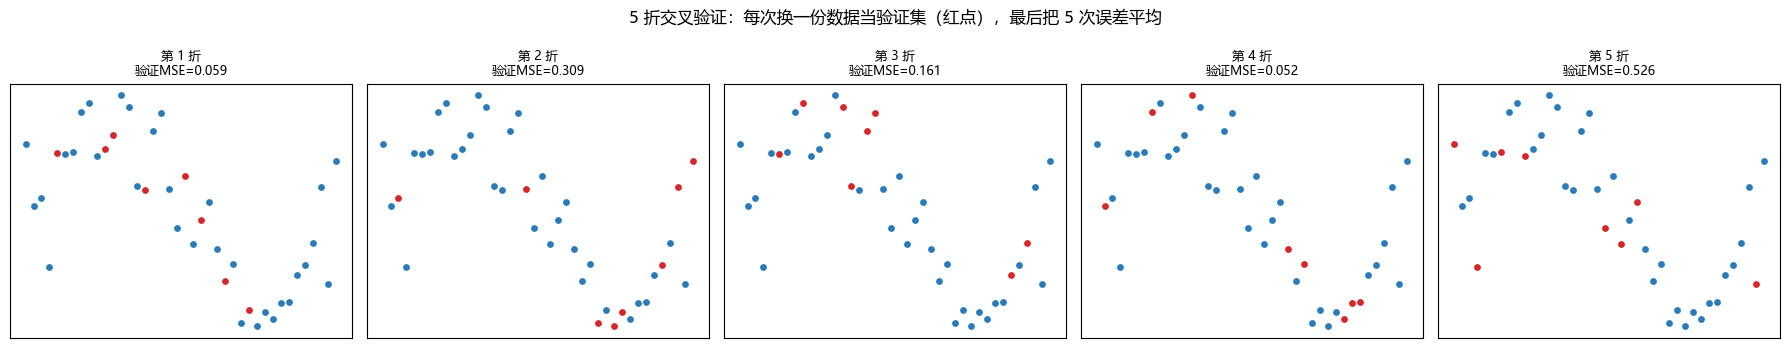

5 折的验证 MSE： [0.059, 0.309, 0.161, 0.052, 0.526]
平均验证 MSE： 0.221 （这就是该模型更可靠的评估结果）


In [14]:
# ---- K 折交叉验证演示 ----
from sklearn.model_selection import KFold

np.random.seed(11)
X5 = np.linspace(0, 1, 40)
y5 = np.sin(2 * np.pi * X5) + np.random.randn(40) * 0.4
X5 = X5.reshape(-1, 1)

kf = KFold(n_splits=5, shuffle=True, random_state=0)
折号 = 1
分数 = []
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for (train_idx, val_idx), ax in zip(kf.split(X5), axes):
    model = make_pipeline(PolynomialFeatures(3), LinearRegression())
    model.fit(X5[train_idx], y5[train_idx])
    sc = mean_squared_error(y5[val_idx], model.predict(X5[val_idx]))
    分数.append(sc)
    # 画出每一折：训练点（蓝）和验证点（红）
    ax.scatter(X5[train_idx], y5[train_idx], color=蓝, s=15)
    ax.scatter(X5[val_idx], y5[val_idx], color=红, s=15)
    ax.set_title(f'第 {折号} 折\n验证MSE={sc:.3f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    折号 += 1

plt.suptitle('5 折交叉验证：每次换一份数据当验证集（红点），最后把 5 次误差平均', fontsize=12)
plt.tight_layout()
plt.show()
print("5 折的验证 MSE：", [round(s, 3) for s in 分数])
print("平均验证 MSE：", round(np.mean(分数), 3), "（这就是该模型更可靠的评估结果）")


## 3.7 【李沐 实用ML】模型验证：训练 / 验证 / 测试 + K 折 + 学习曲线

> 📌 **出处**：李沐《实用机器学习》「模型评估、模型验证、方差与偏差」
> 📎 **完整可运行代码**：`实战代码_李沐/模型评估与验证.ipynb`

3.4~3.6 讲了偏差/方差和交叉验证，这里补上李沐课程里最常用的「三件套划分」：

| 数据集 | 干什么 | 用几次 |
| --- | --- | --- |
| 训练集 | 学模型参数 | 反复用 |
| 验证集 | 调超参、选模型、早停 | 多次 |
| 测试集 | 最终报告泛化能力 | **只用一次** |

核心原则：**测试集必须「出箱封存」**，只在最后评一次。否则你在测试集上反复调参，测试集就「变脏」成了验证集。

- **数据多** → 直接按 6:2:2 或 8:1:1 切三份；
- **数据少** → 用 **K 折交叉验证**（3.6 已讲）：切 K 份轮流当验证取平均，更省数据、更稳；
- **判断好坏** → 看**学习曲线**：训练/验证误差都高 = 欠拟合（加复杂度）；训练低验证高且差距大 = 过拟合（加正则/增数据）。

> 💡 这一节和 3.4~3.6 是「同一件事的两面」：3.4~3.6 讲**偏差/方差是什么**，这里讲**工程上怎么用划分和曲线把它们测出来**。


## 3.8 本章小结


# 第四章 线性回归与正规方程

> 📌 **出处**：李宏毅 2026《机器学习》**第 4~9 讲**（线性回归基本概念 1/2、正规方程介绍、求解多元一次方程、sklearn 运算、带截距运算）
> ⭐ **40 天重点**：对应计划 Day16「逻辑回归 + 第一个模型」的前置内容。线性回归是**最基础、最经典的机器学习模型**，正规方程是「一步解出最优参数」的解析方法。

---

## 4.1 线性回归：最基础的机器学习模型

第一章讲过，**回归（Regression）** 是「输出一个连续数值」的任务。而**线性回归（Linear Regression）** 是最简单的回归模型——它假设输出 $y$ 是输入特征 $x$ 的**线性组合**。

### 一元线性回归（只有一个特征 $x$）

$$y = w \cdot x + b$$

- $w$ 是**权重（weight）**，即这条直线的**斜率**；
- $b$ 是**偏置（bias）**，即这条直线的**截距**（与 y 轴的交点）；
- 我们要做的，就是**从数据里学出最合适的 $w$ 和 $b$**。

### 多元线性回归（多个特征 $x_1, x_2, \dots, x_n$）

$$y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

写成向量形式更简洁：$\mathbf{w}^\top \mathbf{x} = [w_1,\dots,w_n] \cdot [x_1,\dots,x_n]^\top$ 是权重和特征的点积。比如预测房价时，$x_1$ 是面积、$x_2$ 是地段评分、$x_3$ 是房龄……每个特征对应一个权重，权重的大小表示「这个特征对房价影响多大」。

> 💡 一句话：**线性回归 = 用一条直线（或超平面）去拟合数据，让「预测值」尽量接近「真实值」。**


学到的参数：w = 3.111（真实 3.0），b = 0.452（真实 0.5）


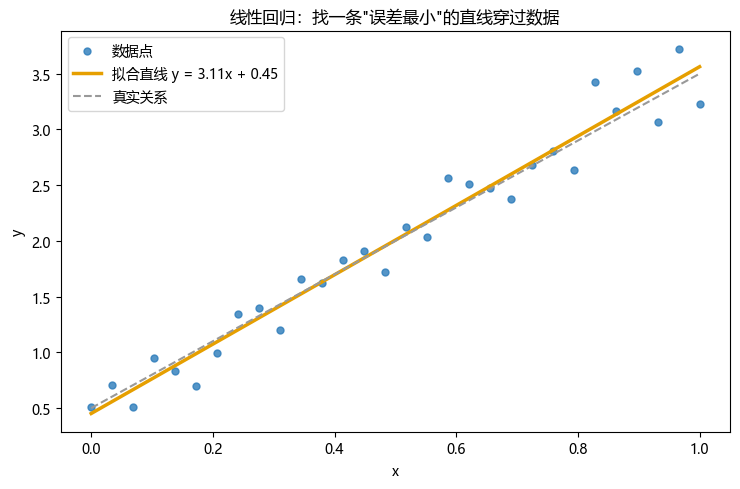

In [15]:
# ---- 一元线性回归：直观感受"用直线拟合数据" ----
np.random.seed(4)
X6 = np.linspace(0, 1, 30)
真实w6, 真实b6 = 3.0, 0.5
y6 = 真实w6 * X6 + 真实b6 + np.random.randn(30) * 0.2

# 用 numpy 的 polyfit（内部就是最小二乘法/正规方程）拟一条 1 阶直线
w6, b6 = np.polyfit(X6, y6, 1)
print(f"学到的参数：w = {w6:.3f}（真实 {真实w6}），b = {b6:.3f}（真实 {真实b6}）")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(X6, y6, color=蓝, alpha=0.8, s=25, label='数据点')
ax.plot(X6, w6 * X6 + b6, color=橙, lw=2.5, label=f'拟合直线 y = {w6:.2f}x + {b6:.2f}')
ax.plot(X6, 真实w6 * X6 + 真实b6, color=灰, lw=1.5, ls='--', label='真实关系')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('线性回归：找一条"误差最小"的直线穿过数据')
ax.legend()
plt.tight_layout()
plt.show()


## 4.2 代价函数：给这条直线「打分」

怎么判断一条直线好不好？看它**预测值和真实值差多少**。这就是**代价函数（cost function）**，线性回归最常用的是**均方误差 MSE**：

$$J(w, b) = \frac{1}{m}\sum_{i=1}^{m}\big(\hat y_i - y_i\big)^2 = \frac{1}{m}\sum_{i=1}^{m}\big((w x_i + b) - y_i\big)^2$$

逐项看：

- $m$ 是样本数量；
- $\hat y_i = w x_i + b$ 是第 $i$ 个样本的**预测值**（代入当前参数算出来的）；
- $y_i$ 是第 $i$ 个样本的**真实值**；
- **平方**让误差恒为正，且「大误差」被惩罚得更狠（第一章 1.5 讲过）；
- 整个式子就是「所有样本误差平方的**平均值**」。

我们的目标很明确：**找到让 $J(w,b)$ 最小的一组 $(w, b)$**。

那么「怎么找最小值」？有两条路：

1. **正规方程（Normal Equation）**：直接套公式，**一步解出**最优参数（本讲主角，解析解）；
2. **梯度下降（Gradient Descent）**：迭代逼近（第五章主角，数值解）。

> 💡 关键点：$J(w,b)$ 是**凸函数**（像一口「碗」，只有一个最低点），所以最小值在「导数等于 0」的地方——这为正规方程提供了理论依据。


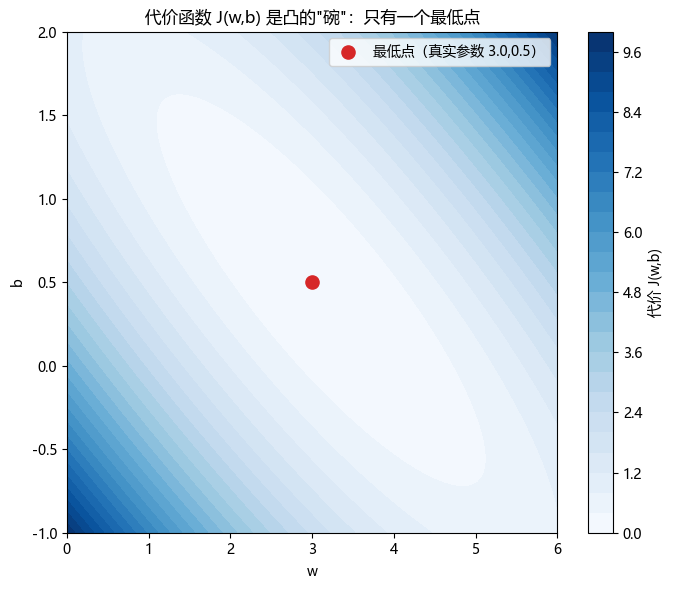

In [16]:
# ---- 代价函数 J(w,b) 是一口"碗"：最低点就是最优参数 ----
# 把 (w,b) 铺成网格，每个点算一次 MSE，画出代价函数的等高线/曲面。
def 代价(w, b):
    return np.mean((w * X6 + b - y6) ** 2)     # MSE

ws = np.linspace(0, 6, 100)
bs = np.linspace(-1, 2, 100)
W6, B6 = np.meshgrid(ws, bs)
Z6 = np.array([[代价(w, b) for w in ws] for b in bs])

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(W6, B6, Z6, levels=30, cmap='Blues')
fig.colorbar(c, label='代价 J(w,b)')
ax.scatter(真实w6, 真实b6, color=红, s=90, zorder=5, label=f'最低点（真实参数 {真实w6},{真实b6}）')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('代价函数 J(w,b) 是凸的"碗"：只有一个最低点')
ax.legend()
plt.tight_layout()
plt.show()

# 看到红点（真实参数）正好落在"碗底"（颜色最深处），
# 说明"让代价最小"确实等价于"找回真实参数"。


## 4.3 正规方程（Normal Equation）：一步解出最优参数

因为代价函数 $J$ 是凸的，最小值在**导数等于 0** 的地方。我们可以直接对 $J$ 求导、令导数为 0，**解出解析解**——这个解就是**正规方程**：

$$\boldsymbol{\theta} = \big(\mathbf{X}^\top \mathbf{X}\big)^{-1} \mathbf{X}^\top \mathbf{y}$$

其中：

- $\mathbf{X}$ 是样本矩阵，形状 $(m, n)$：$m$ 个样本、$n$ 个特征；
- 通常会在 $\mathbf{X}$ 最左边**补一列全 1**，用来表示截距 $b$（这样 $b$ 也变成一个「权重」，统一处理）；
- $\boldsymbol{\theta}$ 是要求的所有参数（包含 $w$ 和 $b$），形状 $(n+1, 1)$；
- $(\cdot)^{-1}$ 是矩阵求逆。

### 推导直觉（不用死记，理解思路即可）

我们要解「让 $J$ 最小的 $\boldsymbol{\theta}$」。把预测写成矩阵形式 $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\theta}$，我们的目标是让 $\hat{\mathbf{y}}$ 尽量接近 $\mathbf{y}$，即 $\mathbf{X}\boldsymbol{\theta} \approx \mathbf{y}$。

对 $J = \frac{1}{m}\|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|^2$ 求关于 $\boldsymbol{\theta}$ 的梯度并令其为 0，经过推导（后面 4.4 节逐步展开）就得到上面的正规方程。它本质就是**最小二乘法（least squares）**的解。

### 正规方程 vs 梯度下降

| | 正规方程 | 梯度下降 |
| --- | --- | --- |
| 需要选学习率 | ❌ 不需要 | ✅ 需要 |
| 需要迭代 | ❌ 一步到位 | ✅ 多次迭代 |
| 特征很多时 | 求逆慢，复杂度约 $O(n^3)$ | 仍然可行 |
| 适用场景 | 特征少、样本少 | 特征多、大数据 |

> 💡 一句话：**正规方程 = 用线性代数「一步」解出线性回归的最优参数**，特征不多时最省事；特征一多（几万、几十万维），求逆太慢，就要改用梯度下降。


## 4.4 正规方程的推导（最小二乘法视角）

这一节把 4.3 的公式一步步推出来，帮助理解它「为什么长这样」。核心思想是**最小二乘**：让所有样本的误差平方和最小。

### 第一步：写成矩阵形式

假设有 $m$ 个样本、$n$ 个特征，把数据写成矩阵：

$$\mathbf{X} = \begin{bmatrix} 1 & x_1^{(1)} & \cdots & x_n^{(1)} \\ 1 & x_1^{(2)} & \cdots & x_n^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_1^{(m)} & \cdots & x_n^{(m)} \end{bmatrix},\quad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{bmatrix},\quad \boldsymbol{\theta} = \begin{bmatrix} b \\ w_1 \\ \vdots \\ w_n \end{bmatrix}$$

注意 $\mathbf{X}$ 最左边补了一列全 1，对应偏置 $b$。这样预测值就是 $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\theta}$，误差向量是 $\mathbf{X}\boldsymbol{\theta} - \mathbf{y}$。

### 第二步：代价函数写成矩阵形式

$$J(\boldsymbol{\theta}) = \frac{1}{m}\big(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\big)^\top\big(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\big)$$

（右边就是「误差向量的平方和」的矩阵写法：一个列向量和自己做内积，等于各分量平方之和。）

### 第三步：对 $\boldsymbol{\theta}$ 求导，令为 0

利用矩阵求导公式 $\frac{\partial}{\partial \boldsymbol{\theta}}\|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|^2 = 2\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$，令其等于 0：

$$2\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) = 0 \;\Longrightarrow\; \mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} = \mathbf{X}^\top\mathbf{y}$$

### 第四步：解出 $\boldsymbol{\theta}$

两边同乘 $(\mathbf{X}^\top\mathbf{X})^{-1}$，得到：

$$\boldsymbol{\theta} = \big(\mathbf{X}^\top\mathbf{X}\big)^{-1}\mathbf{X}^\top\mathbf{y}$$

这就是正规方程。🔑 这个公式要能默写出来。


In [17]:
# ---- 用 numpy 从零实现正规方程：θ = (XᵀX)⁻¹ Xᵀ y ----
# 造一个"多元"线性数据，然后用正规方程一步解出所有参数。

np.random.seed(9)
m = 100
X_true = np.random.rand(m, 2)                  # 2 个特征
真实theta = np.array([1.5, -2.0])              # 真实的两个权重
真实b = 0.7
y_true = X_true @ 真实theta + 真实b + np.random.randn(m) * 0.1   # y = w1*x1 + w2*x2 + b + 噪声

# 关键：在 X 左边补一列全 1，用来表示截距 b
X_b = np.concatenate([np.ones((m, 1)), X_true], axis=1)   # 形状 (m, 3)

# 🔑 记忆：正规方程一步求解
theta_hat = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_true   # θ = (XᵀX)⁻¹ Xᵀ y

print("正规方程解出的参数：")
print(f"  截距 b  = {theta_hat[0]:.3f}  （真实 {真实b}）")
print(f"  权重 w1 = {theta_hat[1]:.3f}  （真实 {真实theta[0]}）")
print(f"  权重 w2 = {theta_hat[2]:.3f}  （真实 {真实theta[1]}）")

# 验证：用解出的参数预测，和真实值对比
y_pred = X_b @ theta_hat
print(f"\n均方误差 MSE = {np.mean((y_pred - y_true) ** 2):.5f}（很小，说明解得很准）")


正规方程解出的参数：
  截距 b  = 0.742  （真实 0.7）
  权重 w1 = 1.431  （真实 1.5）
  权重 w2 = -2.019  （真实 -2.0）

均方误差 MSE = 0.01009（很小，说明解得很准）


## 4.5 sklearn 实战：LinearRegression（第八、九讲）

实际开发中不用手写正规方程，`sklearn` 已经封装好了。两个关键点：

- **`LinearRegression()`**：默认 `fit_intercept=True`，**自动带截距**（相当于自动帮你补全 1 列）；
- **`fit_intercept=False`**：强制过原点（$b=0$），用于「理论上 $y$ 必须经过 0」的场景。

训练完 `fit(X, y)` 之后，可以：

- `.coef_` 查看权重 $w$；
- `.intercept_` 查看截距 $b$；
- `.predict(X)` 做预测；
- `.score(X, y)` 算 $R^2$（拟合优度，越接近 1 越好，1 表示完美拟合）。

> 💡 注意：`fit_intercept=True` 时，**不需要**手动往 X 里补全 1 列，sklearn 会自动处理；但如果你已经手动补了全 1 列，就应该设 `fit_intercept=False`，否则会重复算截距。


In [18]:
# ---- sklearn 的 LinearRegression：带截距 vs 不带截距 ----
from sklearn.linear_model import LinearRegression as LR

# ① 默认：自动带截距（内部自动补全 1 列）
model1 = LR()                       # fit_intercept=True（默认）
model1.fit(X_true, y_true)          # 直接喂原始特征，不需要手动补 1
print("① 带截距（默认）：")
print(f"   截距 intercept = {model1.intercept_:.3f}  （真实 {真实b}）")
print(f"   权重 coef_     = {np.round(model1.coef_, 3)}  （真实 {真实theta}）")

# ② 手动补了全 1 列，就要关掉自动截距
model2 = LR(fit_intercept=False)
model2.fit(X_b, y_true)             # 喂的 X 已经含全 1 列
print("\n② 手动补 1 列 + 关截距：")
print(f"   参数 = {np.round(model2.coef_, 3)}  （第一个是截距，后两个是权重）")

# ③ 强制过原点（b=0）
model3 = LR(fit_intercept=False)
model3.fit(X_true, y_true)
print("\n③ 强制过原点（b=0）：")
print(f"   权重 = {np.round(model3.coef_, 3)}  （没有截距）")

# 用 ① 的模型算 R² 评分
print(f"\n模型①的 R² = {model1.score(X_true, y_true):.4f}（越接近 1 越好）")


① 带截距（默认）：
   截距 intercept = 0.742  （真实 0.7）
   权重 coef_     = [ 1.431 -2.019]  （真实 [ 1.5 -2. ]）

② 手动补 1 列 + 关截距：
   参数 = [ 0.742  1.431 -2.019]  （第一个是截距，后两个是权重）

③ 强制过原点（b=0）：
   权重 = [ 2.136 -1.455]  （没有截距）

模型①的 R² = 0.9808（越接近 1 越好）


## 4.6 【李沐 d2l】线性回归的从零实现：模型→损失→优化三步曲

> 📌 **出处**：李沐《动手学深度学习 V2》第 3 章「线性回归的从零开始实现」
> 📎 **完整可运行代码**：`实战代码_李沐/线性回归-从零实现.ipynb`

李宏毅老师的「训练三步曲」在李沐 d2l 里被落到 **PyTorch 代码**。这一节把「从零实现」的三个零件讲透——**不用 `torch.nn`，只用 `torch.Tensor` 和自动求导**。

### 三步曲对照

| 三步曲 | 从零实现的代码 | 一句话 |
| --- | --- | --- |
| ① 模型 | `def linreg(X, w, b): return X @ w + b` | 参数 `w`、`b` 要标 `requires_grad=True` |
| ② 损失 | `def squared_loss(y_hat, y): return (y_hat - y)**2 / 2` | 平方损失，除以 2 让导数更简洁 |
| ③ 优化 | `def sgd(params, lr, batch_size)` | 小批量 SGD，更新后 `grad.zero_()` |

### 训练循环的四行核心

```python
for X, y in data_iter(batch_size, features, labels):
    l = loss(net(X, w, b), y)    # ① 前向：算一个小批量的损失
    l.sum().backward()           # ② 反向：自动求梯度
    sgd([w, b], lr, batch_size)  # ③ 更新参数
```

> 🔑 **记忆（从零实现的关键细节）**：
> - 参数要 `requires_grad=True` 才会被自动求导跟踪；
> - 损失要先 `.sum()`（或 `.mean()`）聚成一个**标量**再 `.backward()`；
> - 更新参数时用 `with torch.no_grad()` 包住，更新后必须 `grad.zero_()` **清零**，否则梯度会累加。


## 4.7 【李沐 d2l】线性回归的简洁实现：框架 API 一行代替

> 📌 **出处**：李沐《动手学深度学习 V2》第 3 章「线性回归的简洁实现」
> 📎 **完整可运行代码**：`实战代码_李沐/线性回归-简洁实现.ipynb`

工业界直接用框架封装好的 API，代码量少一大半、还不易出错：

| 手写（从零） | 框架 API（简洁） |
| --- | --- |
| 手写 `data_iter` | `DataLoader` + `TensorDataset` |
| 手写 `linreg` | `nn.Sequential(nn.Linear(2, 1))` |
| 手写 `squared_loss` | `nn.MSELoss` |
| 手写 `sgd` | `optim.SGD(net.parameters(), lr=...)` |

```python
net = nn.Sequential(nn.Linear(2, 1))               # 模型：2 输入 → 1 输出
loss = nn.MSELoss()                                 # 损失：均方误差
trainer = torch.optim.SGD(net.parameters(), lr=0.03) # 优化器

for X, y in data_iter:
    l = loss(net(X), y)   # ① 前向 + 损失
    trainer.zero_grad()   # ② 清零梯度（= 从零实现的 grad.zero_()）
    l.backward()          # ③ 反向求梯度
    trainer.step()        # ④ 更新参数
```

> 🔑 **记忆**：简洁实现的训练循环骨架是**四步**——前向算 loss → `zero_grad()` → `backward()` → `step()`。这套骨架后面所有神经网络（CNN/RNN/Transformer）都通用，要背下来。


## 4.8 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 线性回归 | 用直线（超平面）拟合数据，输出连续数值 |
| 假设函数 | $y = \mathbf{w}^\top\mathbf{x} + b$，待学的参数是 $w$ 和 $b$ |
| 代价函数 MSE | 预测值和真实值差的平方的平均，越小越好 |
| 正规方程 | $\boldsymbol{\theta}=(X^\top X)^{-1}X^\top y$，一步解出最优参数 |
| sklearn | `LinearRegression(fit_intercept=...)` 一行搞定线性回归 |

🔑 **记忆**：正规方程公式 $\boldsymbol{\theta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$；`LinearRegression` 默认带截距、不需要手动补 1 列。

> 📌 **下一步**：第五章讲梯度下降（数值解），把正规方程的「解析解」和梯度下降的「数值解」真正对应起来。


# 第五章 梯度下降

> 📌 **出处**：李宏毅 2026《机器学习》**第 10~17 讲**（梯度下降专题：概念 → 代码 → 可视化 → BGD/SGD/MBGD → 学习率/特征缩放/动量）
> ⭐ **40 天重点**：对应计划 Day11「最优化基础」——*梯度下降及其变体、动量法、Adam 优化器原理*。这一章把第一章「梯度下降」的直觉，落地成能真正跑起来的算法，并系统讲解三种变体和两个关键技巧（特征缩放、动量）。

---

## 5.1 回顾：梯度下降到底在做什么

第一章 1.6 建立了直觉，这里先快速回顾并补齐细节。梯度下降的更新公式：

$$\theta \leftarrow \theta - \eta \cdot \nabla L(\theta)$$

- $\theta$：要优化的参数（如 $w, b$）；
- $\nabla L(\theta)$：损失对参数的**梯度**（指向损失上升最快的方向）；
- $\eta$：**学习率**，控制步长。

对一元线性回归 $y = wx + b$、损失 MSE，可以手推两个偏导（🔑 要会推）：

$$\frac{\partial L}{\partial w} = \frac{2}{m}\sum_{i=1}^{m}(\hat y_i - y_i)\,x_i, \qquad \frac{\partial L}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}(\hat y_i - y_i)$$

> 💡 **停止条件**：理论上梯度 = 0 时到最低点，但实际几乎不会正好等于 0，通常**人为设定迭代次数**或「误差小于某个阈值」就停。


结果：w = 2.0203（真实 2），b = 1.0135（真实 1），损失 = 0.01795


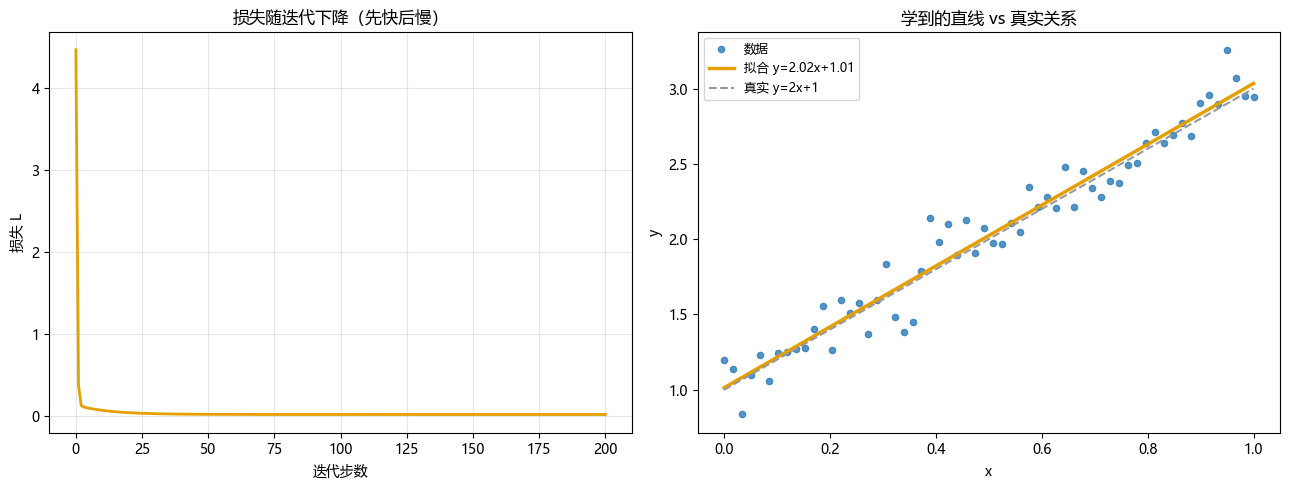

In [19]:
# ---- 从零实现梯度下降：求解一元线性回归 y = w·x + b ----
# 把第一章的"三步曲 + 梯度下降"重新完整走一遍，并记录收敛过程。
np.random.seed(10)
X7 = np.linspace(0, 1, 60)
y7 = 2.0 * X7 + 1.0 + np.random.randn(60) * 0.15     # 真实 w=2, b=1

def 损失7(w, b):
    return np.mean((w * X7 + b - y7) ** 2)

# 梯度下降（普通批量版 BGD）
w, b = 0.0, 0.0
lr = 0.3
历史 = []                       # 记录每一步的 (w, b, 损失)
for step in range(200):
    历史.append((w, b, 损失7(w, b)))
    y_pred = w * X7 + b
    dw = np.mean(2 * (y_pred - y7) * X7)    # ∂L/∂w
    db = np.mean(2 * (y_pred - y7))         # ∂L/∂b
    w -= lr * dw
    b -= lr * db
历史.append((w, b, 损失7(w, b)))

print(f"结果：w = {w:.4f}（真实 2），b = {b:.4f}（真实 1），损失 = {损失7(w,b):.5f}")

# 可视化收敛曲线
hist = np.array(历史)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(hist[:, 2], color=橙, lw=2)
axes[0].set_xlabel('迭代步数'); axes[0].set_ylabel('损失 L')
axes[0].set_title('损失随迭代下降（先快后慢）')
axes[0].grid(alpha=0.3)

axes[1].scatter(X7, y7, color=蓝, s=20, alpha=0.8, label='数据')
axes[1].plot(X7, w * X7 + b, color=橙, lw=2.5, label=f'拟合 y={w:.2f}x+{b:.2f}')
axes[1].plot(X7, 2 * X7 + 1, color=灰, lw=1.5, ls='--', label='真实 y=2x+1')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); axes[1].legend(fontsize=9)
axes[1].set_title('学到的直线 vs 真实关系')
plt.tight_layout()
plt.show()

# 左图注意：损失一开始掉得飞快（坡度大），越到后面越平缓（逼近谷底、梯度变小）。


## 5.2 三种梯度下降：BGD / SGD / MBGD

梯度下降有一个关键变体问题：**每次更新参数时，用多少条数据来算梯度？** 据此分成三种：

| 方法 | 一次更新用多少数据 | 优点 | 缺点 |
| --- | --- | --- | --- |
| **BGD 批量梯度下降** | **全部**样本 | 梯度稳、方向准 | 每次都要扫全量数据，慢 |
| **SGD 随机梯度下降** | **1 条**样本 | 快、能逃离局部最小 | 梯度抖、方向乱 |
| **MBGD 小批量梯度下降** | **一小批**（如 32/64） | 折中：稳又快 | 要选 batch size |

### 更新公式对比（设 $\hat y_i = w x_i + b$）

- **BGD**：用全部 $m$ 条数据求平均梯度

  $$w \leftarrow w - \eta\,\frac{2}{m}\sum_{i=1}^{m}(\hat y_i - y_i)\,x_i$$

- **SGD**：每次随机抽 **1 条** $i$ 更新

  $$w \leftarrow w - \eta \cdot 2(\hat y_i - y_i)\,x_i$$

- **MBGD**：每次随机抽**一小批** $B$ 更新

  $$w \leftarrow w - \eta\,\frac{2}{|B|}\sum_{i \in B}(\hat y_i - y_i)\,x_i$$

### 为什么 SGD 能「逃离局部最小」？

BGD 用全量数据算梯度，方向非常「稳」，但也容易一头扎进某个局部最低点出不来。SGD 每次只用一条数据，梯度里带着这条数据的「随机性」——方向有点「抖」，反而有机会从局部最小的坑里「抖」出来。但也因为抖，SGD 收敛到最后会围着最优解来回震荡，不如 BGD 稳。

> 💡 实际深度学习里几乎都用 **MBGD**（PyTorch 里叫 mini-batch SGD）。注意：很多论文里的 "SGD" 其实泛指「小批量随机梯度下降」。


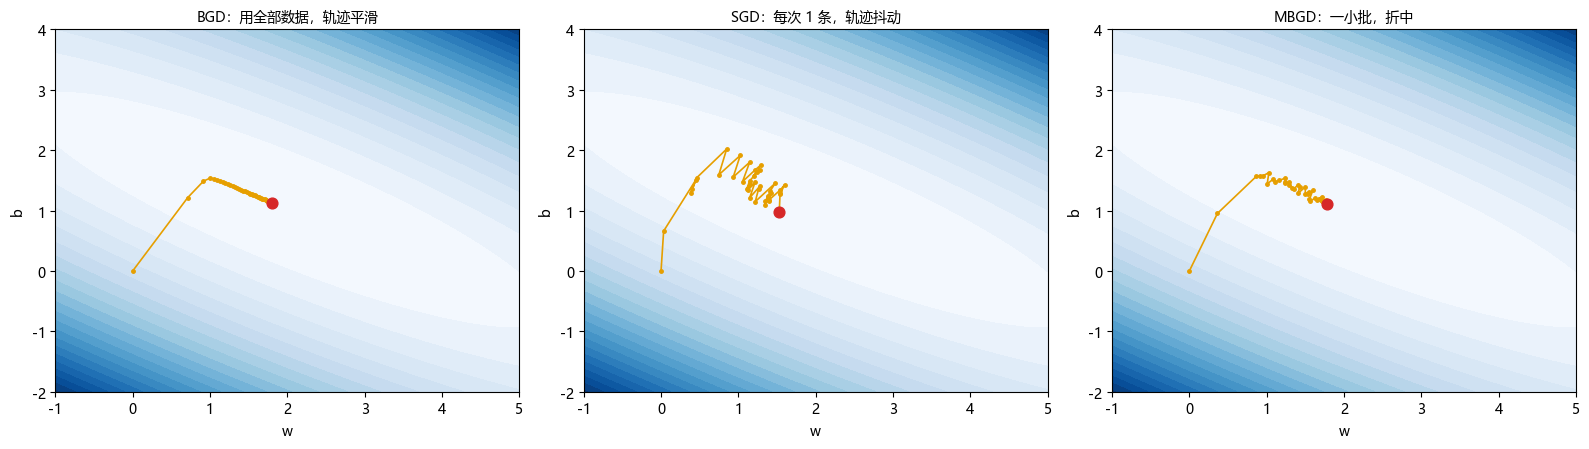

In [20]:
# ---- 三种梯度下降对比：BGD / SGD / MBGD 的收敛轨迹 ----
# 用同一个损失曲面，对比三种方法的收敛路径。
def 计算梯度(w, b, X_batch, y_batch):
    y_pred = w * X_batch + b
    dw = np.mean(2 * (y_pred - y_batch) * X_batch)
    db = np.mean(2 * (y_pred - y_batch))
    return dw, db

def 跑梯度下降(方法, lr, 步数=40, batch=8):
    w, b = 0.0, 0.0
    轨 = [(w, b)]
    idx = np.arange(len(X7))
    for _ in range(步数):
        if 方法 == 'BGD':
            dw, db = 计算梯度(w, b, X7, y7)              # 全量
        elif 方法 == 'SGD':
            i = np.random.randint(len(X7))               # 随机 1 条
            dw, db = 计算梯度(w, b, X7[i:i+1], y7[i:i+1])
        else:  # MBGD
            b_idx = np.random.choice(idx, batch, replace=False)   # 随机一小批
            dw, db = 计算梯度(w, b, X7[b_idx], y7[b_idx])
        w -= lr * dw; b -= lr * db
        轨.append((w, b))
    return np.array(轨)

# 造损失曲面（复用 X7/y7）
ws7 = np.linspace(-1, 5, 80); bs7 = np.linspace(-2, 4, 80)
W7, B7 = np.meshgrid(ws7, bs7)
Z7 = np.array([[损失7(w, b) for w in ws7] for b in bs7])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, 方法, t in zip(axes, ['BGD', 'SGD', 'MBGD'],
                       ['BGD：用全部数据，轨迹平滑', 'SGD：每次 1 条，轨迹抖动', 'MBGD：一小批，折中']):
    轨 = 跑梯度下降(方法, 0.3, 40)
    ax.contourf(W7, B7, Z7, levels=25, cmap='Blues')
    ax.plot(轨[:, 0], 轨[:, 1], 'o-', color=橙, lw=1.2, ms=2.5)
    ax.scatter(*轨[-1], color=红, s=60, zorder=5)
    ax.set_title(t, fontsize=10)
    ax.set_xlabel('w'); ax.set_ylabel('b')
plt.tight_layout()
plt.show()

# 观察：BGD 轨迹平滑直达谷底；SGD 轨迹弯弯曲曲（每条数据的方向不同）；MBGD 介于两者之间。


## 5.3 学习率与特征缩放：让梯度下降「快而稳」的两个关键

### 学习率 $\eta$ 的影响（第一章已演示，这里补一个实用经验）

学习率太小「蚂蚁爬」，太大「青蛙乱跳」甚至发散（第一章 1.7 有图）。一个实用观察是：收敛过程中损失往往**先快后慢**，并可能在最优解附近**来回震荡**（尤其 SGD/MBGD）。

### 特征缩放（Feature Scaling）：为什么梯度下降需要它

如果特征的**量纲差别很大**（比如「面积 100 平米」vs「房间数 3 间」），会发生一件坏事：**损失曲面变成一个又窄又长的「碗」**。

- 大尺度特征方向曲率很大（梯度很大），小尺度特征方向曲率很小（梯度很小）；
- 一个学习率顾得了这头就顾不了那头——用小学习率，大尺度方向走不动；用大学习率，小尺度方向直接飞出碗；
- 结果：**小尺度特征几乎学不到**，收敛极慢。

**特征缩放**就是把所有特征缩到相近的范围，让损失曲面变「圆」，一个学习率就能同时照顾所有方向。

两种常见方法（第七章特征工程会详细展开）：

- **Min-Max 归一化**：$x' = \dfrac{x - \min}{\max - \min}$，缩到 $[0, 1]$；
- **标准化（Z-Score）**：$x' = \dfrac{x - \mu}{\sigma}$，变成均值 0、标准差 1（**最常用**）。


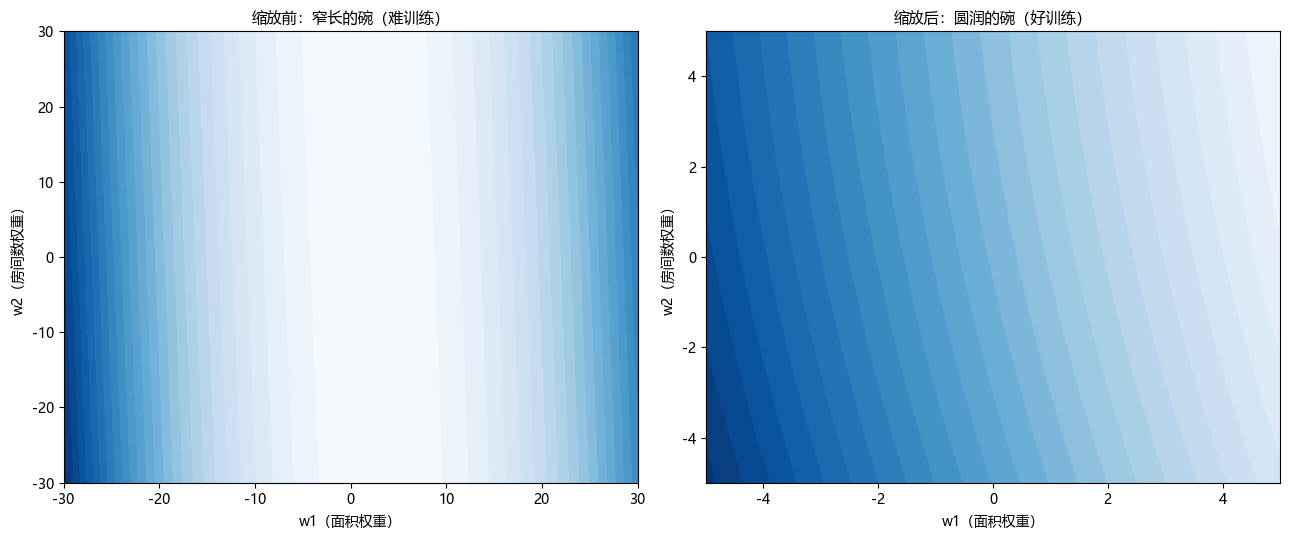

In [21]:
# ---- 特征缩放：为什么梯度下降需要它 ----
# 造一个"面积(大数值)"和"房间数(小数值)"量纲悬殊的例子，对比缩放前后的损失曲面形状。
np.random.seed(12)
面积 = np.random.rand(50) * 100        # 面积：0 ~ 100（大数值）
房间数 = np.random.rand(50) * 4        # 房间数：0 ~ 4（小数值）
房价 = 面积 * 2 + 房间数 * 10 + np.random.randn(50) * 5

X_raw = np.c_[面积, 房间数]            # 原始特征：量纲悬殊

def 损失二维(w1, w2, Xm, ym):
    return np.mean((Xm @ np.array([w1, w2]) - ym) ** 2)

# 标准化（Z-Score）：(x - 均值) / 标准差
mu = X_raw.mean(axis=0); sigma = X_raw.std(axis=0)
X_scale = (X_raw - mu) / sigma

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, Xm, t in zip(axes, [X_raw, X_scale], ['缩放前：窄长的碗（难训练）', '缩放后：圆润的碗（好训练）']):
    w1s = np.linspace(-30, 30, 60) if Xm is X_raw else np.linspace(-5, 5, 60)
    w2s = np.linspace(-30, 30, 60) if Xm is X_raw else np.linspace(-5, 5, 60)
    WW1, WW2 = np.meshgrid(w1s, w2s)
    ZZ = np.array([[损失二维(w1, w2, Xm, 房价) for w1 in w1s] for w2 in w2s])
    ax.contourf(WW1, WW2, ZZ, levels=25, cmap='Blues')
    ax.set_title(t, fontsize=11)
    ax.set_xlabel('w1（面积权重）'); ax.set_ylabel('w2（房间数权重）')
plt.tight_layout()
plt.show()

# 左图（缩放前）：等高线是"又窄又长"的椭圆，梯度下降会在窄方向上震荡、宽方向上爬不动；
# 右图（缩放后）：等高线接近"圆"，梯度下降能又快又稳地直达中心。


## 5.4 动量 Momentum：给梯度下降「带上惯性」

普通梯度下降只看「当前梯度」。如果损失曲面有**平坦区**（梯度很小，几乎不动）或**窄长谷**（来回震荡），收敛会很慢。**动量（Momentum）** 给更新「带上惯性」，像球滚下山，能更快冲过平坦区、减少震荡：

$$v \leftarrow \gamma\, v + \eta\,\nabla L(\theta), \qquad \theta \leftarrow \theta - v$$

- $v$ 是「速度」，累积了**历史梯度**，$v$ 初始为 0；
- $\gamma$ 是**动量系数**（通常取 0.9），控制「保留多少上一次的方向」；
- 更新时**参考了之前的方向**：震荡方向（正负来回）会被抵消，一致方向会被加速。

直觉：就像从山上滚下来的球——它滚的方向不仅由当前坡度决定，还带着之前的「惯性」。遇到平坦区，惯性会带着它继续往前冲；在窄谷里震荡时，惯性会把来回的晃动「抹平」。

> 📌 **出处**：Momentum 是 **Adam** 等现代优化器的基础。第六章「Batch 与优化器」会讲 Momentum 之上的完整优化器家族（AdaGrad / RMSProp / Adam）。


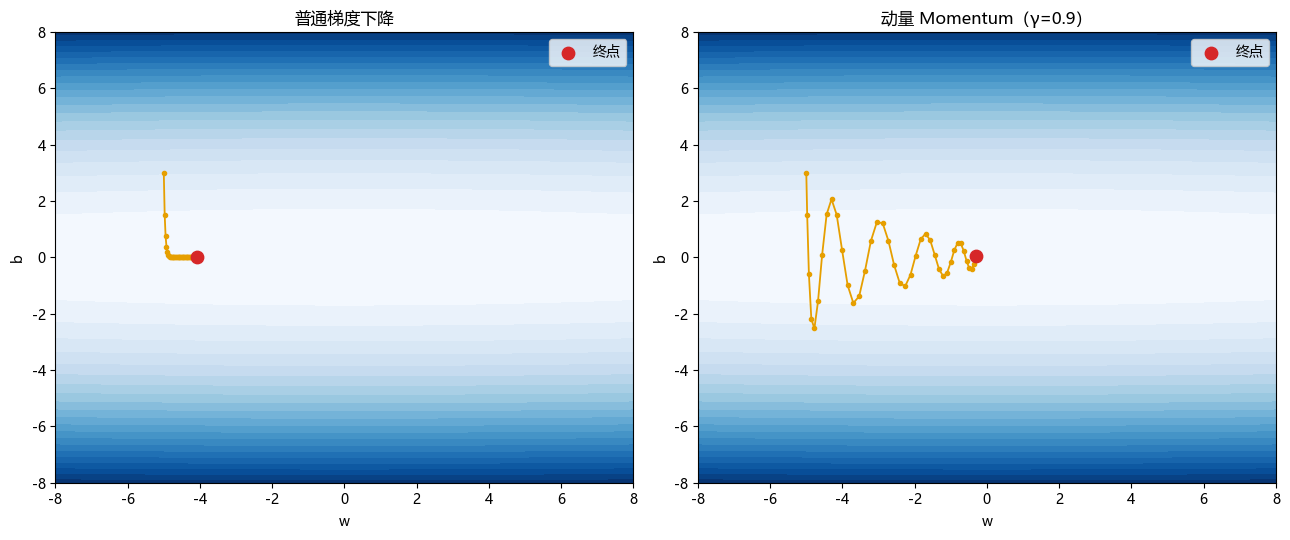

In [22]:
# ---- 动量 vs 普通梯度下降：谁更快冲过"窄长谷" ----
# 用一个狭长的损失函数，对比普通 GD 和带动量的 GD 的收敛速度。
def 窄长损失(w, b):
    return 0.05 * w**2 + 5 * b**2      # w 方向平缓（系数小）、b 方向陡峭（系数大）→ 窄长谷

def 跑(带动量, lr=0.05, 动量系数=0.9, 步数=40):
    w, b = -5.0, 3.0
    vw, vb = 0.0, 0.0
    轨 = [(w, b)]
    for _ in range(步数):
        gw, gb = 0.1 * w, 10 * b          # 梯度：∂L/∂w = 0.1w，∂L/∂b = 10b
        if 带动量:
            vw = 动量系数 * vw + lr * gw   # 累积速度
            vb = 动量系数 * vb + lr * gb
            w -= vw; b -= vb               # 用速度更新
        else:
            w -= lr * gw; b -= lr * gb     # 普通 GD
        轨.append((w, b))
    return np.array(轨)

轨_普通 = 跑(False, lr=0.05, 步数=40)
轨_动量 = 跑(True, lr=0.05, 步数=40)

ww = np.linspace(-8, 8, 100); bb = np.linspace(-8, 8, 100)
WW, BB = np.meshgrid(ww, bb)
ZZ = 0.05 * WW**2 + 5 * BB**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, 轨, t in zip(axes, [轨_普通, 轨_动量], ['普通梯度下降', '动量 Momentum（γ=0.9）']):
    ax.contourf(WW, BB, ZZ, levels=30, cmap='Blues')
    ax.plot(轨[:, 0], 轨[:, 1], 'o-', color=橙, lw=1.3, ms=3)
    ax.scatter(*轨[-1], color=红, s=80, zorder=5, label='终点')
    ax.set_title(t, fontsize=12)
    ax.set_xlabel('w'); ax.set_ylabel('b'); ax.legend()
plt.tight_layout()
plt.show()

# 观察：普通 GD 在窄长谷里"之字形"震荡、前进缓慢；动量累积了往左的速度，震荡被抵消，更快冲到中心。


## 5.5 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 梯度下降 | 每次朝负梯度方向走一小步，逼近最优解 |
| BGD / SGD / MBGD | 一次更新用全部 / 1 条 / 一小批数据 |
| 学习率 | 步长：太小慢、太大发散 |
| 特征缩放 | 把特征缩到同量级，让损失曲面变「圆」，收敛更快 |
| 动量 Momentum | 带惯性下坡，冲过平坦区、减少震荡 |

🔑 **记忆**：三种梯度下降的更新公式（5.2 节表格）；特征缩放的 Z-Score 公式 $x'=(x-\mu)/\sigma$；动量公式 $v \leftarrow \gamma v + \eta\nabla L$。

> 📌 **下一步**：第六章讲 **Batch 与优化器**——batch size 怎么选、Momentum 之上的自适应学习率（AdaGrad/RMSProp/Adam）、以及「局部最小值 vs 鞍点」的真相。


# 第六章 Batch 与优化器

> 📌 **出处**：李宏毅 2026《机器学习》**第 22~35 讲**（批次 batch 与动量 momentum、自动调整学习速率、局部最小值与鞍点）
> ⭐ **40 天重点**：对应计划 Day11「最优化基础」——*动量法、Adam 优化器原理*。这一章把梯度下降升级成「现代优化器」，讲清楚 batch size 怎么选、学习率怎么自动调、以及「卡在局部最小」这个担忧到底成不成立。

---

## 6.1 Batch Size：一次更新用多少数据，影响的不只是速度

第五章讲过 BGD/SGD/MBGD 的区别是「一次用多少数据」。这个「多少」就是 **batch size（批大小）**。这一节深入它带来的**三种影响**。

### ① 训练速度（一次更新耗时）

直觉上「batch 越大一次更新越慢」，但在有 GPU 的现代环境里没那么简单：

- **大 batch**：每次算梯度要扫很多数据，单次更新慢；但 GPU 擅长**并行**，一次算 1000 条的梯度和算 1 条的耗时差不多（并行度上来了），所以**总耗时未必更大**；
- **小 batch**：单次更新快，但要更新很多次才能看完全部数据。

> 结论：在 GPU 上，「大 batch 慢、小 batch 快」这个直觉**不总是成立**，因为大 batch 能充分利用并行。真正决定速度的往往是别的因素。

### ② 收敛稳定性与噪声

- **大 batch**：梯度是「大量数据的平均」，噪声小、方向稳，收敛平稳；
- **小 batch**：梯度噪声大、方向抖，收敛过程「吵吵闹闹」。

### ③ 泛化能力（这是最反直觉、也最重要的一点）

研究发现：**小 batch 训练出来的模型，泛化能力往往更好**（在测试集上表现更佳），而大 batch 容易「泛化差」。一个被普遍接受的解释是：小 batch 的梯度噪声像一种「隐式正则化」，让模型不容易卡在尖锐的、泛化差的解里；大 batch 走得太「顺」，容易停在尖锐的最优点。

> 💡 实用建议：batch size 是一个**要调的超参数**，常见取值 32、64、128、256。没有「越大越好」或「越小越好」，要看具体任务，通常在小 batch 上更容易得到好结果，但要用并行补偿速度。


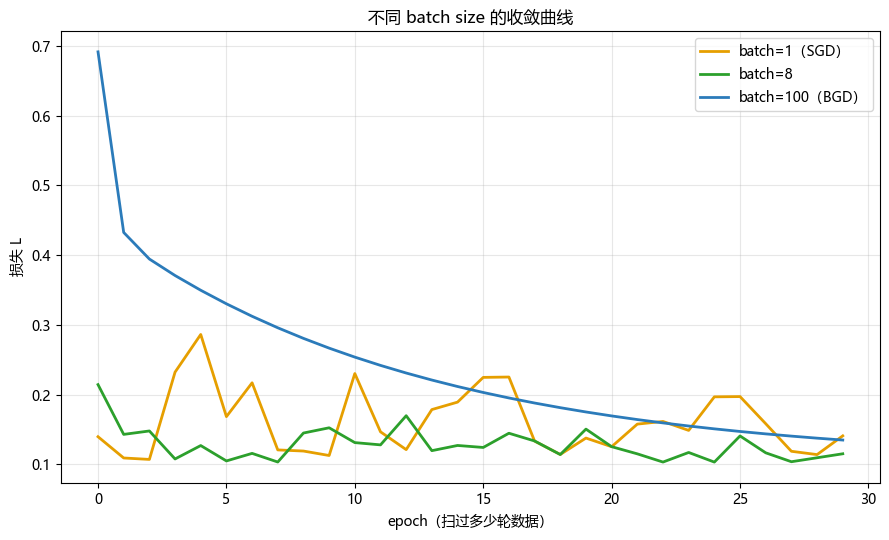

In [23]:
# ---- Batch Size 对收敛的影响：不同 batch size 的损失曲线对比 ----
# 用同一个线性回归问题，对比 batch size = 1 / 8 / 全量 的收敛过程。
np.random.seed(20)
X8 = np.linspace(0, 1, 100)
y8 = 3.0 * X8 + 0.5 + np.random.randn(100) * 0.3

def 损失8(w, b):
    return np.mean((w * X8 + b - y8) ** 2)

def 梯度8(w, b, idx):
    y_pred = w * X8[idx] + b
    return np.mean(2 * (y_pred - y8[idx]) * X8[idx]), np.mean(2 * (y_pred - y8[idx]))

def 跑_batch(batch_size, lr=0.3, 轮数=30):
    """每个 epoch 用 batch_size 的 mini-batch 扫一遍数据，记录损失。"""
    w, b = 0.0, 0.0
    曲线 = []
    idx = np.arange(len(X8))
    for _ in range(轮数):
        np.random.shuffle(idx)                  # 每轮先打乱
        for start in range(0, len(X8), batch_size):
            batch_idx = idx[start:start + batch_size]
            dw, db = 梯度8(w, b, batch_idx)
            w -= lr * dw; b -= lr * db
        曲线.append(损失8(w, b))
    return 曲线

fig, ax = plt.subplots(figsize=(9, 5.5))
for bs, c, name in [(1, 橙, 'batch=1（SGD）'), (8, 绿, 'batch=8'), (100, 蓝, 'batch=100（BGD）')]:
    曲线 = 跑_batch(bs, lr=0.3, 轮数=30)
    ax.plot(曲线, color=c, lw=2, label=name)
ax.set_xlabel('epoch（扫过多少轮数据）'); ax.set_ylabel('损失 L')
ax.set_title('不同 batch size 的收敛曲线')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 观察：batch=1 抖动明显但收敛快；batch=100 平滑；batch=8 折中。


## 6.2 局部最小值 vs 鞍点：深度学习真正怕的是哪一个？

第一章提过梯度下降的两个隐患：**局部最小值**和**鞍点**。这一节揭示一个颠覆常识的结论。

### 先分清这两个概念

梯度 $\nabla L = 0$ 的点，统称「临界点（critical point）」。但临界点有三种：

- **局部最小值（local minimum）**：四周都比它高，真「坑底」；
- **局部最大值（local maximum）**：四周都比它低（少见，不关心）；
- **鞍点（saddle point）**：马鞍形——沿某些方向是「谷」（下坡），沿另一些方向是「峰」（上坡）。梯度为 0，但不是最低点。

### 高维空间里，鞍点远比局部最小值多

直觉上，在一个 $d$ 维空间里，一个点是「局部最小值」需要**所有** $d$ 个方向都往上翘；而「鞍点」只需要**一部分方向翘、一部分方向凹**。随着维度 $d$ 变大，「所有方向都翘」的概率急剧下降，而「一半翘一半凹」的组合越来越多。

> 💡 结论：**在深度学习的高维参数空间里，真正的局部最小值其实非常罕见，我们遇到的大多数「梯度为 0」的点都是鞍点。** 所以「梯度下降会卡在局部最小」这个担忧，在深度学习里很大程度上是**多虑**了——真正让人头疼的是鞍点（以及损失曲面的形状），而 Momentum、Adam 这些方法正是在帮我们更快穿过鞍点和平坦区。


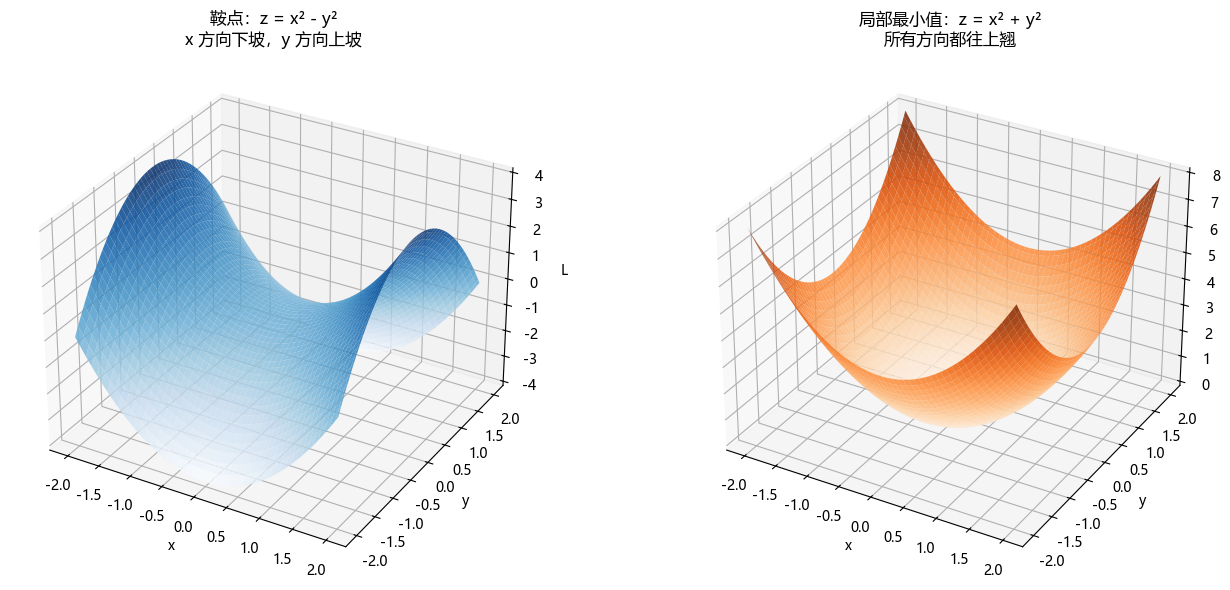

In [24]:
# ---- 鞍点 vs 局部最小值：3D 可视化 ----
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-2, 2, 100); y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(14, 6))
# 左：鞍点 z = x² - y²（马鞍形：x 方向是谷，y 方向是峰）
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
Z1 = X**2 - Y**2
ax1.plot_surface(X, Y, Z1, cmap='Blues', alpha=0.85)
ax1.set_title('鞍点：z = x² - y²\nx 方向下坡，y 方向上坡')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('L')

# 右：局部最小值 z = x² + y²（碗形：所有方向都往上翘）
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
Z2 = X**2 + Y**2
ax2.plot_surface(X, Y, Z2, cmap='Oranges', alpha=0.85)
ax2.set_title('局部最小值：z = x² + y²\n所有方向都往上翘')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('L')

plt.tight_layout()
plt.show()

# 左图中心点：梯度为 0，但不是最低点（沿 x 方向还能往下走）——这就是鞍点；
# 右图中心点：真正的"坑底"，四周都是上坡——局部最小值。


## 6.3 为什么需要「自动调整学习速率」：每个参数该有不同的学习率

前面所有梯度下降都用一个**全局统一的学习率** $\eta$ 更新所有参数。这带来一个问题：**不同的参数，需要的学习率可能天差地别**。

回想第五章特征缩放里的「窄长碗」：有的方向陡、有的方向平。一个统一的学习率，对陡方向可能太大（震荡发散）、对平方向又太小（爬不动）。特征缩放能在一定程度上缓解，但更根本的解决思路是：**让每个参数拥有自己的、能自动调整的学习率**。

这就是**自适应学习率优化器**的思想。它们共同的做法是：**根据每个参数「历史梯度」的大小，自动缩放它的学习率**——梯度一直很大的参数，学习率自动变小；梯度一直很小的参数，学习率自动变大。下面看三种经典实现。


## 6.4 三种自适应学习率优化器：AdaGrad / RMSProp / Adam

### ① AdaGrad：用「所有历史梯度平方和」缩放

设第 $t$ 步参数 $\theta_i$ 的梯度为 $g_i^t$，AdaGrad 维护一个**梯度平方的累加和**：

$$v_i^t = v_i^{t-1} + (g_i^t)^2, \qquad \theta_i^{t+1} = \theta_i^t - \frac{\eta}{\sqrt{v_i^t + \epsilon}}\; g_i^t$$

- 分母 $\sqrt{v_i^t}$ 是「历史梯度平方和」的开方：某个参数的梯度一直很大，$v$ 就大，学习率自动变小；反之变大；
- 缺点：$v$ **只增不减**，训练到后期分母越来越大，学习率被压到几乎为 0，**过早停止学习**。

### ② RMSProp：只记「近期」的梯度平方

为了修 AdaGrad 的「只增不减」，RMSProp 把「累加」改成**指数加权移动平均**，让久远的梯度影响力衰减：

$$v_i^t = \beta\, v_i^{t-1} + (1-\beta)(g_i^t)^2, \qquad \theta_i^{t+1} = \theta_i^t - \frac{\eta}{\sqrt{v_i^t + \epsilon}}\; g_i^t$$

- $\beta$（通常 0.9）控制「记住多少历史」：越接近 1 记得越久；
- 这样 $v$ 会随近期梯度变化，不会无限增长。

### ③ Adam：Momentum + RMSProp 的结合体

Adam（Adaptive Moment Estimation）是**目前最常用的优化器**，把「动量」和「自适应学习率」合二为一：

$$m_i^t = \beta_1 m_i^{t-1} + (1-\beta_1) g_i^t \quad(\text{一阶矩，类似动量})$$
$$v_i^t = \beta_2 v_i^{t-1} + (1-\beta_2)(g_i^t)^2 \quad(\text{二阶矩，类似 RMSProp})$$
$$\hat m_i^t = \frac{m_i^t}{1-\beta_1^t}, \quad \hat v_i^t = \frac{v_i^t}{1-\beta_2^t} \quad(\text{偏差校正})$$
$$\theta_i^{t+1} = \theta_i^t - \frac{\eta}{\sqrt{\hat v_i^t} + \epsilon}\,\hat m_i^t$$

- $m$ 提供「惯性」（方向），$v$ 提供「自适应步长」（缩放）；
- 两个「偏差校正」是为了修正 $m,v$ 初始为 0 带来的前期偏小（$t$ 是步数，$\beta^t$ 随 $t$ 增大趋近 0）；
- 常用超参数：$\eta=0.001,\ \beta_1=0.9,\ \beta_2=0.999,\ \epsilon=10^{-8}$。

> 🔑 **记忆**：**Adam = 动量 + RMSProp**，默认首选优化器；它的四个默认超参数（lr=0.001, β1=0.9, β2=0.999, ε=1e-8）值得记住。


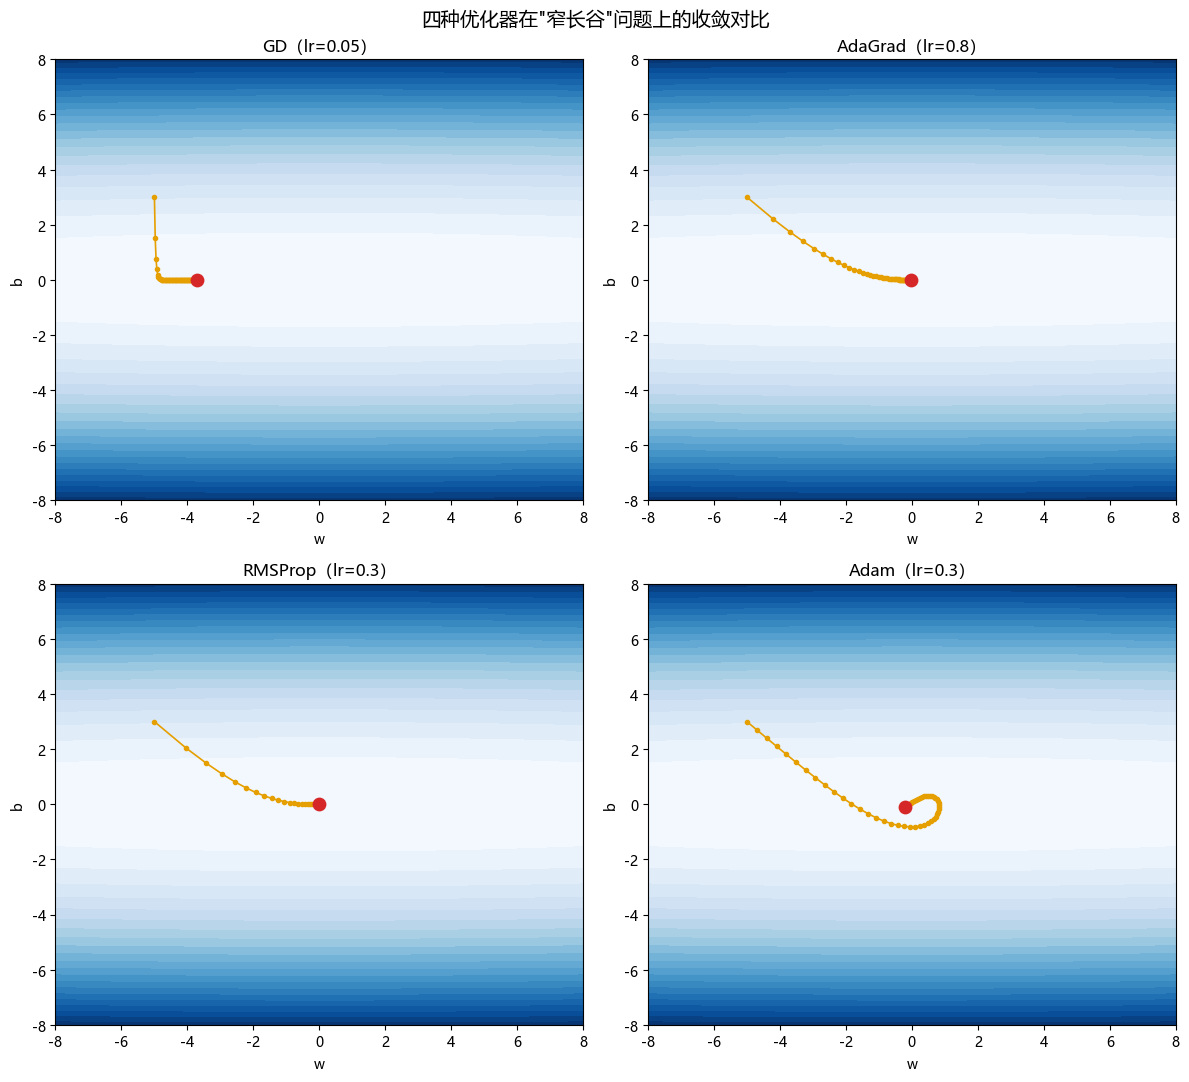

In [25]:
# ---- AdaGrad / RMSProp / Adam 从零实现 + 收敛对比 ----
# 在第五章那个"窄长谷"问题上，对比普通 GD 和三种自适应优化器。
def 窄长损失2(w, b):
    return 0.05 * w**2 + 5 * b**2

def 梯度_窄长(w, b):
    return 0.1 * w, 10 * b      # ∂L/∂w = 0.1w，∂L/∂b = 10b

def 跑优化器(方法, lr, 步数=60):
    w, b = -5.0, 3.0
    vw, vb = 0.0, 0.0           # 二阶矩（AdaGrad/RMSProp/Adam 用）
    mw, mb = 0.0, 0.0           # 一阶矩（Adam 用）
    轨 = [(w, b)]
    for t in range(1, 步数 + 1):
        gw, gb = 梯度_窄长(w, b)
        if 方法 == 'GD':
            w -= lr * gw; b -= lr * gb
        elif 方法 == 'AdaGrad':
            vw += gw**2; vb += gb**2                 # 累加平方（只增不减）
            w -= lr * gw / (np.sqrt(vw) + 1e-8); b -= lr * gb / (np.sqrt(vb) + 1e-8)
        elif 方法 == 'RMSProp':
            vw = 0.9 * vw + 0.1 * gw**2; vb = 0.9 * vb + 0.1 * gb**2   # 指数平均
            w -= lr * gw / (np.sqrt(vw) + 1e-8); b -= lr * gb / (np.sqrt(vb) + 1e-8)
        elif 方法 == 'Adam':
            mw = 0.9 * mw + 0.1 * gw; mb = 0.9 * mb + 0.1 * gb          # 一阶矩(动量)
            vw = 0.999 * vw + 0.001 * gw**2; vb = 0.999 * vb + 0.001 * gb**2  # 二阶矩
            mw_h = mw / (1 - 0.9**t); mb_h = mb / (1 - 0.9**t)          # 偏差校正
            vw_h = vw / (1 - 0.999**t); vb_h = vb / (1 - 0.999**t)
            w -= lr * mw_h / (np.sqrt(vw_h) + 1e-8); b -= lr * mb_h / (np.sqrt(vb_h) + 1e-8)
        轨.append((w, b))
    return np.array(轨)

ww = np.linspace(-8, 8, 100); bb = np.linspace(-8, 8, 100)
WW, BB = np.meshgrid(ww, bb)
ZZ = 0.05 * WW**2 + 5 * BB**2

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, 方法, lr in zip(axes.ravel(), ['GD', 'AdaGrad', 'RMSProp', 'Adam'], [0.05, 0.8, 0.3, 0.3]):
    轨 = 跑优化器(方法, lr)
    ax.contourf(WW, BB, ZZ, levels=30, cmap='Blues')
    ax.plot(轨[:, 0], 轨[:, 1], 'o-', color=橙, lw=1.2, ms=3)
    ax.scatter(*轨[-1], color=红, s=80, zorder=5)
    ax.set_title(f'{方法}（lr={lr}）', fontsize=12)
    ax.set_xlabel('w'); ax.set_ylabel('b')
plt.suptitle('四种优化器在"窄长谷"问题上的收敛对比', fontsize=14)
plt.tight_layout()
plt.show()

# 观察：普通 GD 之字形震荡；AdaGrad/RMSProp 给每个参数自适应学习率，走得直；
# Adam 结合了动量 + 自适应，通常又快又稳（这也是它成为默认选择的原因）。


## 6.5 学习率调度：让学习率随训练「动态变化」

除了「自适应学习率」，还有一类方法叫**学习率调度（learning rate scheduling）**——让全局学习率 $\eta$ 随训练进程主动变化：

- **学习率衰减（decay）**：训练前期用大学习率快速下降，后期逐步减小学习率，好让参数稳定收敛到最优解附近。常见衰减方式：阶梯式（每 N 步乘 0.1）、指数衰减、余弦退火等；
- **Warmup（预热）**：训练**最开始**的若干步，用从小到大的学习率「预热」，避免一开始梯度很大时用大学习率导致发散，等稳定后再按正常策略下降。

> 💡 这些「调度」在现代大模型训练里非常关键（第十三、十九章的 Transformer 训练会再次遇到），入门阶段先了解思想：**学习率不是一成不变的常数，而是可以按时间表主动调节的**。


## 6.6 Adadelta：连学习率都不用设（李沐 d2l 第 11 章）

> 📌 **出处**：李沐《动手学深度学习 V2》第 11 章「Adadelta」

6.4 的三种优化器都要手设一个全局学习率。**Adadelta** 更进一步：**不设置学习率**，自己根据历史梯度自动调整步长。

它维护两个「指数滑动平均」——梯度的均方根 RMS 和参数更新量的均方根，用两者的比值来缩放更新：

$$\mathbf{s}_t = \rho\, \mathbf{s}_{t-1} + (1-\rho)\, \mathbf{g}_t^2 \quad\text{（梯度平方的滑动平均）}$$

$$\Delta\mathbf{x}_t = -\frac{\text{RMS}[\Delta\mathbf{x}]_{t-1}}{\text{RMS}[\mathbf{g}]_t}\, \mathbf{g}_t \quad\text{（两个 RMS 之比，无需学习率）}$$

> 💡 相比 AdaGrad（累加所有历史，只增不减），Adadelta 用滑动平均只关注「近期」梯度；相比 RMSProp，Adadelta 把「学习率」也替换成了「历史更新量的 RMS 比」，完全消除了学习率这个超参数。

## 6.7 凸性：为什么凸优化能保证收敛到全局最优（李沐 d2l 第 11 章）

> 📌 **出处**：李沐《动手学深度学习 V2》第 11 章「凸性」

深度学习的目标函数通常**非凸**，但理解**凸性（convexity）**能帮我们判断「什么时候能放心收敛」。

- **凸函数**：定义域内任意两点连成的线段都在函数图像**上方**，即 $f(\lambda x + (1-\lambda)y) \le \lambda f(x) + (1-\lambda)f(y)$；
- **凸函数的关键性质**：**局部最小值就是全局最小值**，梯度下降能保证收敛到全局最优；
- **线性回归的 MSE 是凸的**（所以正规方程能一步解出最优），但**神经网络的损失通常非凸**（有很多鞍点/局部最小）——这正是 6.2 讲「高维空间里鞍点才是主要麻烦」的理论背景。

> 💡 **记忆**：凸函数「局部最小 = 全局最小」；MSE 是凸的，神经网络损失非凸。判断是否凸，看二阶导（Hessian）是否半正定。


## 6.8 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| Batch size | 一次更新用多少数据；小 batch 泛化往往更好，大 batch 更稳 |
| 局部最小 vs 鞍点 | 高维空间里鞍点远比局部最小常见，真正该怕的是鞍点 |
| AdaGrad | 用历史梯度平方和缩放学习率（缺点：只增不减） |
| RMSProp | 用「近期」梯度平方的指数平均缩放 |
| Adam | Momentum + RMSProp 的结合，默认首选 |
| 学习率调度 | 让学习率随训练动态变化（衰减 / warmup） |

🔑 **记忆**：**Adam = 动量 + 自适应学习率**，默认超参数 lr=0.001、β1=0.9、β2=0.999、ε=1e-8。

> 📌 **下一步**：第七章讲**特征工程**（归一化/标准化/one-hot/特征组合），把第五章提过的特征缩放展开成完整的工程方法。


# 第七章 特征工程

> 📌 **出处**：李宏毅 2026《机器学习》**第 36~40 讲**（特征工程 / 归一化 / 标准化）
> ⭐ **40 天重点**：对应计划 Day5「NumPy 与 Pandas」数据清洗、Day11 特征缩放。**特征工程是「数据」和「模型」之间的桥梁**——垃圾特征进，垃圾模型出。

---

## 7.1 什么是特征工程：把原始数据「加工」成模型能吃的样子

**特征工程（Feature Engineering）** 指：把原始数据**加工、变换、组合**成更适合模型学习的「特征」的过程。

为什么需要它？因为**现实数据几乎从来不会直接适合模型**：

- 特征量纲可能悬殊（面积 100 平米 vs 房间数 3 间）；
- 有文字类别（「颜色：红/蓝/绿」），而模型只吃数字；
- 有缺失值（某些样本漏填了）；
- 有些有用的信息，必须靠「组合」多个原始特征才能表达出来。

> 💡 一句业界名言：**「数据和特征决定了机器学习的上限，模型和算法只是逼近这个上限。」** 特征工程做得好，简单的模型也能有很好的效果。

---

## 7.2 特征缩放：让不同特征「站在同一起跑线」

第五章已经讲过特征缩放的**动机**：量纲悬殊会让损失曲面变成「窄长碗」，梯度下降难收敛。这一节系统讲**怎么做**。

### 方法一：Min-Max 归一化（Min-Max Normalization）

把数据线性缩放到一个固定区间（通常是 $[0, 1]$）：

$$x' = \frac{x - \min}{\max - \min}$$

- 优点：简单直观，所有特征都落在 $[0,1]$；
- 缺点：对**离群点**敏感——如果有一个特别大的异常值，$\max$ 被拉大，正常数据全被压到很小的一块。

### 方法二：标准化（Z-Score Standardization）

把数据变成「均值 0、标准差 1」的分布：

$$x' = \frac{x - \mu}{\sigma}$$

其中 $\mu$ 是均值、$\sigma$ 是标准差。这是**最常用**的方法，因为：

- 不把数据硬压到 $[0,1]$，保留了分布形状；
- 对离群点更稳健；
- 很多算法（尤其基于梯度的、基于距离的）默认假设特征「零均值、单位方差」。

### 什么时候必须缩放？

- **基于梯度下降的模型**（线性回归、神经网络）：**必须缩放**，否则难收敛（第五章讲过）；
- **基于距离的算法**（KNN、K-Means、SVM）：**必须缩放**，否则大数值特征会「压过」小数值特征；
- **树模型**（决策树、随机森林、XGBoost）：**不需要**缩放，因为树是按「阈值切分」的，不受量纲影响。

> 🔑 **记忆**：缩放只在「训练集」上算 $\min/\max$ 或 $\mu/\sigma$，然后用**同一套参数**去缩放验证集和测试集——**绝不能用测试集的信息去缩放训练集**（那叫数据泄露）。


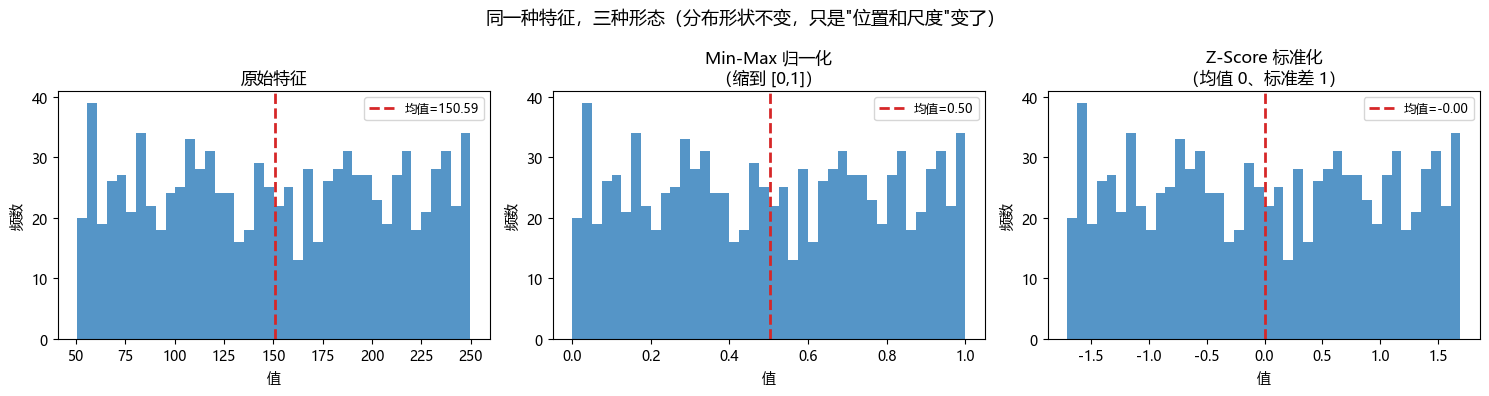

In [26]:
# ---- 特征缩放：原始 vs Min-Max vs Z-Score ----
# 造一个"面积"特征，看三种分布（原始/归一化/标准化）的样子。
np.random.seed(30)
面积_raw = np.random.rand(1000) * 200 + 50        # 面积：50 ~ 250 之间

面积_minmax = (面积_raw - 面积_raw.min()) / (面积_raw.max() - 面积_raw.min())
面积_zs     = (面积_raw - 面积_raw.mean()) / 面积_raw.std()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, t in zip(axes, [面积_raw, 面积_minmax, 面积_zs],
                       ['原始特征', 'Min-Max 归一化\n（缩到 [0,1]）', 'Z-Score 标准化\n（均值 0、标准差 1）']):
    ax.hist(data, bins=40, color=蓝, alpha=0.8)
    ax.set_title(t)
    ax.set_xlabel('值'); ax.set_ylabel('频数')
    ax.axvline(data.mean(), color=红, lw=2, ls='--', label=f'均值={data.mean():.2f}')
    ax.legend(fontsize=9)
plt.suptitle('同一种特征，三种形态（分布形状不变，只是"位置和尺度"变了）', fontsize=13)
plt.tight_layout()
plt.show()

# 注意：Z-Score 后均值是 0、标准差是 1；Min-Max 后落在 [0,1]。
# 两者都不改变分布的"形状"（偏斜还是偏斜），只改变位置和尺度。


## 7.3 类别特征的编码：把「文字类别」变成数字

模型只能吃**数字**，但真实数据常有**类别型（categorical）**特征，比如「颜色：红/蓝/绿」「城市：北京/上海」。怎么把文字变成数字？有两种常见方式，选错会出大问题。

### 方式一：标签编码（Label Encoding）

直接把每个类别映射成一个整数：红→0、蓝→1、绿→2。

**问题**：这样会**凭空引入「大小关系」和「距离」**——模型会以为「绿(2) > 蓝(1) > 红(0)」，还会以为「红和绿差 2、红和蓝差 1」。但「红、蓝、绿」之间本来没有这种关系，这是**虚假信息**，可能误导模型。所以标签编码**只适合「有顺序」的类别**（如「小/中/大」「低/中/高」）。

### 方式二：独热编码（One-Hot Encoding）⭐ 最常用

把「一个类别特征」拆成「若干个 0/1 特征」。比如「颜色」有 3 个取值，就拆成 3 列：

| 颜色 | 红 | 蓝 | 绿 |
| --- | --- | --- | --- |
| 红 | 1 | 0 | 0 |
| 蓝 | 0 | 1 | 0 |
| 绿 | 0 | 0 | 1 |

每个样本在「它属于的那个类别」列上是 1，其余全是 0。这样：

- 不引入任何虚假的大小/距离关系；
- 缺点是**类别很多时，特征维度暴涨**（比如「城市」有 100 个取值就变 100 列），所以类别极多时要用别的技巧（如 embedding，第十九章会提到）。

> 🔑 **记忆**：**无序类别用 one-hot，有序类别可用 label encoding**；最常用、最稳妥的是 one-hot。


In [27]:
# ---- 类别特征编码：标签编码 vs 独热编码 ----
import pandas as pd

# 造一个带类别特征的小表格
df = pd.DataFrame({
    '城市': ['北京', '上海', '广州', '上海', '北京'],
    '面积': [80, 100, 90, 110, 70],
})

print("原始数据：")
print(df, "\n")

# ① 标签编码（直接映射成整数）
df['城市_标签编码'] = df['城市'].astype('category').cat.codes
print("标签编码后（注意：引入了 0<1<2 的虚假大小关系）：")
print(df[['城市', '城市_标签编码']], "\n")

# ② 独热编码（pandas 的 get_dummies）
df_onehot = pd.get_dummies(df, columns=['城市'], prefix='城市')
print("独热编码后（每个类别一列 0/1，无虚假大小关系）：")
print(df_onehot)


原始数据：
   城市   面积
0  北京   80
1  上海  100
2  广州   90
3  上海  110
4  北京   70 

标签编码后（注意：引入了 0<1<2 的虚假大小关系）：
   城市  城市_标签编码
0  北京        1
1  上海        0
2  广州        2
3  上海        0
4  北京        1 

独热编码后（每个类别一列 0/1，无虚假大小关系）：
    面积  城市_标签编码  城市_上海  城市_北京  城市_广州
0   80        1  False   True  False
1  100        0   True  False  False
2   90        2  False  False   True
3  110        0   True  False  False
4   70        1  False   True  False


## 7.4 缺失值的处理：数据里的「窟窿」怎么办

真实数据经常有缺失值（NaN）。处理前先问一句：**为什么会缺？** 原因不同，处理方式也不同。常见处理策略：

- **删除**：如果缺失很少（比如 1% 都不到），直接把缺值的行删掉最省事；但如果缺很多，删掉会损失大量数据；
- **填充（imputation）**：用某个值补上，比如：
  - 数值特征：填**均值**、**中位数**（对离群点更稳健）；
  - 类别特征：填**众数**（出现最多的类别）；
  - 时间序列：**前向填充**（用上一个时间点的值）。

> 💡 缺失值处理没有「万能答案」，要结合业务含义。比如「收入」缺失，可能意味着「无收入」而非「随机漏填」，直接填均值反而引入错误。


In [28]:
# ---- 缺失值处理演示 ----
df2 = pd.DataFrame({
    '面积': [80, 100, np.nan, 110, 90],
    '楼层': [3, np.nan, 7, 12, 5],
})
print("含缺失值的数据：")
print(df2, "\n")

# ① 用均值填充
df2_均值 = df2.fillna(df2.mean())
print("用均值填充：")
print(df2_均值, "\n")

# ② 用中位数填充
df2_中位数 = df2.fillna(df2.median())
print("用中位数填充（对离群点更稳健）：")
print(df2_中位数, "\n")

# ③ 直接删除含缺失值的行
print("删除含缺失值的行：")
print(df2.dropna())


含缺失值的数据：
      面积    楼层
0   80.0   3.0
1  100.0   NaN
2    NaN   7.0
3  110.0  12.0
4   90.0   5.0 

用均值填充：
      面积     楼层
0   80.0   3.00
1  100.0   6.75
2   95.0   7.00
3  110.0  12.00
4   90.0   5.00 

用中位数填充（对离群点更稳健）：
      面积    楼层
0   80.0   3.0
1  100.0   6.0
2   95.0   7.0
3  110.0  12.0
4   90.0   5.0 

删除含缺失值的行：
      面积    楼层
0   80.0   3.0
3  110.0  12.0
4   90.0   5.0


## 7.5 特征组合：让模型能表达「交互关系」

有些规律，**单个特征表达不了，必须靠特征之间的「组合」**。

经典例子：预测房价时，「面积大」和「地段好」单独看都影响价格，但它们的**组合**（市中心的大面积房）可能价值远高于「面积大」+「地段好」的简单相加——这是一种**交互效应**。如果只用线性模型 $y = w_1x_1 + w_2x_2 + b$，它只能表达「加法」，表达不了「$x_1$ 和 $x_2$ 相乘」的交互。

**特征组合（feature crossing）** 就是人为构造新特征来捕捉这种交互，最常用的是：

- **多项式特征**：$x_1, x_2 \to x_1, x_2, x_1^2, x_2^2, x_1x_2$；
- **交叉特征**：把两个类别特征「相乘」组合成一个新特征（如「性别 × 年龄段」）。

> 💡 注意：特征组合会增加特征维度，维度一高又容易过拟合，所以要配合正则化（第八章）一起用。


In [29]:
# ---- 特征组合：多项式特征（捕捉交互） ----
from sklearn.preprocessing import PolynomialFeatures

X9 = np.array([[2, 3], [1, 4], [5, 1]])     # 3 个样本，每个 2 个特征 [x1, x2]
print("原始特征 X：")
print(X9, "\n")

poly = PolynomialFeatures(degree=2, include_bias=False)
X9_poly = poly.fit_transform(X9)
print("2 阶多项式特征（含交互项 x1·x2 和平方项 x1²、x2²）：")
print(X9_poly)
print("\n新特征列：", poly.get_feature_names_out())
# 输出列：[x1, x2, x1², x1·x2, x2²] —— 其中 x1·x2 就是捕捉"交互"的那一项。


原始特征 X：
[[2 3]
 [1 4]
 [5 1]] 

2 阶多项式特征（含交互项 x1·x2 和平方项 x1²、x2²）：
[[ 2.  3.  4.  6.  9.]
 [ 1.  4.  1.  4. 16.]
 [ 5.  1. 25.  5.  1.]]

新特征列： ['x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']


## 7.6 特征选择：不是特征越多越好

特征工程还包含「做减法」——**特征选择（feature selection）**，从一堆特征里挑出真正有用的。

为什么需要它：

- **维度灾难**：特征太多，数据在高维空间变得稀疏，模型难学；
- **过拟合**：无关特征会变成「噪声」，让模型记住假规律；
- **可解释性 / 计算量**：特征越少，模型越简单、跑得越快、越容易解释。

三种常见方法：

- **过滤法（Filter）**：先按「单个特征和目标的相关性」打分（如卡方检验、相关系数、方差），把得分低的滤掉，再训练模型；
- **包裹法（Wrapper）**：把「特征子集的选择」当作一个搜索问题，用模型性能来评价每个子集（如递归特征消除 RFE）；
- **嵌入法（Embedded）**：在训练过程中自动做选择——最典型的是 **L1 正则化（Lasso）**，它能让不重要的特征权重直接变成 0，相当于「自动淘汰」了这些特征（第八章详细讲）。

> 💡 入门阶段重点记住：**L1 正则化（Lasso）自带特征选择能力**，这是它和 L2（Ridge）最重要的区别之一。


## 7.7 【李沐 实用ML】数据获取、EDA 与数据清理

> 📌 **出处**：李沐《实用机器学习》「数据获取、网页数据抓取、数据标注、探索性数据分析、数据清理」
> 📎 **完整可运行代码**：`实战代码_李沐/数据获取与标注.ipynb`、`EDA与数据清理.ipynb`

特征工程之前还有「上游」的**数据获取**和**数据清理**，李沐把它们总结为流水线的起点：

**① 数据获取**（数据从哪来）：

| 途径 | 例子 | 特点 |
| --- | --- | --- |
| 公开数据集 | ImageNet、COCO、Kaggle | 现成干净，首选 |
| API | 天气/股票/社交 API | 结构化 JSON，实时 |
| 网页抓取 | requests + 解析库 | 灵活，注意反爬与版权 |
| 数据库/日志 | 公司 SQL、埋点 | 最真实，但要清洗 |

**② 数据标注**（给数据打标签 y）：人工 / **半自动**（模型预标 + 人工复核低置信样本）/ **主动学习**（模型挑「最不确定」的样本让人标，花最少标注量换最大提升）。

**③ EDA 三板斧**（先摸清数据脾气再建模）：看**分布**（直方图）找异常值；看**相关性**（热力图）找冗余特征；看**缺失与类别占比**决定怎么填。

**④ 数据清理四连**：缺失值（删/填）、异常值（分位数截断）、重复行（`drop_duplicates`）、类型错误（`to_numeric`/`astype`）。

> 💡 这一节和本章 7.4「缺失值处理」前后呼应：7.4 讲具体某个坑怎么填，这里讲**整条数据流水线的上游全景**。


## 7.8 本章小结


# 第八章 过拟合与正则化

> 📌 **出处**：李宏毅 2026《机器学习》**第 41~50 讲**（过拟合和欠拟合正则化、L1/L2 正则化、套索回归 Lasso、岭回归 Ridge、ElasticNet）
> ⭐ **40 天重点**：对应计划 Day11「正则化：L1/L2 正则、Dropout」、Day17「处理过拟合（权重衰减、Dropout）」。这一章把第一章的「正则化直觉」彻底讲透。

---

## 8.1 回顾：过拟合的本质与正则化的思路

第三章讲过：模型太复杂，会把训练数据的**噪声**也背下来，导致「训练误差小、验证误差大」的**过拟合**。参数 $w$ 越大，函数越「敏感」，越容易过拟合。

**正则化（regularization）** 的通用思路是：**给损失函数加一个「惩罚项」（pentalty），限制参数不要太大**：

$$L_{\text{新}} = L_{\text{原}} + \lambda \cdot \text{惩罚项}(w)$$

其中 $\lambda$（lambda，也叫正则化强度/系数）控制惩罚的力度：

- $\lambda$ 越大 → 越强地压制参数 → 模型越「简单」、越不容易过拟合（但太大会变成欠拟合）；
- $\lambda$ 越小 → 越接近原来的损失 → 越容易过拟合。

根据「惩罚项」的形式不同，分成 L1 和 L2 两大类（下一节详解），还有两者混合的 ElasticNet。

> 💡 核心问题只有一个：**惩罚项用 $w$ 的平方还是 $w$ 的绝对值？** 这一个选择，带来了一系列深刻区别。


## 8.2 L2 正则化：岭回归（Ridge）

L2 正则化在损失后面加**所有参数的平方和**：

$$L_{\text{new}} = L_{\text{原}} + \lambda \sum_{i} w_i^2$$

- 加了 L2 的线性回归，专门叫**岭回归（Ridge Regression）**；
- 效果：把**所有参数整体「往 0 收缩」**，但**不会变成 0**（因为平方项对「小参数」的惩罚很轻，参数可以保留一个很小的非零值）；
- 直觉：让每个参数都「克制一点」，避免某个参数特别大导致函数剧烈波动。

### 为什么 L2 让参数变小，却不归零？

看梯度：对 $w_i$ 求导，惩罚项贡献 $\frac{\partial}{\partial w_i}(\lambda w_i^2) = 2\lambda w_i$。更新时相当于每步都**额外把 $w_i$ 按比例削掉一点**（正比于 $w_i$ 当前大小）。$w_i$ 越大被削得越多，越小被削得越少——所以是「按比例收缩」，永远不会一步削到 0（只会无限逼近）。


## 8.3 L1 正则化：套索回归（Lasso）

L1 正则化在损失后面加**所有参数的绝对值之和**：

$$L_{\text{new}} = L_{\text{原}} + \lambda \sum_{i} |w_i|$$

- 加了 L1 的线性回归，叫**套索回归（Lasso Regression）**；
- 效果：不仅能收缩参数，还能让**一部分参数直接变成 0**——得到「稀疏（sparse）」解(\lambda越大，越稀疏)；
- 为什么能归零：对 $w_i$ 求导，惩罚项贡献 $\frac{\partial}{\partial w_i}(\lambda |w_i|) = \lambda \cdot \text{sign}(w_i)$。更新时是**每次减一个固定量**（不随 $w_i$ 变小而变小），所以参数会被「一路削到 0」然后停在那里。

### L1 归零 = 自动做特征选择

回想第七章：**让权重变成 0，等价于把这个特征从模型里删掉**。所以 Lasso 在训练的同时，自动完成了**特征选择**——权重变 0 的特征就是「没用」的特征，权重非 0 的才是重要的。这就是 L1 和 L2 最本质的区别。


## 8.4 L1 vs L2：几何直觉（为什么一个归零、一个不归零）

用几何能非常直观地看懂这个区别。把「最小化损失」重新表述成「在参数满足某个约束下，最小化损失」：

- L2 的约束是 $\sum w_i^2 \le C$：在二维里是一个**圆**；
- L1 的约束是 $\sum |w_i| \le C$：在二维里是一个**菱形**（四个尖角朝坐标轴）。

我们的解是「损失等高线」和「约束区域」**第一次相切**的点：

- **L2（圆）**：圆是光滑的，损失等高线通常和圆相切在**非轴**的位置，所以参数一般**非零**；
- **L1（菱形）**：菱形有**尖角**，损失等高线**很容易正好顶在尖角上**，而尖角位于**坐标轴上**（即某个参数 = 0），所以参数**容易为 0**。

> 💡 一句话：**L2 的圆没有尖角，解落在内部（非零）；L1 的菱形有尖角，解容易顶在轴上（归零）。** 下面的代码把这张图直接画出来。


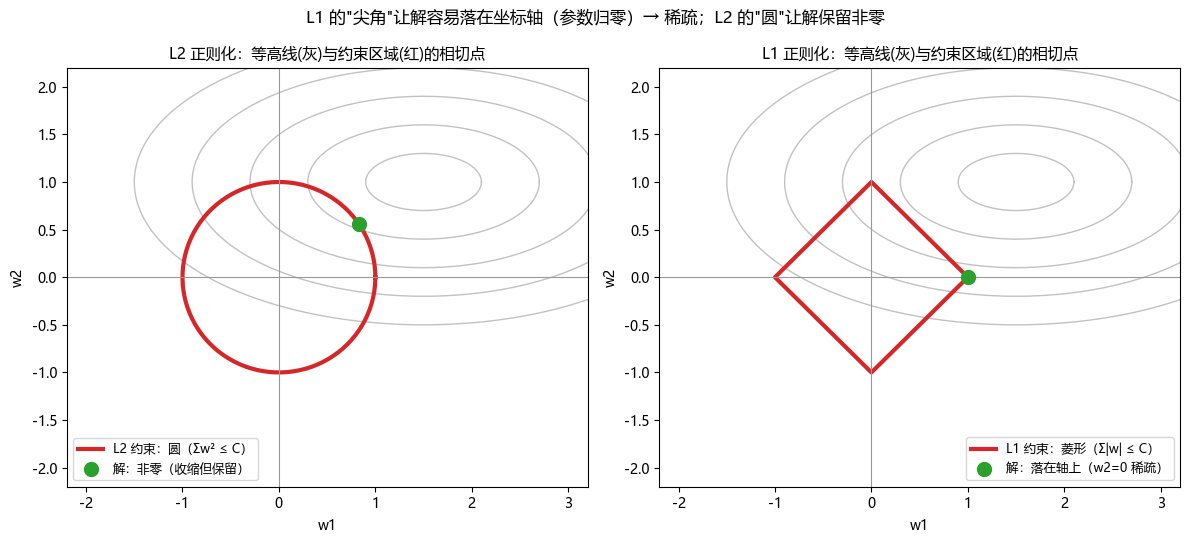

In [30]:
# ---- L1 vs L2 的几何直觉：圆 vs 菱形 ----
# 画出 L2（圆）和 L1（菱形）的约束区域，以及"损失等高线"，
# 观察解（相切点）为什么 L1 容易落在坐标轴上（参数=0）。
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# 假设真实最优解（无约束时）在 (1.5, 1.0) 附近，损失等高线是围绕它的椭圆
theta = np.linspace(0, 2 * np.pi, 200)

for ax, 类型 in zip(axes, ['L2', 'L1']):
    # 画损失等高线（椭圆，中心在 (1.5, 1.0)）
    for r in [0.3, 0.6, 0.9, 1.2, 1.5]:
        ell_x = 1.5 + r * 2 * np.cos(theta)
        ell_y = 1.0 + r * np.sin(theta)
        ax.plot(ell_x, ell_y, color=灰, lw=1, alpha=0.6)
    # 画约束区域边界
    if 类型 == 'L2':
        ax.plot(np.cos(theta), np.sin(theta), color=红, lw=3, label='L2 约束：圆（Σw² ≤ C）')
        ax.scatter([0.83], [0.56], color=绿, s=100, zorder=5, label='解：非零（收缩但保留）')
    else:
        菱形x = np.concatenate([[1, 0, -1, 0, 1]]); 菱形y = np.concatenate([[0, 1, 0, -1, 0]])
        ax.plot(菱形x, 菱形y, color=红, lw=3, label='L1 约束：菱形（Σ|w| ≤ C）')
        ax.scatter([1.0], [0.0], color=绿, s=100, zorder=5, label='解：落在轴上（w2=0 稀疏）')
    ax.axhline(0, color=灰, lw=0.8); ax.axvline(0, color=灰, lw=0.8)
    ax.set_xlim(-2.2, 3.2); ax.set_ylim(-2.2, 2.2)
    ax.set_xlabel('w1'); ax.set_ylabel('w2')
    ax.set_title(f'{类型} 正则化：等高线(灰)与约束区域(红)的相切点', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('L1 的"尖角"让解容易落在坐标轴（参数归零）→ 稀疏；L2 的"圆"让解保留非零', fontsize=12)
plt.tight_layout()
plt.show()


## 8.5 ElasticNet：L1 + L2 的折中

**ElasticNet（弹性网络）** 同时加 L1 和 L2 两个惩罚项：

$$L_{\text{new}} = L_{\text{原}} + \lambda_1 \sum_i |w_i| + \lambda_2 \sum_i w_i^2$$

- 好处：兼顾 L1 的「稀疏」和 L2 的「稳定收缩」；
- 什么时候用：当特征很多、且特征之间有**相关性**时，纯 Lasso 可能随机地只保留其中一个相关特征（不稳定），而 ElasticNet 能更稳健地处理这种情况。

> 💡 实用建议：**Ridge（L2）是默认首选**（稳定、好调）；需要做特征选择时用 **Lasso（L1）**；特征多且相关时用 **ElasticNet**。


D:\Anaconda\envs\study\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.471e-02, tolerance: 1.462e-03
  model = cd_fast.enet_coordinate_descent(


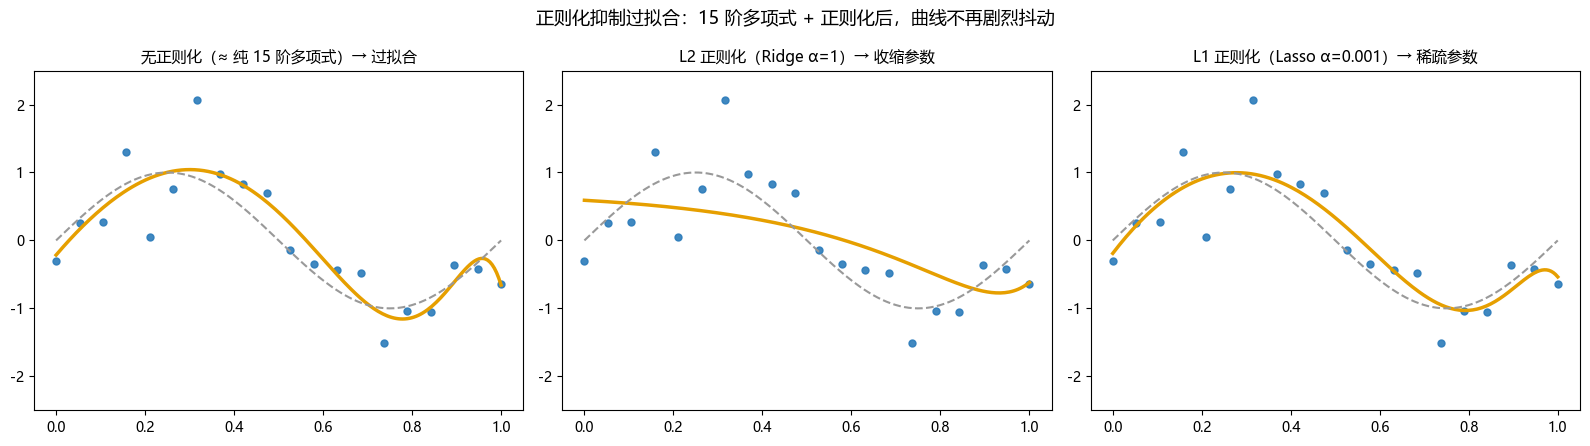

In [31]:
# ---- L1 / L2 / ElasticNet 正则化效果对比（抑制过拟合） ----
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(40)
xr = np.linspace(0, 1, 20)
yr = np.sin(2 * np.pi * xr) + np.random.randn(20) * 0.5
xs = np.linspace(0, 1, 200)

def 画(ax, 模型, t):
    模型.fit(xr.reshape(-1, 1), yr)
    ax.scatter(xr, yr, color=蓝, s=25, alpha=0.9, label='数据（含噪声）')
    ax.plot(xs, 模型.predict(xs.reshape(-1, 1)), color=橙, lw=2.5, label='拟合曲线')
    ax.plot(xs, np.sin(2 * np.pi * xs), color=灰, lw=1.5, ls='--', label='真实函数')
    ax.set_title(t, fontsize=11)
    ax.set_ylim(-2.5, 2.5)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# 都用 15 阶多项式（本身很容易过拟合），对比加不同正则化的效果
画(axes[0], make_pipeline(PolynomialFeatures(15), Ridge(alpha=0.001)), '无正则化（≈ 纯 15 阶多项式）→ 过拟合')
画(axes[1], make_pipeline(PolynomialFeatures(15), Ridge(alpha=1.0)), 'L2 正则化（Ridge α=1）→ 收缩参数')
画(axes[2], make_pipeline(PolynomialFeatures(15), Lasso(alpha=0.001)), 'L1 正则化（Lasso α=0.001）→ 稀疏参数')
plt.suptitle('正则化抑制过拟合：15 阶多项式 + 正则化后，曲线不再剧烈抖动', fontsize=13)
plt.tight_layout()
plt.show()

# 观察：左图（几乎无正则）曲线剧烈抖动、贴着每个噪声点 → 过拟合；
# 中图、右图（加正则）曲线变平滑，更贴近真实的正弦波 → 泛化更好。


## 8.6 深度学习的正则化：权重衰减与 Dropout

前面讲的是「线性回归」上的 L1/L2。在**神经网络**里，正则化有专门的叫法和技巧（⭐ 40 天计划 Day17 点名）。

### 权重衰减（Weight Decay）= 深度学习版的 L2

在神经网络里，L2 正则化常被称为**权重衰减（weight decay）**。它做的是同一件事：在损失里加 $\lambda\sum w^2$，让所有权重往 0 收缩，抑制过拟合。PyTorch 里就是给优化器加一个 `weight_decay` 参数（第十六章会看到）。

### Dropout：随机「关掉」一部分神经元

Dropout 是一种非常有效的神经网络正则化技巧：**训练时，每一步随机地把一部分神经元（比如 50%）「临时关掉」（输出置 0），只让剩下的神经元工作**。

为什么有效？直觉上：

- 每次训练都随机「丢弃」不同的一批神经元，相当于**同时训练了很多个「残缺的」小网络**，最后取它们的「平均」——这天然有正则化、抑制过拟合的效果；
- 神经元不能再「依赖」某个特定的同伴（因为同伴随时可能被关掉），被迫自己学到更鲁棒的特征。

> 💡 关键：Dropout 只在**训练时**开启，**测试时**关闭（用完整的网络）。PyTorch 里就是 `nn.Dropout(p)`，$p$ 是丢弃概率（常见 0.5）。


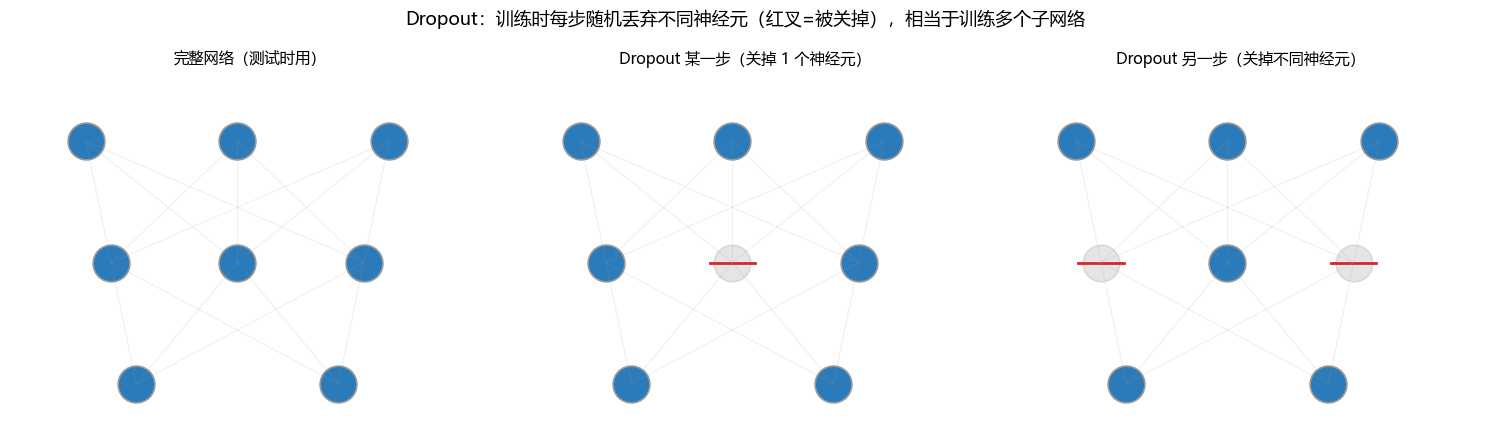

In [32]:
# ---- Dropout 的可视化：随机"关掉"一部分神经元 ----
# 画一个简单的网络，示意 Dropout 训练时的"随机丢弃"效果。
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

def 画网络(ax, 活跃掩码, t):
    # 三层：输入(4) → 隐藏(4) → 输出(2)
    层 = [[0.2, 0.5, 0.8], [0.25, 0.5, 0.75], [0.3, 0.7]]
    for layer_idx, xs_pos in enumerate(层):
        n = len(活跃掩码[layer_idx])
        for j in range(n):
            c = 蓝 if 活跃掩码[layer_idx][j] else 灰
            alpha = 1.0 if 活跃掩码[layer_idx][j] else 0.25
            ax.scatter(xs_pos[j], 0.8 - layer_idx * 0.35, s=700, color=c, alpha=alpha, edgecolors=灰, linewidths=1.2)
            if not 活跃掩码[layer_idx][j]:
                ax.plot([xs_pos[j]-0.045, xs_pos[j]+0.045], [0.8-layer_idx*0.35]*2, color=红, lw=2)
    # 连线
    for i in range(len(层[0])):
        for j in range(len(层[1])):
            ax.plot([层[0][i], 层[1][j]], [0.8, 0.45], color=灰, alpha=0.15, lw=0.8)
    for i in range(len(层[1])):
        for j in range(len(层[2])):
            ax.plot([层[1][i], 层[2][j]], [0.45, 0.1], color=灰, alpha=0.15, lw=0.8)
    ax.set_xlim(0.05, 1.0); ax.set_ylim(-0.05, 1.0); ax.axis('off')
    ax.set_title(t, fontsize=11)

画网络(axes[0], [[1,1,1],[1,1,1],[1,1]], '完整网络（测试时用）')
画网络(axes[1], [[1,1,1],[1,0,1],[1,1]], 'Dropout 某一步（关掉 1 个神经元）')
画网络(axes[2], [[1,1,1],[0,1,0],[1,1]], 'Dropout 另一步（关掉不同神经元）')
plt.suptitle('Dropout：训练时每步随机丢弃不同神经元（红叉=被关掉），相当于训练多个子网络', fontsize=13)
plt.tight_layout()
plt.show()


## 8.7 早停（Early Stopping）：在过拟合发生前停下

**早停**是一种最简单、却非常有效的正则化手段，思路直白：**训练时盯着验证集误差，一旦验证误差开始「回升」（说明要过拟合了），就停止训练**。

- 训练前期：训练误差和验证误差都下降；
- 到了某个点：训练误差继续降，但验证误差开始**拐头向上**——这就是过拟合的信号；
- 早停就是在这个「拐点」附近停下来，用「验证误差最低」的那份模型。

> 💡 早停和「保存最优模型（checkpoint）」是配套的：一边训练一边记录验证误差最低时的模型，最后用它（第十六章会实现这套标准流程）。


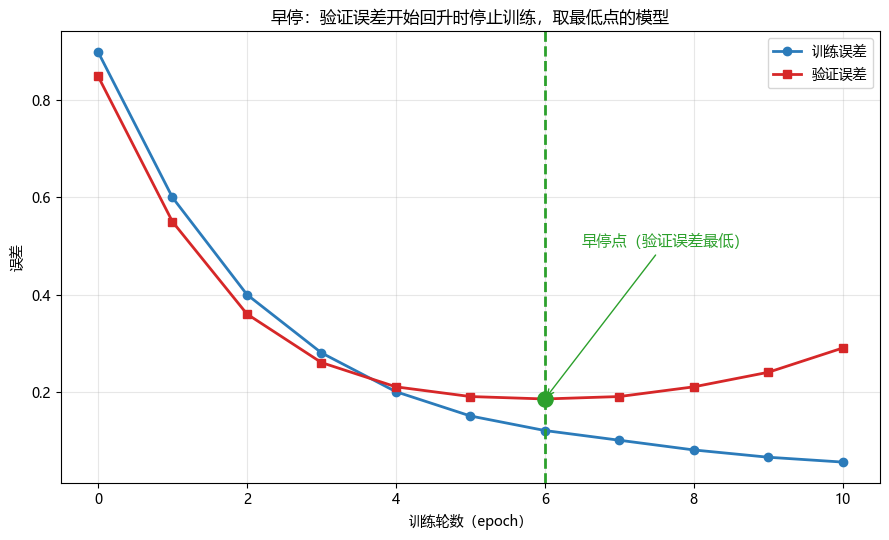

In [33]:
# ---- 早停（Early Stopping）示意 ----
# 模拟"训练误差一路下降、验证误差先降后升"的典型过程，标出早停点。
训练误差 = np.array([0.9, 0.6, 0.4, 0.28, 0.2, 0.15, 0.12, 0.1, 0.08, 0.065, 0.055])
验证误差 = np.array([0.85, 0.55, 0.36, 0.26, 0.21, 0.19, 0.185, 0.19, 0.21, 0.24, 0.29])
轮次 = np.arange(len(训练误差))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(轮次, 训练误差, 'o-', color=蓝, lw=2, label='训练误差')
ax.plot(轮次, 验证误差, 's-', color=红, lw=2, label='验证误差')
最佳 = int(np.argmin(验证误差))
ax.axvline(最佳, color=绿, ls='--', lw=2)
ax.scatter([最佳], [验证误差[最佳]], color=绿, s=120, zorder=5)
ax.annotate('早停点（验证误差最低）', xy=(最佳, 验证误差[最佳]), xytext=(最佳+0.5, 0.5),
            arrowprops=dict(arrowstyle='->', color=绿), fontsize=11, color=绿)
ax.set_xlabel('训练轮数（epoch）'); ax.set_ylabel('误差')
ax.set_title('早停：验证误差开始回升时停止训练，取最低点的模型')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 看图：绿虚线右侧，训练误差还在降（模型还在"背"），但验证误差已经抬头（过拟合开始），
# 所以应该在绿虚线处停下来。


## 8.8 【李沐 d2l】权重衰减与 Dropout 的 PyTorch 实现

> 📌 **出处**：李沐《动手学深度学习 V2》第 4 章「权重衰减 / 暂退法」
> 📎 **完整可运行代码**：`实战代码_李沐/权重衰减与Dropout.ipynb`

8.6 节讲了概念，这里给出 d2l 的两行落地写法：

**权重衰减（L2）**：在损失里加 `λ·‖w‖²/2`

```python
l = loss(net(X), y) + lambd * (w ** 2).sum() / 2    # 从零：手动加 L2 惩罚
trainer = optim.SGD(..., weight_decay=lambd)         # 简洁：optim 自带 weight_decay
```

**Dropout**：训练时随机置零一部分激活，并除以 `1-p` 补偿幅度

```python
def dropout_layer(X, p):
    mask = (torch.rand(X.shape) > p).float()
    return mask * X / (1.0 - p)        # 除以 1-p 保持期望不变

net = nn.Sequential(..., nn.Dropout(0.5))   # 简洁：nn.Dropout 一行
```

> 🔑 **记忆**：
> - 权重衰减作用于**参数**（逼权重变小），Dropout 作用于**激活值**（逼不依赖单个神经元）；
> - Dropout **只在训练时用**：`model.train()` 开、`model.eval()` 关；
> - 实验结论：特征多、样本少时（如 200 特征、20 样本），权重衰减能把过拟合的测试损失大幅拉回来。


## 8.9 本章小结

| 方法 | 惩罚项 | 效果 | 别名 |
| --- | --- | --- | --- |
| L2 正则化 | $\lambda\sum w_i^2$ | 参数整体收缩，不归零 | Ridge（岭回归）、权重衰减 |
| L1 正则化 | $\lambda\sum |w_i|$ | 部分参数归零（稀疏） | Lasso（套索回归） |
| ElasticNet | 两者混合 | 稀疏 + 稳定 | 弹性网络 |
| Dropout | —— | 随机丢弃神经元 | 神经网络专用 |
| 早停 | —— | 验证误差回升就停 | —— |

🔑 **记忆**：L2 收缩不归零（Ridge）、L1 归零做特征选择（Lasso）；正则化强度 $\lambda$ 越大模型越简单；Dropout 训练开、测试关。

> 📌 **下一步**：第九章讲**逻辑回归**——从「输出数值」的回归，转向「输出类别概率」的分类，并引出 softmax 和交叉熵。


# 第九章 逻辑回归

> 📌 **出处**：李宏毅 2026《机器学习》**分类与逻辑回归**专题（Sigmoid、决策边界、交叉熵 Cross Entropy、逻辑回归与线性回归、softmax、分类问题的损失函数）
> ⭐ **40 天重点**：对应计划 Day16「逻辑回归 + 第一个模型」。逻辑回归是**分类任务的入门模型**，它名字里有「回归」，做的却是**分类**——这一章讲清楚它为什么叫这个名字、以及背后的核心思想。

---

## 9.1 从「预测数值」到「预测类别」

前面几章都在做**回归**：输出一个连续数值（如房价 500 万）。但很多问题要的是**分类（classification）**：输出一个**类别**，比如「这封邮件是不是垃圾邮件？」「这张图是猫还是狗？」「明天会不会下雨？」

最直观的想法：能不能还用线性回归，让它输出一个数，再根据这个数判断类别？比如输出 $z = w x + b$，然后规定「$z > 0.5$ 算正类，$z < 0.5$ 算负类」？

这个想法**有个严重问题**：线性回归的输出是**无界的**（可以从 $-\infty$ 到 $+\infty$），而「概率」应该被限制在 $[0, 1]$ 之间。而且直接拿「距离 0.5 多远」当作置信度，在数学上很不舒服。

**逻辑回归的解决办法**：在线性输出的外面，**套一个把任意实数「压」到 $[0,1]$ 的函数**，让输出变成「属于正类的概率」。这个函数就是 **sigmoid**。


## 9.2 Sigmoid 函数：把任意实数压成 [0,1] 的概率

Sigmoid 函数（也叫逻辑函数 logistic function）的定义：

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

它的图像是一条 **S 形曲线**：

- 当 $z \to +\infty$，$\sigma(z) \to 1$；
- 当 $z \to -\infty$，$\sigma(z) \to 0$；
- 当 $z = 0$，$\sigma(0) = 0.5$。

于是**逻辑回归**把线性回归的输出 $z = w x + b$ 送进 sigmoid，得到「概率」：

$$\hat y = \sigma(w x + b) = \frac{1}{1 + e^{-(w x + b)}}$$

这个 $\hat y$ 就解释为「样本属于正类（$y=1$）的概率」。

> 💡 **为什么叫「逻辑回归」？** 因为它内部用了 sigmoid（逻辑）函数做非线性变换，但核心仍是「线性回归 + 一个非线性映射」。它本质是一个**分类器**，却继承了「回归」的名字——这是历史原因，别被名字骗了。


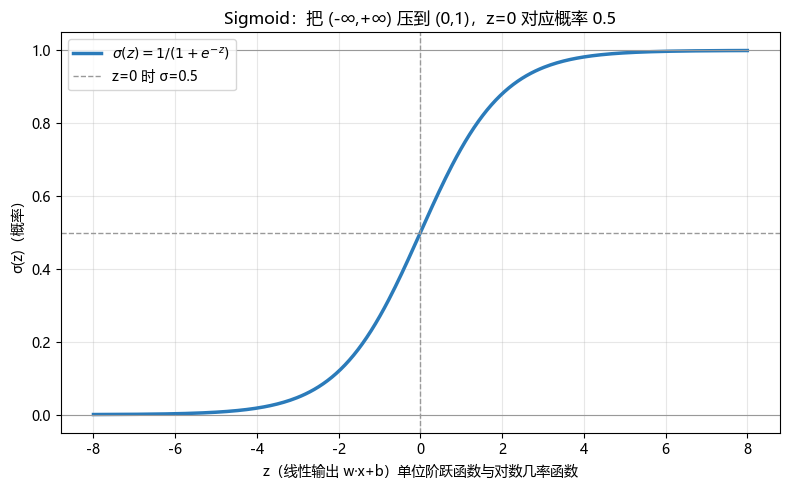

In [34]:
# ---- Sigmoid 函数可视化：S 形曲线 ----
z = np.linspace(-8, 8, 300)
sig = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, sig, color=蓝, lw=2.5, label=r'$\sigma(z) = 1/(1+e^{-z})$')
ax.axhline(0.5, color=灰, ls='--', lw=1, label='z=0 时 σ=0.5')
ax.axvline(0, color=灰, ls='--', lw=1)
ax.axhline(0, color=灰, lw=0.8); ax.axhline(1, color=灰, lw=0.8)
ax.set_xlabel('z（线性输出 w·x+b）单位阶跃函数与对数几率函数'); ax.set_ylabel('σ(z)（概率）')
ax.set_title('Sigmoid：把 (-∞,+∞) 压到 (0,1)，z=0 对应概率 0.5')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 记忆点：z 越大 → 概率越接近 1；z 越小 → 概率越接近 0；z=0 → 正好 0.5。


## 9.3 决策边界：模型在哪里「划线」分类

有了概率 $\hat y$，怎么判断类别？通常规定：

$$\text{预测类别（二分类）} = \begin{cases} 1\ (\text{正类}) & \text{若}\ \hat y \ge 0.5 \\ 0\ (\text{负类}) & \text{若}\ \hat y < 0.5 \end{cases}$$

由于 $\sigma(z) = 0.5$ 当且仅当 $z = 0$，所以「判断为正类」等价于：

$$\hat y \ge 0.5 \iff z = w x + b \ge 0$$

这条 $w x + b = 0$ 就是**决策边界（decision boundary）**——模型在这条线（或面）的两侧分别预测不同类别。

- **一维特征**：决策边界是一个**点**（$x = -b/w$）；
- **二维特征**：决策边界是一条**直线**（$w_1 x_1 + w_2 x_2 + b = 0$）；
- **高维特征**：决策边界是一个**超平面**。

> 💡 注意：**逻辑回归只能画「直线」决策边界**（线性分类器）。这是它的局限——遇到「一个圈套一个圈」这种非线性分布的数据就无能为力，需要特征组合（第七章）或神经网络（第十一章）来画「曲线」边界。


学到的参数：w1=1.503, w2=1.629, b=0.231
决策边界：1.50·x1 + 1.63·x2 + 0.23 = 0


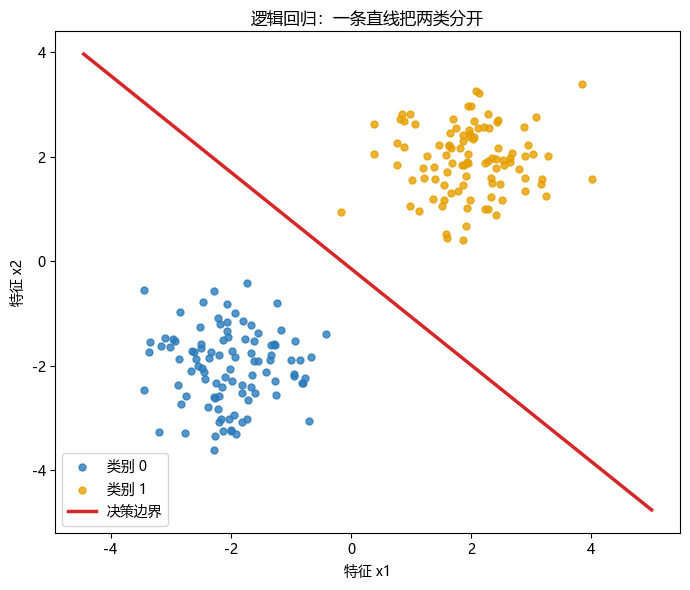

In [35]:
# ---- 逻辑回归的决策边界可视化 ----
# 造一个线性可分的数据，训练逻辑回归，画出它的决策边界。
from sklearn.linear_model import LogisticRegression

np.random.seed(7)
n = 100
# 两类数据：一类在左上、一类在右下
X0 = np.random.randn(n, 2) * 0.7 + np.array([-2, -2])
X1 = np.random.randn(n, 2) * 0.7 + np.array([2, 2])
Xc = np.vstack([X0, X1])
yc = np.array([0] * n + [1] * n)

model = LogisticRegression()
model.fit(Xc, yc)

w1, w2 = model.coef_[0]
b = model.intercept_[0]
print(f"学到的参数：w1={w1:.3f}, w2={w2:.3f}, b={b:.3f}")
print(f"决策边界：{w1:.2f}·x1 + {w2:.2f}·x2 + {b:.2f} = 0")

# 画数据和决策边界（直线 w1·x1 + w2·x2 + b = 0）
xx = np.linspace(Xc[:, 0].min() - 1, Xc[:, 0].max() + 1, 100)
边界y = -(w1 * xx + b) / w2        # 由 w1·x + w2·y + b = 0 解出 y

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X0[:, 0], X0[:, 1], color=蓝, s=25, alpha=0.8, label='类别 0')
ax.scatter(X1[:, 0], X1[:, 1], color=橙, s=25, alpha=0.8, label='类别 1')
ax.plot(xx, 边界y, color=红, lw=2.5, label='决策边界')
ax.set_xlabel('特征 x1'); ax.set_ylabel('特征 x2')
ax.set_title('逻辑回归：一条直线把两类分开')
ax.legend()
plt.tight_layout()
plt.show()

# 记忆点：决策边界就是 z = w·x + b = 0 那条线，两侧分别预测不同类别。

## Sigmoid 损失函数推导

### 1. Sigmoid 函数

$$\sigma(z) = \frac{1}{1+e^{-z}}, \quad z = w^T x$$

### 2. 概率表示

$$\hat{y} = \sigma(w^T x) = P(y=1|x)$$

$$P(y|x) = \hat{y}^y \cdot (1-\hat{y})^{1-y}$$

### 3. 似然 → 损失

**极大似然 → 最小化负对数：**

$$L = -\log P(y|x) = -\left[y\log\hat{y} + (1-y)\log(1-\hat{y})\right]$$

这就是**二元交叉熵损失（Cross-Entropy Loss）**。

### 4. 梯度推导

关键导数：$\frac{d\sigma}{dz} = \sigma(1-\sigma)$

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot x$$

其中：

$$\frac{\partial L}{\partial z} = \hat{y} - y$$

所以：

$$\boxed{\frac{\partial L}{\partial w} = (\hat{y} - y) \cdot x}$$

### 5. 梯度更新

$$w := w - \alpha(\hat{y} - y)x$$

---

## 9.4 交叉熵损失：为什么逻辑回归不用 MSE

现在要训练逻辑回归，用哪个损失函数？先看看「如果硬用 MSE 会怎样」。

### 为什么 MSE 不合适

预测值是概率 $\hat y \in (0,1)$，真实标签 $y \in \{0, 1\}$。用 MSE $=\frac{1}{m}\sum(\hat y - y)^2$：

- 数学上会导致**非凸**的损失曲面（出现很多局部最小），梯度下降难收敛；
- 而且当预测「错得很离谱」（比如真实是 1 却预测接近 0）时，MSE 给出的梯度**反而很小**（因为 sigmoid 两端很平），模型「错得越狠越学不动」——这非常不合理。

### 交叉熵（Cross Entropy）：分类任务的标准损失

交叉熵损失（二元分类）的定义：

$$L = -\frac{1}{m}\sum_{i=1}^{m}\Big[\, y_i \log \hat y_i + (1 - y_i)\log(1 - \hat y_i)\Big]$$

逐项看它的妙处：

- 当真实 $y_i = 1$ 时，只剩 $-\log \hat y_i$ 这一项。若预测 $\hat y_i$ 接近 1，$-\log \hat y_i$ 接近 0（惩罚小）；若预测接近 0，$-\log \hat y_i$ 冲向 $+\infty$（惩罚极大）——**错得越狠，惩罚越狠**；
- 当真实 $y_i = 0$ 时，只剩 $-\log(1 - \hat y_i)$，道理对称；
- 它天然和「概率」配合：我们想让「真实类别的预测概率」尽可能大，等价于让「负对数概率」尽可能小。

> 🔑 **记忆**：**分类任务用交叉熵，回归任务用 MSE**。交叉熵对「自信地犯错」惩罚极重，这正是我们想要的。下面代码对比两者的梯度行为。


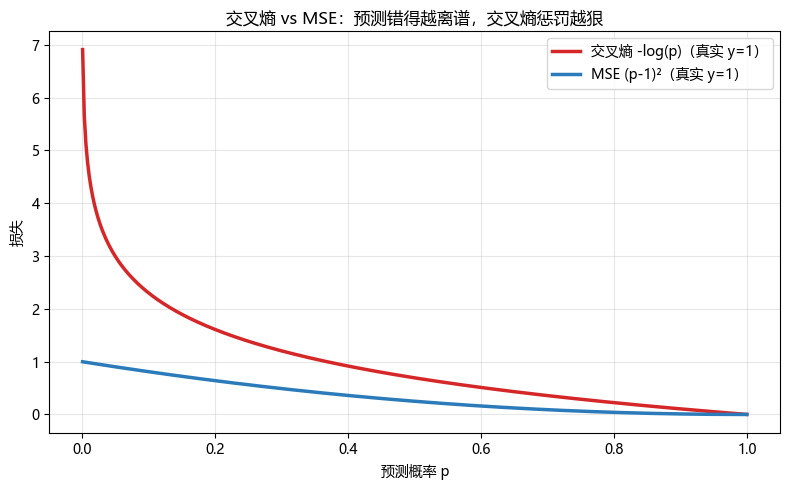

In [37]:
# ---- 交叉熵 vs MSE：为什么分类要用交叉熵 ----
# 对比两种损失函数随"预测概率"变化的曲线（假设真实标签 y=1）。
p = np.linspace(0.001, 0.999, 400)      # 预测概率（避开 log(0)）

# 真实 y=1 时：
#   交叉熵 = -log(p)
#   MSE    = (p - 1)^2
交叉熵 = -np.log(p)
MSE损失 = (p - 1) ** 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, 交叉熵, color=红, lw=2.5, label='交叉熵 -log(p)（真实 y=1）')
ax.plot(p, MSE损失, color=蓝, lw=2.5, label='MSE (p-1)²（真实 y=1）')
ax.set_xlabel('预测概率 p'); ax.set_ylabel('损失')
ax.set_title('交叉熵 vs MSE：预测错得越离谱，交叉熵惩罚越狠')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 观察：当 p 接近 0（错得很离谱）时，交叉熵冲上去了（惩罚巨大），
# 而 MSE 最多到 1（惩罚封顶）。所以交叉熵能让模型"更卖力地改掉大错误"。


## 9.5 多分类：从二分类到「一对多」与 Softmax

前面只处理**两类**。现实常有多类（猫/狗/鸟/鱼）。有两种主流扩展方式。

### 方式一：一对多 OVR（One-vs-Rest）

把「K 类」拆成 **K 个二分类问题**：第 $k$ 个分类器回答「是不是第 $k$ 类？」，把「第 k 类」当正类、其余全当负类。预测时跑 K 个分类器，取**概率最高**的那个类。

- 优点：思路简单、可直接复用二分类逻辑回归；
- 缺点：K 类就要训练 K 个模型，且每个模型看到的「负类」都很多，数据不平衡。

### 方式二：Softmax 回归（多分类的标准做法）

Softmax 直接把一个「K 维的原始分数向量」转成「K 个类别的概率分布」，且**所有概率加起来 = 1**：

$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

- 先对每个分数取指数 $e^{z_k}$（把负数变正、拉开差距）；
- 再除以所有指数之和，做**归一化**，保证和为 1；
- 得到的每个值就是「属于第 $k$ 类的概率」。

配合 softmax 的损失是**多分类交叉熵**：$L = -\sum_k y_k \log \hat y_k$（其中 $y_k$ 是 one-hot 真实标签）。

> 💡 **softmax 与 sigmoid 的关系**：二分类的 softmax 实际上退化成 sigmoid。所以可以理解为：**sigmoid 是 softmax 在「两类」时的特例**。


原始分数（logits）： [2.  1.  0.1 3. ]
softmax 后概率：   [0.2361 0.0869 0.0353 0.6418]
概率之和 = 1.0 （一定等于 1）


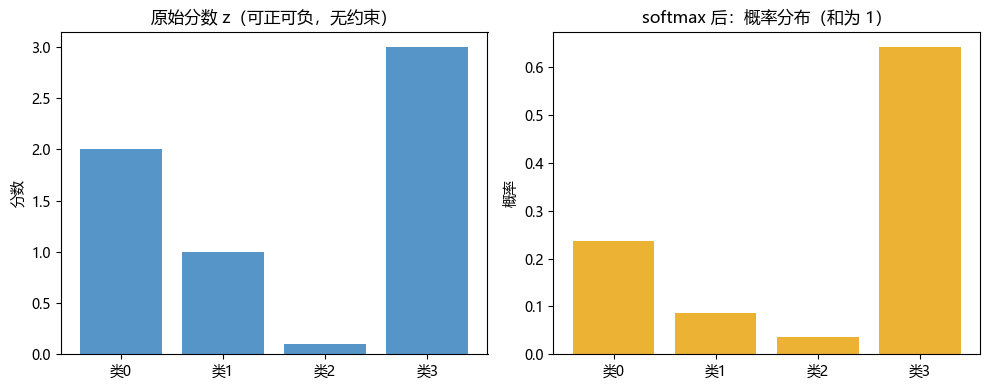

In [38]:
# ---- Softmax 演示：把任意分数变成"和为 1 的概率分布" ----
def softmax(z):
    e = np.exp(z - np.max(z))       # 减去最大值，防止数值溢出（结果不变）；exp是计算e的x次方
    return e / e.sum()

分数 = np.array([2.0, 1.0, 0.1, 3.0])
概率 = softmax(分数)

print("原始分数（logits）：", 分数)
print("softmax 后概率：  ", np.round(概率, 4))
print("概率之和 =", 概率.sum(), "（一定等于 1）")

# 可视化：分数 → 概率
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['类0', '类1', '类2', '类3'], 分数, color=蓝, alpha=0.8)
axes[0].set_title('原始分数 z（可正可负，无约束）')
axes[0].set_ylabel('分数')
axes[1].bar(['类0', '类1', '类2', '类3'], 概率, color=橙, alpha=0.8)
axes[1].set_title('softmax 后：概率分布（和为 1）')
axes[1].set_ylabel('概率')
plt.tight_layout()
plt.show()

# 记忆点：softmax 让"最大的分数"变成"最高的概率"，且所有概率归一化到 1。


## 9.6 sklearn 实战：LogisticRegression 多分类

sklearn 里 `LogisticRegression` 一行搞定，多分类默认用 OVR 或 multinomial（softmax），通过 `multi_class` 参数控制：

- `multi_class='ovr'`：一对多；
- `multi_class='multinomial'`：softmax 回归（真正的多分类）；
- 默认 `multi_class='auto'` 会自动根据数据选择。

训练后和线性回归一样有 `.coef_`、`.intercept_`，但注意**多分类时** `.coef_` 形状是 `(类别数, 特征数)`——每个类有一组权重。


多分类模型的 coef_ 形状： (3, 2) （3 个类 × 2 个特征）
训练集准确率： 0.9133333333333333


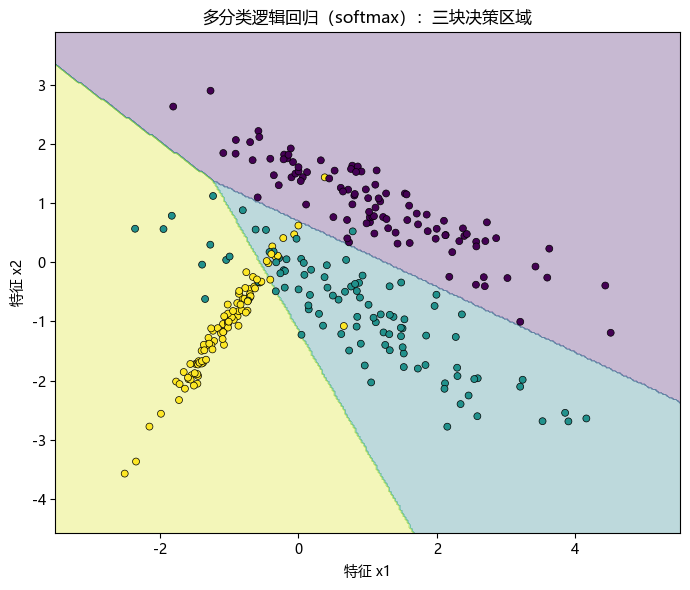

In [57]:
import warnings
warnings.filterwarnings('ignore')

# ---- sklearn 多分类逻辑回归 ----
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# 造一个 3 类、2 特征的分类数据（便于画图）
Xm, ym = make_classification(n_samples=300, n_features=2, n_informative=2,
                             n_redundant=0, n_classes=3, n_clusters_per_class=1,
                             random_state=3)

model = LogisticRegression(multi_class='multinomial', max_iter=1000)
model.fit(Xm, ym)

print("多分类模型的 coef_ 形状：", model.coef_.shape, "（3 个类 × 2 个特征）")
print("训练集准确率：", model.score(Xm, ym))

# 画决策边界（用网格染色）
xx = np.linspace(Xm[:, 0].min() - 1, Xm[:, 0].max() + 1, 300)
yy = np.linspace(Xm[:, 1].min() - 1, Xm[:, 1].max() + 1, 300)
XX, YY = np.meshgrid(xx, yy)
ZZ = model.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(XX, YY, ZZ, alpha=0.3, cmap='viridis')
ax.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap='viridis', s=25, edgecolors='k', linewidths=0.5)
ax.set_xlabel('特征 x1'); ax.set_ylabel('特征 x2')
ax.set_title('多分类逻辑回归（softmax）：三块决策区域')
plt.tight_layout()
plt.show()

# 观察：三种颜色=三个类，背景色块=模型预测的类别区域，边界就是决策边界。


## 9.7 【李沐 d2l】softmax 回归的从零实现：多分类的标准套路

> 📌 **出处**：李沐《动手学深度学习 V2》第 3 章「softmax 回归的从零开始实现」
> 📎 **完整可运行代码**：`实战代码_李沐/softmax回归-从零实现.ipynb`

9.5 节的 softmax 在这里被写成**完整的多分类模型**，数据集是 Fashion-MNIST（10 类服装图片，每张 28×28 展平成 784 维）。核心是把公式落到代码：

```python
def softmax(X):
    X_exp = torch.exp(X - X.max(dim=1, keepdim=True).values)  # 减最大值防溢出
    return X_exp / X_exp.sum(dim=1, keepdim=True)

def net(X):                          # 展平 784 维 → 线性变换 → softmax
    return softmax(X.reshape(-1, W.shape[0]) @ W + b)

def cross_entropy(y_hat, y):         # 交叉熵：只取真实类别对应的概率
    return -torch.log(y_hat[range(len(y_hat)), y])
```

> 🔑 **记忆**：
> - softmax 输出 **10 个和为 1 的概率**，预测类别 = `argmax` 取最大概率的下标；
> - 交叉熵损失**只对「真实类别」那个概率取 `-log`**，其余类别不参与；
> - 准确率 = 预测类别与真实标签一致的样本占比（`(y_hat.argmax(1) == y).sum() / len(y)`）。


## 9.8 【李沐 d2l】softmax 回归的简洁实现 + CrossEntropyLoss 的坑

> 📌 **出处**：李沐《动手学深度学习 V2》第 3 章「softmax 回归的简洁实现」
> 📎 **完整可运行代码**：`实战代码_李沐/softmax回归-简洁实现.ipynb`

```python
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))  # 模型：注意没有 softmax！
loss = nn.CrossEntropyLoss()                            # 损失：内部自带 softmax
trainer = torch.optim.SGD(net.parameters(), lr=0.1)
```

> 🔑 **关键坑（务必记住）**：`nn.CrossEntropyLoss` **内部自己会做 softmax**，所以模型的最后一层**不要再写 softmax**，直接输出 10 个**原始分数（logits）**。若多写一层 softmax，等于做了两次，结果会出错。
>
> 💡 另一处细节：`nn.Flatten()` 自动把 28×28 展平成 784 维，省去手写 `reshape`。softmax 回归的默认学习率是 `lr=0.1`（比线性回归的 0.03 大，因为这里损失是交叉熵、量级不同）。


## 9.9 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 逻辑回归 | 线性回归 + sigmoid，输出「属于正类的概率」 |
| sigmoid | $\sigma(z)=1/(1+e^{-z})$，把任意实数压到 [0,1] |
| 决策边界 | $w x + b = 0$ 那条线，两侧预测不同类别（线性） |
| 交叉熵 | 分类标准损失：错得越离谱，惩罚越狠 |
| OVR | 一对多：拆成 K 个二分类 |
| softmax | 多分类：分数 → 和为 1 的概率分布 |

🔑 **记忆**：分类用**交叉熵**（回归用 MSE）；sigmoid 是 softmax 在两类的特例；softmax 输出和为 1 的概率。

> 📌 **下一步**：第十章专门把**损失函数「全家桶」**（MSE/MAE/交叉熵/Hinge）横向对比，从更高的视角统一理解「损失函数」这个贯穿全书的概念。


# 第十章 损失函数全家桶

> 📌 **出处**：李宏毅 2026《机器学习》**损失函数**专题（均方误差 MSE、平均绝对误差 MAE、交叉熵 Cross Entropy、分类问题的损失、Hinge Loss）
> ⭐ **40 天重点**：对应计划 Day11「损失函数」。前面几章已经零散遇到 MSE、交叉熵，这一章把它们**放回同一条线索**上，从「损失函数到底是什么、怎么选」的视角统一梳理。

---

## 10.1 损失函数：模型和优化器之间的「裁判」

回顾训练三步曲：模型 → 损失 → 优化。**损失函数（loss function）** 是中间的「裁判」，它给「模型预测得有多差」打一个分数，优化器再根据这个分数去改参数。

一个损失函数好不好，关键看两点：

1. **能不能正确反映「误差」**：错得越离谱，分数应该越高（惩罚越重）；
2. **好不好优化**：它的梯度（导数）是否稳定、能否引导参数走向更好的解。

不同任务需要不同「裁判」，于是有了下面这些主流损失函数。选择的第一原则很简单：

> 🔑 **回归任务 → MSE / MAE；分类任务 → 交叉熵 / Hinge。** 这是最核心的对应关系，先记住它，再理解每个的细节。

---

## 10.2 MSE（均方误差）：回归任务的老朋友

**均方误差（Mean Squared Error）** 已经用过很多次：

$$L_{\text{MSE}} = \frac{1}{m}\sum_{i=1}^{m}\big(\hat y_i - y_i\big)^2$$

- **优点**：数学性质好（可导、凸、处处光滑），梯度随误差线性增长，方便梯度下降；
- **缺点**：因为用了**平方**，对**离群点（outlier）极度敏感**——一个离群点的误差平方后会被放大得不成比例，把整条拟合线「拽偏」。

### 为什么平方对离群点敏感？

误差 2 的平方是 4，误差 10 的平方是 100——误差扩大 5 倍，惩罚扩大 25 倍。所以模型会「拼命去迁就」那个离群点，牺牲对大多数正常点的拟合。

> 💡 适用场景：数据**噪声符合正态分布、没有明显离群点**时，MSE 是最优选择（它是「正态噪声下最大似然」的自然结果）。


## 10.3 MAE（平均绝对误差）：对离群点更稳健

**平均绝对误差（Mean Absolute Error）** 把平方换成绝对值：

$$L_{\text{MAE}} = \frac{1}{m}\sum_{i=1}^{m}\big|\hat y_i - y_i\big|$$

- **优点**：离群点不会被「平方放大」，模型更**稳健（robust）**，不容易被少数极端值带偏；
- **缺点**：在 $y_i = \hat y_i$ 处**不可导**（绝对值尖点），且梯度是「常数」（不是随误差变大），优化时不如 MSE 平滑。

### 对比：MSE 放大离群点，MAE 一视同仁

误差 10 时，MSE 惩罚 100，MAE 惩罚 10——MSE 对「大误差」惩罚是平方级的，MAE 是线性级的。所以：**有离群点用 MAE，数据干净用 MSE**。


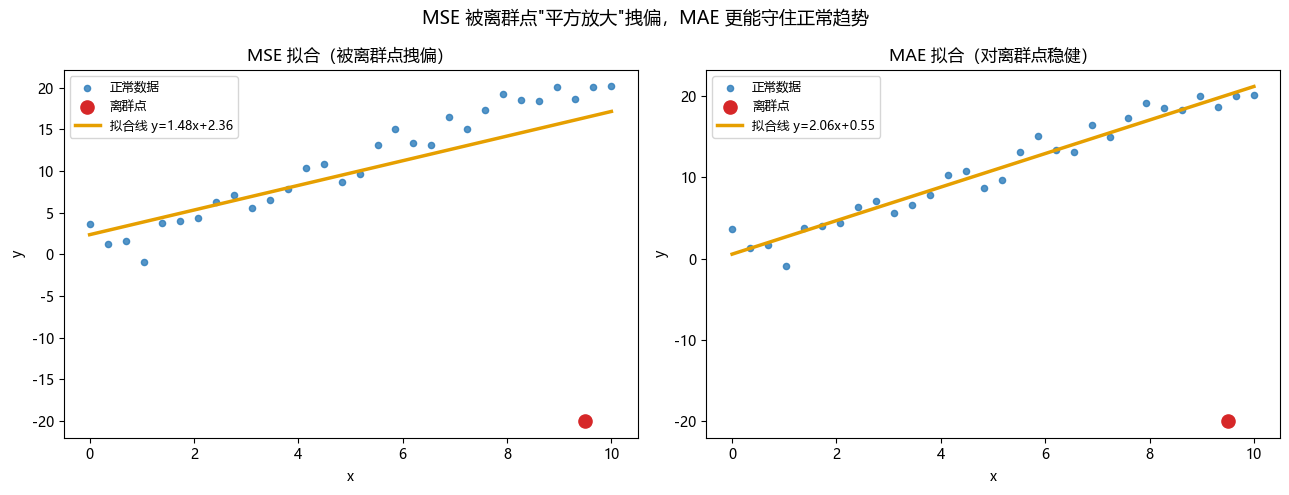

In [40]:
# ---- MSE vs MAE：对离群点的敏感度对比 ----
# 造一条接近直线的数据，故意混入一个离群点，看两种损失拟合的直线差多少。
np.random.seed(11)
Xe = np.linspace(0, 10, 30)
ye = 2 * Xe + 1 + np.random.randn(30) * 1.5
# 混入一个离群点
Xe = np.append(Xe, [9.5]); ye = np.append(ye, [-20])   # 明显偏离正常趋势的点

from sklearn.linear_model import LinearRegression

def 拟合_MAE(Xe, ye, lr=0.01, 步数=2000):
    """用次梯度下降拟合 y = w·x + b，损失用 MAE（|误差|）。"""
    w, b = 0.0, 0.0
    for _ in range(步数):
        残差 = w * Xe + b - ye
        # MAE 在残差=0 处不可导，用次梯度 sign(残差)
        gw = np.mean(np.sign(残差) * Xe)
        gb = np.mean(np.sign(残差))
        w -= lr * gw
        b -= lr * gb
    return w, b

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, 损失, t in zip(axes, ['squared_error', 'absolute_error'],
                       ['MSE 拟合（被离群点拽偏）', 'MAE 拟合（对离群点稳健）']):
    if 损失 == 'squared_error':
        # 默认 LinearRegression 就是最小二乘 = MSE
        m = LinearRegression()
        m.fit(Xe.reshape(-1, 1), ye)
        w, b = m.coef_[0], m.intercept_
    else:
        # 手动用 MAE 损失拟合
        w, b = 拟合_MAE(Xe, ye)
    ax.scatter(Xe[:-1], ye[:-1], color=蓝, s=20, alpha=0.8, label='正常数据')
    ax.scatter([Xe[-1]], [ye[-1]], color=红, s=90, zorder=5, label='离群点')
    xs = np.linspace(0, 10, 50)
    ax.plot(xs, w * xs + b, color=橙, lw=2.5, label=f'拟合线 y={w:.2f}x+{b:.2f}')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(t, fontsize=12)
    ax.legend(fontsize=9)
plt.suptitle('MSE 被离群点"平方放大"拽偏，MAE 更能守住正常趋势', fontsize=13)
plt.tight_layout()
plt.show()

# 观察：左图（MSE）拟合线明显向离群点倾斜；右图（MAE）拟合线更贴近正常数据。


## 10.4 交叉熵（Cross Entropy）：分类任务的标准损失

交叉熵是**分类任务的标准损失**（第九章已细讲）。二分类形式：

$$L = -\frac{1}{m}\sum_{i=1}^{m}\Big[\, y_i \log \hat y_i + (1 - y_i)\log(1 - \hat y_i)\Big]$$

多分类（配合 softmax）形式：

$$L = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y_{ik} \log \hat y_{ik}$$

核心思想：**让「真实类别的预测概率」尽可能大**，等价于让「负对数概率」尽可能小。

> 💡 **为什么交叉熵适合分类、MSE 不适合？** 第九章说过：因为分类的预测是「概率」，交叉熵在「自信地犯错」时惩罚是无穷大（$-\log 0 \to \infty$），能狠狠纠正大错误；而 MSE 配合 sigmoid 会产生非凸曲面、且「错得越狠梯度越小」，反而学不动。所以：**回归用 MSE/MAE，分类用交叉熵**，这是实践中最重要的一条经验。


## 10.5 Hinge Loss（合页损失）：SVM 的损失

**Hinge Loss（合页损失）** 是支持向量机 SVM 的经典损失，专为**二分类（标签 $y \in \{-1, +1\}$）**设计：

$$L_{\text{hinge}} = \max\big(0,\; 1 - y_i \cdot \hat y_i\big)$$

理解它：

- $\hat y_i$ 是模型的「分数」（不是概率），$y_i$ 是真实标签（+1 或 -1）；
- 当预测**正确且足够自信**（$y_i \cdot \hat y_i \ge 1$）时，损失为 0——「已经对了，不再惩罚」；
- 当预测错误，或「对是对了但不够自信」（$y_i \cdot \hat y_i < 1$）时，损失随「不自信程度」线性增长。

和交叉熵的对比：

- 交叉熵：即使已经分对了，只要概率不是 1，就会继续「逼」模型更自信；
- Hinge：分对且过了一个「安全距离」（$y_i\hat y_i \ge 1$）就**撒手不管**（损失 0），只关心「有没有分对、分对得够不够远」，不追求极致概率。

> 💡 这是 SVM「最大间隔」思想的体现：Hinge Loss 鼓励模型把两类数据分得**尽量远**（大间隔），而不是只追求概率接近 1。


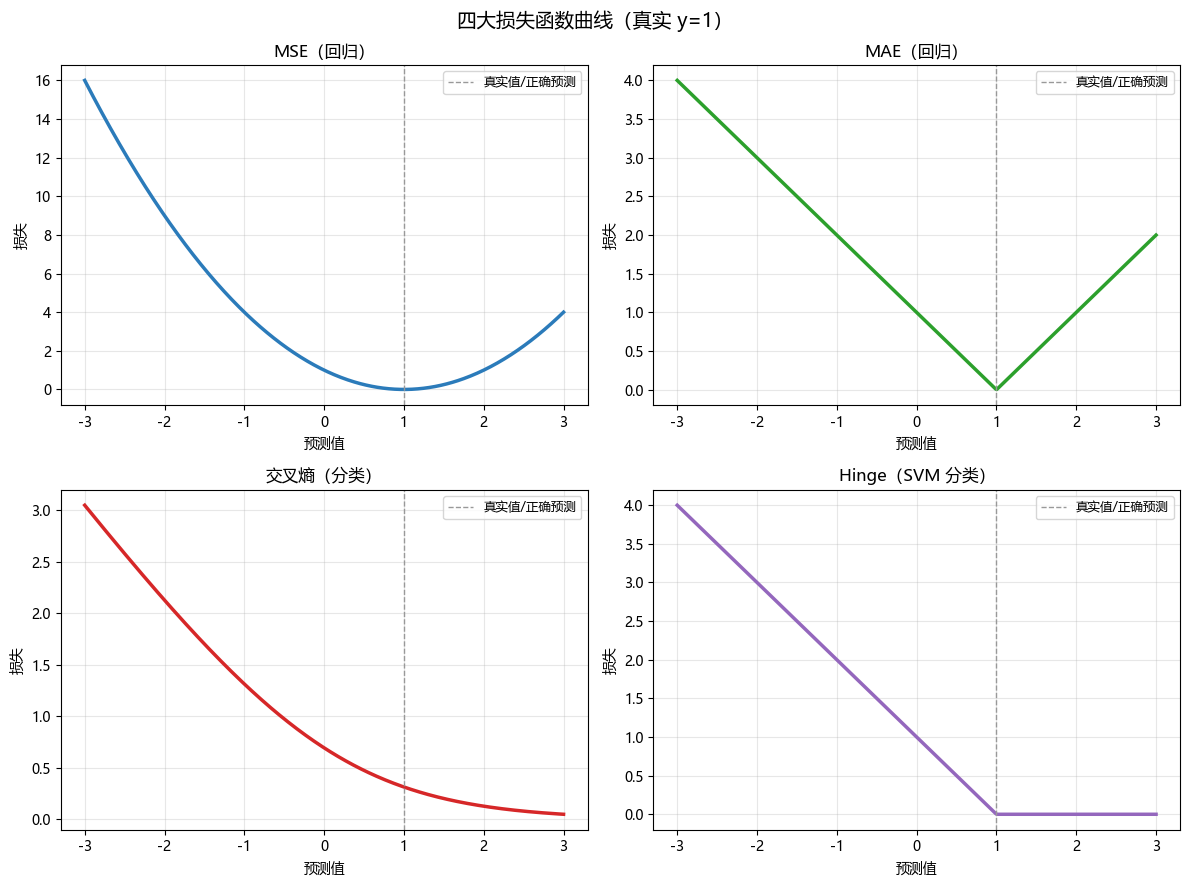

In [41]:
# ---- 各种损失函数的曲线对比 ----
# 假设真实标签 y=1，画"预测值 → 损失"的曲线，横向对比四种损失。
预测 = np.linspace(-3, 3, 500)

MSE曲线 = (预测 - 1) ** 2
MAE曲线 = np.abs(预测 - 1)
# 交叉熵（真实 y=1，先过 sigmoid 得到概率）
p = 1 / (1 + np.exp(-预测))
交叉熵曲线 = -np.log(np.clip(p, 1e-8, 1))
# Hinge（真实 y=+1，直接算 max(0, 1 - y·ŷ)）
Hinge曲线 = np.maximum(0, 1 - 预测)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, y值, name, c in zip(axes.ravel(),
                            [MSE曲线, MAE曲线, 交叉熵曲线, Hinge曲线],
                            ['MSE（回归）', 'MAE（回归）', '交叉熵（分类）', 'Hinge（SVM 分类）'],
                            [蓝, 绿, 红, 紫]):
    ax.plot(预测, y值, color=c, lw=2.5)
    ax.axvline(1, color=灰, ls='--', lw=1, label='真实值/正确预测')
    ax.set_xlabel('预测值'); ax.set_ylabel('损失')
    ax.set_title(name, fontsize=12); ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.suptitle('四大损失函数曲线（真实 y=1）', fontsize=14)
plt.tight_layout()
plt.show()

# 观察各自形状：
# MSE 是抛物线、MAE 是 V 形（尖点在 0，不可导）、
# 交叉熵在"预测接近 0"时冲向无穷、Hinge 在"预测≥1"后为 0。


## 10.6 怎么选：一张表记住

| 任务 | 推荐损失 | 一句话理由 |
| --- | --- | --- |
| 回归（数据干净） | **MSE** | 光滑、可导，正态噪声下最优 |
| 回归（有离群点） | **MAE** | 不平方放大离群点，稳健 |
| 二分类 | **交叉熵** | 概率语义天然匹配，惩罚自信犯错 |
| 多分类 | **交叉熵 + softmax** | 输出 K 类概率分布 |
| 分类（最大间隔） | **Hinge** | 分对够远就撒手，SVM 思想 |

补充两个常听到的「折中」损失（了解即可）：

- **Huber Loss**：MSE 和 MAE 的折中——误差小用平方（光滑），误差大用线性（抗离群点），两边的好处都要；
- **Focal Loss**：交叉熵的改进，专门解决「正负样本极不平衡」的分类问题，给「难分的样本」更高权重（第十九章大模型里也会遇到类似思想）。

> 🔑 **记忆**：回归 MSE/MAE，分类交叉熵/Hinge。损失函数贯穿全书——后面神经网络（第十一章）、PyTorch（第十六章）里，每一处「训练」都绕不开它。


## 10.7 本章小结

这一章把前面散落的损失函数串成了一条线：

1. **损失函数是「裁判」**，衡量预测有多差，引导优化方向；
2. **回归用 MSE/MAE**：MSE 光滑但怕离群点，MAE 稳健但在 0 点不可导；
3. **分类用交叉熵/Hinge**：交叉熵求「概率准」，Hinge 求「分得远」；
4. 选损失的第一原则：**看任务类型**（回归 vs 分类），再看数据特性（有没有离群点）。

> 📌 **下一步**：第十一章进入**深度学习**——讲**神经网络与反向传播**。到这里为止我们都是「单个模型」；从下一章起，把模型「叠起来」，进入深度学习的核心。


# 第十一章 神经网络与反向传播

> 📌 **出处**：李宏毅 2026《机器学习》**神经网络专题**（神经元、激活函数、多层感知机 MLP、前向传播、反向传播 Backpropagation、梯度消失）
> ⭐ **40 天重点**：对应计划 Day12「神经网络与反向传播」、Day13「深度学习基础」。第二章已经建立了「神经元、激活函数、层、深度」的直觉，这一章把它推进到**神经网络最核心的机制：反向传播**——深度学习能训练成千上万个参数，全靠它。

---

## 11.1 从逻辑回归到神经网络：把「一个」变成「很多个」

回想逻辑回归：输入 $\mathbf{x}$，线性变换 $z = \mathbf{w}^\top\mathbf{x} + b$，再过一个 sigmoid 得到概率。这是一个**单个「神经元」**做的事。

神经网络做的事，本质上就是：**把很多个这样的神经元「叠」起来、连起来**，让它们分层协作：

- **输入层**：接收原始特征 $\mathbf{x}$；
- **隐藏层**：一层或多层，每层有多个神经元，做「线性变换 + 非线性激活」；
- **输出层**：产生最终预测（回归输出数值 / 分类输出概率）。

因为有了「隐藏层」和「非线性激活函数」，神经网络能表达远复杂的函数——这正是它能解决 XOR、识别图像、理解语言的根源。

> 💡 一句话：**神经网络 = 一堆神经元分层堆叠 + 非线性激活**。而「怎么训练这么复杂的东西」的答案，就是本章主角**反向传播**。


## 11.2 前向传播：把输入一层层「算」到输出

**前向传播（forward propagation）** 就是「从输入算出预测」的过程，逐层执行两个步骤（以一层为例）：

1. **线性变换**：$z^{[l]} = W^{[l]} a^{[l-1]} + b^{[l]}$（第 $l$ 层把上一层输出 $a^{[l-1]}$ 加权求和）；
2. **非线性激活**：$a^{[l]} = g(z^{[l]})$（$g$ 是激活函数，如 ReLU、sigmoid）。

其中 $a^{[0]} = \mathbf{x}$（第 0 层就是输入），最后一层的 $a^{[L]}$ 就是预测 $\hat y$。整个网络就是一个**层层嵌套的函数**：

$$\hat y = g^{[L]}\big(W^{[L]}\,g^{[L-1]}(\cdots g^{[1]}(W^{[1]}x + b^{[1]})\cdots) + b^{[L]}\big)$$

### 为什么必须要有「非线性」激活函数？

如果每一层都只是线性变换（没有激活），那多层线性变换叠加起来**仍然只是一个线性变换**（矩阵乘法再乘法还是矩阵乘法）。那样「再深的网络」也只能表达线性函数，等于白堆了。**非线性激活函数**是神经网络「能表达复杂函数」的钥匙。

> 🔑 **记忆**：没有激活函数的深层网络退化成线性模型；非线性激活让「深度」真正有意义。


## 11.3 反向传播：用「链式法则」把梯度从后往前传

**反向传播（Backpropagation）** 是**计算神经网络里每个参数梯度的算法**，本质就是微积分的**链式法则（chain rule）**，只是被高效地组织成「从输出层一路往回传」。

### 为什么需要它？

神经网络有成千上万个参数。如果对每个参数都「单独算一次梯度」（用数值差分 $\frac{L(w+\epsilon)-L(w)}{\epsilon}$），参数一多就慢到不可接受。反向传播的高明之处在于：**一次「前向 + 反向」就把所有参数的梯度全算出来**，计算量和前向传播同量级。

### 核心直觉：梯度沿「计算图」反向流动

把网络的每一步看成一张**计算图**（计算图：每个节点是一个运算，边是数据的流向）。前向传播时数据从左到右流；反向传播时，**梯度从右（损失）往左（参数）流**，每经过一个运算就按「链式法则」把梯度拆解传播。

链式法则一句话版：若 $L$ 通过 $a$ 依赖 $z$，$z$ 又依赖 $w$，则

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a}\cdot\frac{\partial a}{\partial z}\cdot\frac{\partial z}{\partial w}$$

即「梯度 = 外层梯度 × 本层局部梯度」，一层层往回乘。


## 11.4 反向传播的逐步推导（以两层网络为例）

下面用一个**两层网络 + MSE 损失**的完整例子，把反向传播的每一步算清楚。设网络结构：输入 $x$ → 隐藏层（1 个神经元，sigmoid）→ 输出 $\hat y$。

### 记号

- 隐藏层：$z_1 = w_1 x + b_1$，$a_1 = \sigma(z_1)$；
- 输出层：$\hat y = w_2 a_1 + b_2$；
- 损失（单个样本）：$L = \frac12(\hat y - y)^2$（系数 $\frac12$ 让求导好看）。

### 反向传播四步（🔑 要会跟着推）

**第一步：算损失对输出的梯度**

$$\frac{\partial L}{\partial \hat y} = \hat y - y$$

**第二步：把梯度传到输出层参数 $w_2, b_2$**

$$\frac{\partial L}{\partial w_2} = \frac{\partial L}{\partial \hat y}\cdot\frac{\partial \hat y}{\partial w_2} = (\hat y - y)\cdot a_1, \qquad \frac{\partial L}{\partial b_2} = (\hat y - y)\cdot 1$$

**第三步：把梯度继续传到隐藏层输出 $a_1$**

$$\frac{\partial L}{\partial a_1} = \frac{\partial L}{\partial \hat y}\cdot\frac{\partial \hat y}{\partial a_1} = (\hat y - y)\cdot w_2$$

**第四步：穿过 sigmoid，传到隐藏层参数 $w_1, b_1$**

sigmoid 的导数是 $\sigma'(z_1) = \sigma(z_1)(1-\sigma(z_1)) = a_1(1-a_1)$，所以：

$$\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial a_1}\cdot a_1(1-a_1)$$

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial z_1}\cdot x, \qquad \frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial z_1}\cdot 1$$

### 看出规律了吗？

每一步都是「**拿到从后面传来的梯度 $\frac{\partial L}{\partial a}$，乘上本层的局部导数 $\frac{\partial a}{\partial z}$、$\frac{\partial z}{\partial w}$，继续往前传**」。这正是「反向传播」名字的由来——梯度从损失出发，一层层往输入方向「传播」。下面的代码把上面的公式完整实现出来。


In [42]:
# ---- 从零实现两层网络的前向传播 + 反向传播（手动求梯度） ----
# 用上面 11.4 节推导的公式，手动实现一次前向 + 反向，验证梯度正确。

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 单个样本：x=0.6, y=1.0
x, y = 0.6, 1.0

# 随机初始化参数
np.random.seed(5)
w1, b1 = 0.5, -0.3
w2, b2 = 0.2, 0.1

# ---- 前向传播 ----
z1 = w1 * x + b1
a1 = sigmoid(z1)
y_hat = w2 * a1 + b2
L = 0.5 * (y_hat - y) ** 2

print(f"前向传播：z1={z1:.4f}, a1={a1:.4f}, ŷ={y_hat:.4f}, 损失 L={L:.4f}")

# ---- 反向传播（按 11.4 节公式一步步算） ----
dL_dyhat = y_hat - y                      # 第一步
dL_dw2 = dL_dyhat * a1                    # 第二步
dL_db2 = dL_dyhat * 1
dL_da1 = dL_dyhat * w2                    # 第三步
dL_dz1 = dL_da1 * a1 * (1 - a1)           # 第四步（穿过 sigmoid）
dL_dw1 = dL_dz1 * x
dL_db1 = dL_dz1 * 1

print("反向传播得到的梯度：")
print(f"  ∂L/∂w1 = {dL_dw1:.4f},  ∂L/∂b1 = {dL_db1:.4f}")
print(f"  ∂L/∂w2 = {dL_dw2:.4f},  ∂L/∂b2 = {dL_db2:.4f}")

# ---- 用数值梯度（差分法）验证反向传播是否正确 ----
def 损失(w1, b1, w2, b2):
    a1 = sigmoid(w1 * x + b1)
    return 0.5 * (w2 * a1 + b2 - y) ** 2

eps = 1e-5
数值_dw1 = (损失(w1+eps, b1, w2, b2) - 损失(w1-eps, b1, w2, b2)) / (2*eps)
数值_dw2 = (损失(w1, b1, w2+eps, b2) - 损失(w1, b1, w2-eps, b2)) / (2*eps)

print(f"\n数值梯度验证：∂L/∂w1 ≈ {数值_dw1:.4f}（反向传播算得 {dL_dw1:.4f}）")
print(f"               ∂L/∂w2 ≈ {数值_dw2:.4f}（反向传播算得 {dL_dw2:.4f}）")
print("两者几乎一致 → 反向传播的公式正确 ✅")


前向传播：z1=0.0000, a1=0.5000, ŷ=0.2000, 损失 L=0.3200
反向传播得到的梯度：
  ∂L/∂w1 = -0.0240,  ∂L/∂b1 = -0.0400
  ∂L/∂w2 = -0.4000,  ∂L/∂b2 = -0.8000

数值梯度验证：∂L/∂w1 ≈ -0.0240（反向传播算得 -0.0240）
               ∂L/∂w2 ≈ -0.4000（反向传播算得 -0.4000）
两者几乎一致 → 反向传播的公式正确 ✅


## 11.5 完整的训练循环：前向 + 反向 + 更新

把「前向传播、反向传播、参数更新」串起来，就是一个完整的神经网络训练循环（这正是第十六章 PyTorch 训练循环的「手写版」）：

1. **前向**：算预测 $\hat y$ 和损失 $L$；
2. **反向**：算每个参数的梯度 $\frac{\partial L}{\partial \theta}$；
3. **更新**：$\theta \leftarrow \theta - \eta \cdot \frac{\partial L}{\partial \theta}$（梯度下降）。

下面的代码用这个完整流程，训练一个两层网络解决 **XOR（异或）问题**——一个经典的「线性模型解不了、必须靠神经网络」的问题。XOR 真值表：输入 $(0,0)\to0,\ (0,1)\to1,\ (1,0)\to1,\ (1,1)\to0$，两个输入相同时输出 0、不同时输出 1。


训练后网络的预测（应接近 [0,1,1,0]）：
[0.024 0.975 0.974 0.032]

最终损失 = 0.000717


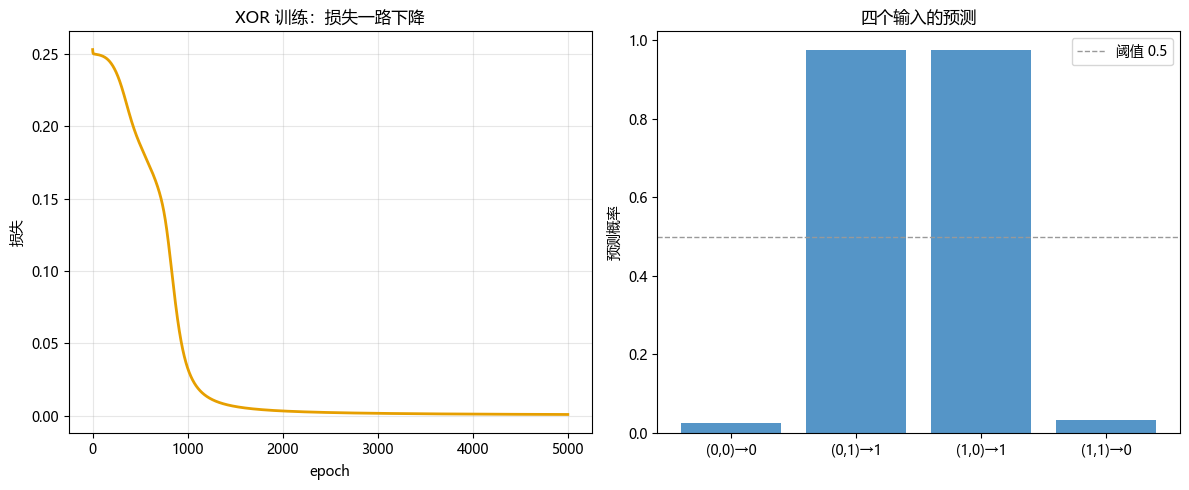

In [43]:
# ---- 从零训练两层网络解决 XOR（异或）问题 ----
# XOR 是线性不可分的，必须用带非线性隐藏层的网络才能学会。
np.random.seed(1)

# XOR 数据
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

# 网络结构：2 输入 → 2 隐藏神经元(sigmoid) → 1 输出(sigmoid)
n_in, n_hid, n_out = 2, 2, 1
W1 = np.random.randn(n_in, n_hid) * 0.5
b1 = np.zeros((1, n_hid))
W2 = np.random.randn(n_hid, n_out) * 0.5
b2 = np.zeros((1, n_out))

lr = 0.5
损失记录 = []
for epoch in range(5000):
    # ---- 前向 ----
    Z1 = X_xor @ W1 + b1
    A1 = sigmoid(Z1)                 # 隐藏层激活
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)                 # 输出（概率）
    # MSE 损失
    L = np.mean((A2 - y_xor) ** 2)
    损失记录.append(L)

    # ---- 反向（向量化，一次算整批 4 个样本） ----
    dA2 = (A2 - y_xor) * (A2 * (1 - A2))      # 穿过输出层 sigmoid
    dW2 = A1.T @ dA2
    db2 = np.sum(dA2, axis=0, keepdims=True)
    dA1 = dA2 @ W2.T
    dZ1 = dA1 * (A1 * (1 - A1))               # 穿过隐藏层 sigmoid
    dW1 = X_xor.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ---- 更新 ----
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

print("训练后网络的预测（应接近 [0,1,1,0]）：")
print(np.round(A2.ravel(), 3))
print(f"\n最终损失 = {损失记录[-1]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(损失记录, color=橙, lw=2)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('损失')
axes[0].set_title('XOR 训练：损失一路下降')
axes[0].grid(alpha=0.3)
axes[1].bar(range(4), A2.ravel(), color=蓝, alpha=0.8)
axes[1].axhline(0.5, color=灰, ls='--', lw=1, label='阈值 0.5')
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0'])
axes[1].set_ylabel('预测概率'); axes[1].set_title('四个输入的预测')
axes[1].legend()
plt.tight_layout()
plt.show()

# 关键：XOR 是线性不可分的（没法画一条直线分开 0 和 1），
# 但两层网络通过隐藏层学到了非线性决策，成功拟合。


## 11.6 反向传播中的经典问题：梯度消失与梯度爆炸

反向传播要把梯度**一层层乘回去**。当网络很深时，这个「连乘」会带来两个著名问题：

- **梯度消失（vanishing gradient）**：如果每一层的局部梯度都小于 1（比如 sigmoid 导数最大才 0.25），几十层乘下来，梯度会**指数级地衰减到接近 0**——前面的层几乎学不到任何东西，训练停滞；
- **梯度爆炸（exploding gradient）**：反之，如果局部梯度都大于 1，连乘会让梯度**指数级膨胀**，参数一步更新飞出天际，损失变成 NaN。

### 为什么会这样？关键在激活函数和权重初始化

- **sigmoid / tanh** 在两端「饱和」，导数趋近 0，是梯度消失的重灾区；
- **ReLU** 在正半轴导数恒为 1，大大缓解了梯度消失（这也是它流行的原因之一）；
- 合理的**权重初始化**（如 Xavier、He 初始化）能控制每层的梯度尺度，避免爆炸。

> 💡 这些是深度网络训练的经典难题，现代架构（残差连接 ResNet、归一化层、更好的激活函数）很大程度就是为了「修」梯度传播。第十二、十三章会继续遇到。


## 11.7 【李沐 d2l】多层感知机 MLP：从零与简洁实现

> 📌 **出处**：李沐《动手学深度学习 V2》第 4 章「多层感知机」
> 📎 **完整可运行代码**：`实战代码_李沐/多层感知机-从零与简洁实现.ipynb`

第 2 章从概念上讲了神经元和层，这一节把**多层感知机（MLP）**落到 PyTorch 代码。MLP 就是在输入输出之间加**隐藏层 + ReLU**：

$$H = \mathrm{ReLU}(XW_1+b_1), \quad O = HW_2+b_2$$

### 从零实现 vs 简洁实现

| | 从零 | 简洁 |
| --- | --- | --- |
| 参数 | 手动 `W1,b1,W2,b2` | `nn.Linear(784,256)` + `nn.Linear(256,10)` |
| 激活 | 手写 `relu = max(x,0)` | `nn.ReLU()` |
| 组装 | 手写 `net(X)` | `nn.Sequential(Flatten, Linear, ReLU, Linear)` |

```python
# 简洁实现（一行网络）
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))
```

> 🔑 **记忆**：
> - MLP = **线性层 + 非线性激活函数**反复堆叠；
> - 隐藏层神经元数（如 256）是**超参数**，越大模型越强但也越容易过拟合；
> - 隐藏层常配 **ReLU**，输出层按任务选（回归=线性、二分类=sigmoid、多分类=softmax）。


## 11.8 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 神经网络 | 神经元分层堆叠 + 非线性激活 |
| 前向传播 | 输入逐层算到输出 |
| 反向传播 | 用链式法则把梯度从后往前传 |
| 链式法则 | 梯度 = 外层梯度 × 本层局部梯度，层层相乘 |
| 梯度消失/爆炸 | 深层连乘导致梯度趋近 0 或爆炸 |

🔑 **记忆**：反向传播 = 链式法则的高效实现；sigmoid 导数 $\sigma'(z)=\sigma(z)(1-\sigma(z))$；「前向算损失、反向算梯度、更新参数」是训练循环三步。

> 📌 **下一步**：第十二章讲 **CNN（卷积神经网络）**——把「全连接」换成「卷积」，专门处理图像，并引出 ResNet 等现代结构。


# 第十二章 卷积神经网络（CNN）

> 📌 **出处**：李宏毅 2026《机器学习》**卷积神经网络专题**（CNN 基本概念、卷积与池化、LeNet、ResNet 残差网络）
> ⭐ **40 天重点**：对应计划 Day13「深度学习基础：CNN」、Day14「经典网络（LeNet/AlexNet/ResNet）」。CNN 是**处理图像**的利器，核心思想用两个词概括：**局部连接**、**权值共享**。

---

## 12.1 为什么图像不能用「全连接」网络？

上一章的网络是**全连接（fully connected）**：每个神经元连到上一层**所有**输入。拿一张图像当输入，会立刻遇到两个灾难性问题：

假设图像是 $1000 \times 1000$ 像素，展平后就是 $10^6$ 维输入。若第一个隐藏层有 $10^6$ 个神经元，那么这一层的权重就有 $10^6 \times 10^6 = 10^{12}$ 个！参数多到：**算不动、存不下、极易过拟合**。

更深层的洞察是：**图像的规律是「局部」的**。判断「这张图里有猫」，靠的是猫耳朵、眼睛、胡须这些**局部特征**的组合，而不是把整张图所有像素无差别地看一遍。所以：

- **局部连接（local connectivity）**：一个神经元只连接输入的一小块区域（感受野），不用看全图；
- **权值共享（weight sharing）**：同一个「特征探测器」（卷积核）在整张图上**滑动复用**——一个「找猫耳朵」的探测器，在图的任何位置都能用，不需要每个位置单独学一遍。

这两点让 CNN 的参数**骤减**，还能自动学到「平移不变」的特征（猫耳朵出现在左上还是右下，同一个探测器都能识别）。

> 💡 一句话：**CNN = 用「滑动的小窗口（卷积核）」扫描图像，每个窗口学一个局部特征，全图共享这一组权重。**


## 12.2 卷积操作：一个小窗口在图上「滑」

**卷积（convolution）** 是 CNN 的核心运算。形象地说：

1. 有一个小矩阵叫**卷积核（kernel / filter）**，比如 $3\times3$；
2. 把它放在图像的某个位置，**对应位置相乘再求和**，得到一个数；
3. 让卷积核在图上**从上到下、从左到右滑动**，每个位置算出一个数；
4. 所有位置的结果拼成一张新图，叫**特征图（feature map）**。

数学上（二维卷积，离散形式）：

$$(I * K)(i, j) = \sum_{u}\sum_{v} I(i+u,\, j+v)\cdot K(u, v)$$

其中 $I$ 是输入图像，$K$ 是卷积核。**不同的卷积核，能提取不同的特征**：

- 边缘检测核（如 [[1,0,-1],[1,0,-1],[1,0,-1]]）能突出**竖直边缘**；
- 平滑核（全 1/9）能做**模糊**；
- 训练时，这些卷积核的**数值是学出来的**——网络自己学会「什么样的探测器最有用」。

> 💡 理解卷积核的意义：它相当于一个**可学习的「特征探测器」**，在图上滑动寻找某种模式。


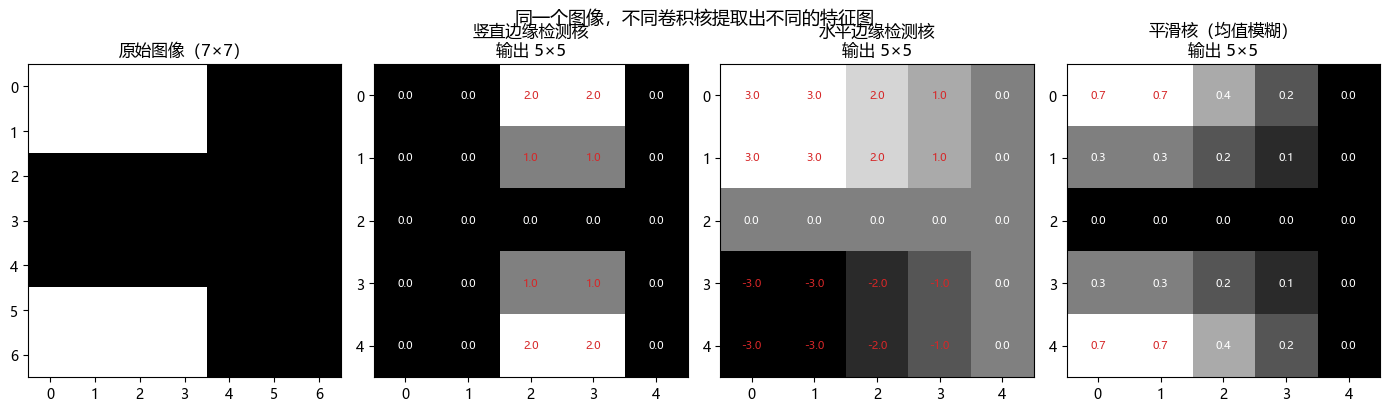

In [44]:
# ---- 卷积操作演示：不同卷积核提取不同特征 ----
def 卷积2d(图像, 核):
    """二维卷积：卷积核在图像上滑动，对应相乘求和。"""
    h, w = 图像.shape
    kh, kw = 核.shape
    out_h, out_w = h - kh + 1, w - kw + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i, j] = np.sum(图像[i:i+kh, j:j+kw] * 核)
    return out

# 造一张 7x7 的"图像"：左边亮(1)、右边暗(0)，中间有一条竖直边缘
图像 = np.zeros((7, 7))
图像[:, :4] = 1.0
图像[2:5, :] = 0.0        # 中间挖一条水平暗带，制造更多纹理

# 三个不同的卷积核
竖直边缘核 = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
水平边缘核 = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
平滑核     = np.ones((3, 3)) / 9

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(图像, cmap='gray'); axes[0].set_title('原始图像（7×7）')
for ax, 核, t in zip(axes[1:],
                     [竖直边缘核, 水平边缘核, 平滑核],
                     ['竖直边缘检测核', '水平边缘检测核', '平滑核（均值模糊）']):
    out = 卷积2d(图像, 核)
    ax.imshow(out, cmap='gray')
    ax.set_title(t + f'\n输出 {out.shape[0]}×{out.shape[1]}')
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            ax.text(j, i, f'{out[i,j]:.1f}', ha='center', va='center', fontsize=8,
                    color=红 if out[i, j] > 0.5 or out[i, j] < -0.5 else 'white')
plt.suptitle('同一个图像，不同卷积核提取出不同的特征图', fontsize=13)
plt.tight_layout()
plt.show()

# 观察：竖直边缘核突出"左右亮度突变"的竖边；水平边缘核突出横边；
# 平滑核把每个 3×3 邻域取平均，相当于模糊。


## 12.3 卷积的两个关键参数：步长与填充

卷积滑动时有两个参数要设：

- **步长（stride）**：卷积核每次滑多远。步长 1 = 一格一格滑；步长 2 = 每次跳两格，输出会变小；
- **填充（padding）**：在图像四周补一圈 0。好处：① 控制输出尺寸；② 让边缘像素也能被充分「看到」。

输出尺寸公式（输入 $W$，核 $K$，步长 $S$，填充 $P$）：

$$\text{输出尺寸} = \frac{W - K + 2P}{S} + 1$$

- **步长越大 → 输出越小**（相当于「下采样」）；
- **填充越大 → 输出越大**，$P=(K-1)/2$ 时能保持尺寸不变（叫 same padding）。

> 💡 实际 CNN 里常交替用「卷积 + 池化」逐层缩小尺寸、加深通道数，把原始图像逐步抽象成高级语义。


## 12.4 池化（Pooling）：压缩信息、提取主导特征

**池化（pooling）** 是另一种滑动窗口操作，但**不做加权求和**，而是取窗口内的一个统计量：

- **最大池化（max pooling）**：取窗口内**最大值**（最常用）——保留「最显著」的特征；
- **平均池化（average pooling）**：取窗口内**平均值**——保留「整体」信息。

池化的作用：

1. **降维**：把特征图变小，减少后续计算量和参数；
2. **增加平移不变性**：特征稍微移动一点，池化后的结果基本不变；
3. **抑制噪声**：最大池化只保留最强烈的响应。

池化**没有需要学习的参数**（不像卷积核要学），是一个固定的「下采样」操作。

> 💡 常见配置：卷积核 $3\times3$ 之后接一个 $2\times2$ 的**最大池化**（步长 2），把特征图长宽各缩小一半。


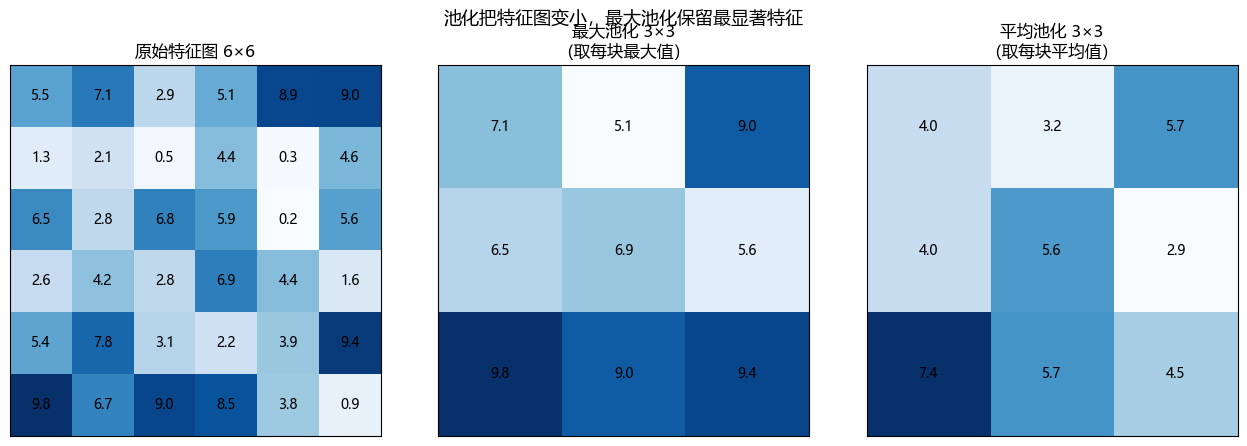

In [45]:
# ---- 池化演示：最大池化 vs 平均池化 ----
def 池化2d(特征图, 池化尺寸=2, 模式='max'):
    h, w = 特征图.shape
    ph, pw = 池化尺寸, 池化尺寸
    out = np.zeros((h // ph, w // pw))
    for i in range(0, h, ph):
        for j in range(0, w, pw):
            块 = 特征图[i:i+ph, j:j+pw]
            out[i//ph, j//pw] = np.max(块) if 模式 == 'max' else np.mean(块)
    return out

# 造一张 6x6 特征图（模拟卷积后的输出）
np.random.seed(3)
特征图 = np.round(np.random.rand(6, 6) * 10, 1)
最大池化结果 = 池化2d(特征图, 2, 'max')
平均池化结果 = 池化2d(特征图, 2, 'avg')

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, 数据, t in zip(axes, [特征图, 最大池化结果, 平均池化结果],
                       ['原始特征图 6×6', '最大池化 3×3\n（取每块最大值）', '平均池化 3×3\n（取每块平均值）']):
    ax.imshow(数据, cmap='Blues')
    for i in range(数据.shape[0]):
        for j in range(数据.shape[1]):
            ax.text(j, i, f'{数据[i,j]:.1f}', ha='center', va='center', fontsize=10)
    ax.set_title(t)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('池化把特征图变小，最大池化保留最显著特征', fontsize=13)
plt.tight_layout()
plt.show()

# 记忆点：2×2 池化把尺寸减半；max 取最大（突出主导），avg 取平均（平滑）。


## 12.5 经典 CNN 结构：LeNet 与「卷积 + 池化 + 全连接」范式

最早的经典 CNN 是 **LeNet**（1998，识别手写数字），它奠定了 CNN 的标准范式，之后的网络（AlexNet、VGG 等）都是它的「加深加宽」版。LeNet 的结构是：

$$\text{输入图像} \to \text{卷积} \to \text{池化} \to \text{卷积} \to \text{池化} \to \text{全连接} \to \text{输出}$$

这个范式的设计逻辑：

1. **前面的「卷积 + 池化」层**负责**自动提取特征**（从低级边缘 → 高级形状），尺寸逐层变小、通道逐层变多；
2. **后面的「全连接」层**负责**做分类/回归决策**，把学到的特征映射到最终输出。

> 💡 一句话：**CNN = 用卷积自动学特征（替代人工特征工程） + 用全连接做决策。** 这正好呼应第七章——以前要人肉设计特征，现在 CNN 自己学。


## 12.6 【李沐 d2l】AlexNet：第一个「又深又宽」的 CNN（2012）

> 📌 **出处**：李沐《动手学深度学习 V2》第 7 章「AlexNet」
> 📎 **完整可运行代码**：`实战代码_李沐/AlexNet.ipynb`

LeNet（1998）之后沉寂了近 14 年，直到 2012 年 **AlexNet** 在 ImageNet 上把错误率从 26% 降到 15%，才引爆了深度学习。它和 LeNet 骨架相似（卷积→池化→全连接），但**更宽更深**，并用了几个关键新技巧：

| 技巧 | 作用 |
| --- | --- |
| **ReLU** 激活 | 比 sigmoid/tanh 训练快得多，缓解梯度消失 |
| **Dropout** | 在 FC 层随机丢神经元，抑制过拟合 |
| **最大池化** | 取代 LeNet 的平均池化 |
| **数据增广** | 翻转/裁剪扩充训练集 |
| **GPU 训练** | 两张 GPU 并行（现代已普及） |

结构（输入 224×224，第一层用 **11×11 大卷积核**、步长 4）：

```
Conv(11×11, s=4) → MaxPool(3×3, s=2) → Conv(5×5) → MaxPool(3×3, s=2)
→ Conv(3×3) ×3 → MaxPool(3×3, s=2) → FC(4096) → FC(4096) → FC(10)
```

> 🔑 **记忆**：AlexNet = LeNet 的「加深加宽版」+ **ReLU + Dropout + 最大池化**三件套，是「大数据 + 大模型 + GPU」路线的开端。


## 12.7 【李沐 d2l】VGG：用「卷积块」堆出又深又规整的网络（2014）

> 📌 **出处**：李沐《动手学深度学习 V2》第 7 章「VGG」
> 📎 **完整可运行代码**：`实战代码_李沐/VGG.ipynb`

AlexNet 的卷积核大小不一（11、5、3），结构杂乱。**VGG** 提出一个规整的想法：**只用 3×3 小卷积核，把「若干个 3×3 卷积 + 一个池化」打包成「VGG 块」，反复堆叠**。

为什么用**多个 3×3 代替一个大核**？

- 两个 3×3 的感受野 = 一个 5×5；三个 3×3 = 一个 7×7；
- 但参数量更少、非线性更多（每个卷积后都能过 ReLU），表达能力更强。

```
def vgg_block(num_convs, in_ch, out_ch):   # 一个 VGG 块
    layers = []
    for _ in range(num_convs):
        layers += [nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU()]
        in_ch = out_ch
    layers += [nn.MaxPool2d(kernel_size=2, stride=2)]   # 块尾池化，尺寸减半
    return nn.Sequential(*layers)
```

VGG-11 就是「8 个卷积（5 个块）+ 3 个全连接」。通道数逐块翻倍（64→128→256→512→512），尺寸逐块减半。

> 🔑 **记忆**：VGG 的哲学 = **「小卷积核 + 规整块」**。用 `3×3 + padding=1` 保持尺寸不变，靠池化减半，网络又深又好看、容易迁移。


## 12.8 【李沐 d2l】NiN：用「1×1 卷积」和「全局平均池化」替代全连接（2013）

> 📌 **出处**：李沐《动手学深度学习 V2》第 7 章「NiN（网络中的网络）」
> 📎 **完整可运行代码**：`实战代码_李沐/NiN与GoogLeNet.ipynb`

传统 CNN 最后接一大段**全连接层**，参数巨多、易过拟合。**NiN** 提出两个替代思路：

**① 1×1 卷积 = 逐像素的全连接层**：它在每个像素位置对「通道」做线性组合 + 非线性，等价于对每个位置独立跑一个全连接，但**参数少得多**，还能灵活调通道数（升维/降维）。

**② 全局平均池化（Global Avg Pooling）**：把最后一层每个通道的整张特征图**求平均**，直接得到「每类一个分数」，**彻底丢掉 FC 层**，几乎没参数、天然抗过拟合。

NiN 块 = `Conv(3×3) + Conv(1×1) + Conv(1×1)` 各接 ReLU；堆 4 个块，最后接全局平均池化。

> 🔑 **记忆**：**1×1 卷积**是「调通道数 + 加非线性」的利器（后面 GoogLeNet/ResNet 都在用）；**全局平均池化**是「扔掉 FC 层」的做法，参数少、不易过拟合。


## 12.9 【李沐 d2l】GoogLeNet：Inception 块「多条支路并行」再拼接（2014）

> 📌 **出处**：李沐《动手学深度学习 V2》第 7 章「GoogLeNet」
> 📎 **完整可运行代码**：`实战代码_李沐/NiN与GoogLeNet.ipynb`

2014 年 ImageNet 冠军 **GoogLeNet** 的核心是 **Inception 块**：输入同时走 **4 条并行支路**（1×1 卷积、3×3 卷积、5×5 卷积、3×3 最大池化），再把结果在**通道维拼接**起来。这样网络能**在同一层捕捉不同尺度的特征**。

```
                ┌─ Conv(1×1)
                ├─ Conv(1×1) → Conv(3×3)
输入 ───────────┼─ Conv(1×1) → Conv(5×5)      → 通道维拼接
                ├─ MaxPool(3×3) → Conv(1×1)
                └────────────────
```

> 💡 每条支路前面/后面都插 **1×1 卷积做「瓶颈」降维**，把 3×3、5×5 的计算量压下来——这是它能在深度、宽度都远超 AlexNet 的同时还保持可控算力的关键。

> 🔑 **记忆**：**Inception 块 = 多条不同尺度支路并行 + 通道拼接**；**1×1 卷积瓶颈**用来降维省算力。


## 12.10 【李沐 d2l】批量规范化 BatchNorm：让每一层输入稳定（2015）

> 📌 **出处**：李沐《动手学深度学习 V2》第 7 章「批量规范化」
> 📎 **完整可运行代码**：`实战代码_李沐/批量规范化.ipynb`

训练深层网络时，每层输入的分布会随训练不断漂移（**内部协变量偏移**），导致要小心翼翼地调学习率。**批量规范化（BatchNorm）** 的做法：对每个**小批量**，把每个通道的激活值**归一化到均值 0、方差 1**，再用两个**可学习参数** $\gamma$（缩放）和 $\beta$（平移）拉回合适尺度：

$$\hat x = \frac{x - \mu_\text{batch}}{\sqrt{\sigma^2_\text{batch} + \epsilon}},\qquad y = \gamma \hat x + \beta$$

好处：

1. **训练更稳**，可以放心用**更大的学习率**，收敛更快；
2. 对参数初始化**不那么敏感**；
3. 自带一点**正则化**效果（每次用本批的统计量，有随机性）。

> ⚠️ **训练 vs 推理**：训练时用**本批**的均值/方差；推理时用**全局移动平均**的均值/方差（`nn.BatchNorm2d` 会自动切换）。BatchNorm 也**只能加在全连接层或卷积层之后、激活函数之前**。

> 🔑 **记忆**：BatchNorm = 「小批量归一化 + 可学习缩放平移」，把每层输入拉回标准分布，是训练深层网络（ResNet 等）的标配。


## 12.11 ResNet：用「残差连接」让网络可以非常深

按直觉，「网络越深、能力越强」，但实践中发现：**单纯堆深网络，训练反而变差**——因为越深，**梯度消失**（第十一章）越严重，前面的层学不动。

**ResNet（残差网络，2015）** 用一个极其巧妙的想法解决了这个问题——**残差连接（residual connection，也叫跳跃连接 skip connection）**：

$$\text{输出} = F(x) + x$$

即：让每一块的输出，不仅经过若干卷积层 $F(x)$，还**直接把输入 $x$ 「抄近路」加回去**。

为什么有效？

- 梯度可以**沿着这条「抄近路」直接往回传**，不再需要穿过层层卷积的连乘，**缓解梯度消失**；
- 网络的学习目标从「学整个映射 $H(x)$」变成「学残差 $F(x) = H(x) - x$」——后者更容易学（最差情况让 $F(x)=0$，至少不退化）。

> 💡 残差连接让网络可以堆到几十、上百层甚至更深，是 ResNet 能拿 2015 年 ImageNet 冠军、并深刻影响后续所有大模型（Transformer 也借鉴了它）的关键。


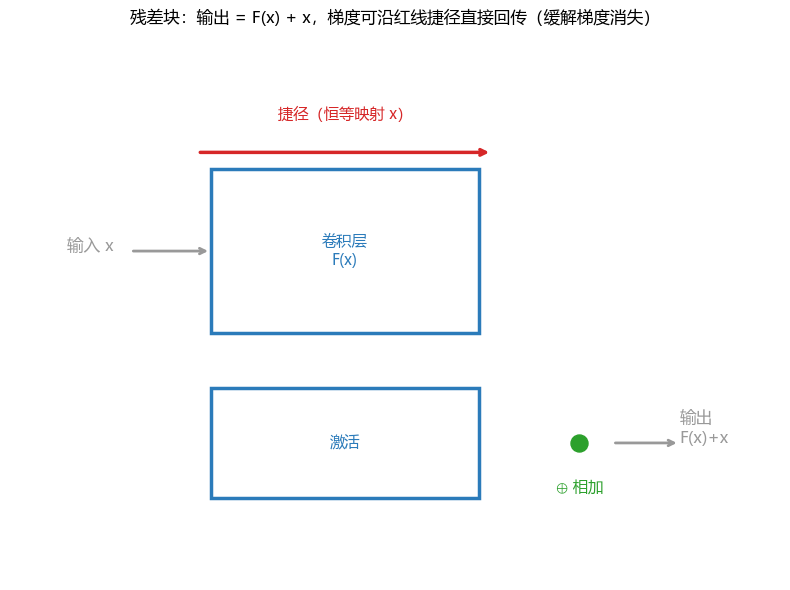

In [46]:
# ---- 残差连接（ResNet 核心思想）可视化 ----
# 画一个"残差块"：输出 = F(x) + x，梯度能沿捷径直接传回去。
fig, ax = plt.subplots(figsize=(8, 6))

# 主路径（要学的 F(x)）
ax.add_patch(plt.Rectangle((0.3, 0.45), 0.4, 0.3, fill=False, edgecolor=蓝, lw=2.5))
ax.text(0.5, 0.6, '卷积层\nF(x)', ha='center', va='center', fontsize=11, color=蓝)
ax.add_patch(plt.Rectangle((0.3, 0.15), 0.4, 0.2, fill=False, edgecolor=蓝, lw=2.5))
ax.text(0.5, 0.25, '激活', ha='center', va='center', fontsize=11, color=蓝)

# 捷径（恒等映射 x）
ax.annotate('', xy=(0.72, 0.78), xytext=(0.28, 0.78),
            arrowprops=dict(arrowstyle='->', color=红, lw=2.5))
ax.text(0.5, 0.84, '捷径（恒等映射 x）', ha='center', fontsize=11, color=红)

# 相加节点
ax.scatter([0.85], [0.25], color=绿, s=150, zorder=5)
ax.text(0.85, 0.16, '⊕ 相加', ha='center', fontsize=11, color=绿)

# 输入/输出
ax.text(0.12, 0.6, '输入 x', ha='center', fontsize=12, color=灰)
ax.annotate('', xy=(0.3, 0.6), xytext=(0.18, 0.6), arrowprops=dict(arrowstyle='->', color=灰, lw=2))
ax.annotate('', xy=(1.0, 0.25), xytext=(0.9, 0.25), arrowprops=dict(arrowstyle='->', color=灰, lw=2))
ax.text(1.0, 0.25, '输出\nF(x)+x', ha='left', fontsize=12, color=灰)

ax.set_xlim(0, 1.15); ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('残差块：输出 = F(x) + x，梯度可沿红线捷径直接回传（缓解梯度消失）', fontsize=12)
plt.tight_layout()
plt.show()

# 记忆点：残差连接 = 主路径输出 + 原始输入，最差让 F(x)=0 也不会退化。


## 12.12 【李沐 d2l】DenseNet：每一层都连到「前面所有层」（2017）

> 📌 **出处**：李沐《动手学深度学习 V2》第 7 章「DenseNet」
> 📎 **完整可运行代码**：`实战代码_李沐/DenseNet.ipynb`

ResNet 让每层连到「上一层」；**DenseNet** 更激进：**每一层的输出都拼接到「前面所有层」的输入里**（**密集连接**）。

$$\mathbf{x}_l = H([\mathbf{x}_0, \mathbf{x}_1, \dots, \mathbf{x}_{l-1}])$$

- `[...]` 表示**通道维拼接**（不是相加）；
- 好处：**特征极致复用**（后面的层能直接看到前面所有特征）、**梯度流极强**、**参数量反而更少**（因为每层不需要重新学已经有的特征）；
- 代价：特征图通道随层数增长，内存占用大——所以用「过渡层」用 1×1 卷积把通道数压回去。

> 🔑 **记忆**：ResNet 是「加」（残差 `F(x)+x`），DenseNet 是「**拼**」（密集连接 `[x₀,…,x_{l-1}]` 通道拼接）；两者都用「跳跃连接」解决深层梯度问题，DenseNet 把特征复用做到极致。


## 12.13 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 局部连接 | 神经元只连一小块（感受野） |
| 权值共享 | 一个卷积核全图滑动复用 |
| 卷积 | 小窗口滑动、相乘求和，提取特征 |
| 池化 | 下采样，max 保留最显著特征 |
| LeNet 范式 | 卷积+池化提取特征 → 全连接做决策 |
| AlexNet | 加深加宽 + ReLU/Dropout/最大池化三件套 |
| VGG | 只用 3×3 小卷积核，堆成规整的「块」 |
| NiN | 1×1 卷积调通道、全局平均池化替代全连接 |
| GoogLeNet | Inception 块多尺度并行 + 1×1 瓶颈降维 |
| BatchNorm | 小批量归一化 + 可学习缩放平移，训练更稳 |
| 残差连接 | 输出 = F(x)+x，梯度走捷径，缓解梯度消失 |
| DenseNet | 密集连接（通道拼接），特征极致复用 |

🔑 **记忆**：CNN 两大核心 = **局部连接 + 权值共享**；常见结构 = 卷积(3×3) → 池化(2×2)。现代 CNN 演进脉络：**AlexNet**(加深加宽+ReLU/Dropout) → **VGG**(小核规整块) → **NiN**(1×1 卷积) → **GoogLeNet**(Inception) → **BatchNorm**(稳定训练) → **ResNet**(残差) → **DenseNet**(密集连接)。

> 📌 **下一步**：第十三章讲 **Transformer 与注意力机制**——从 CNN 的「局部感受野」跳到「全局注意力」，这是现代大模型（GPT、LLaMA）的基石。


# 第十三章 Transformer 与注意力机制

> 📌 **出处**：李宏毅 2026《机器学习》**Transformer 专题**（注意力机制、自注意力 Self-Attention、多头注意力 Multi-Head Attention、位置编码、Transformer 架构）
> ⭐ **40 天重点**：对应计划 Day18「Transformer 与大模型概念」的铺垫。Transformer（2017）彻底改变了深度学习——它是 GPT、BERT、LLaMA 等所有现代大模型的**基石**。这一章讲清它的核心：**注意力机制**。

---

## 13.1 从 CNN 到 Transformer：为什么需要「注意力」

CNN 用「局部感受野」处理图像，但它有一个局限：**要看清远距离的关系，得堆很多层**（让信息逐层扩散）。比如一句话里「小明」和「他」隔得很远，CNN 要一层层「传话」才能把两者联系起来。

**注意力机制（Attention）** 换了个思路：**让每个位置「一步」直接看到所有其他位置，并自己决定「该关注谁」**。就像人在读句子时，目光会直接聚焦到相关的词上——「他」会直接「注意」到前面的「小明」，不需要逐字传递。

> 💡 一句话：**Attention = 让每个元素直接加权关注全局所有元素，权重（注意力）由数据自己算出来。** 这正是 Transformer 能高效建模长距离依赖的原因。


## 13.2 注意力的核心：Query / Key / Value

注意力机制可以用一个「查字典」的类比来理解。想象你去图书馆查资料（**Query 查询**）：

1. 每本书有一个标签（**Key 键**），内容是书的正文（**Value 值**）；
2. 你拿着你的问题（Query），去和每本书的标签（Key）**比对相似度**，得到「这本书跟我多相关」的**注意力分数**；
3. 按分数加权，把相关的书的内容（Value）**汇总**起来，就是你要的答案。

对应到注意力公式（🔑 要理解）：

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

逐步拆解：

- **$QK^\top$**：Query 和每个 Key 做**点积**，衡量「查询和每个键有多匹配」（相似度）；
- **$\frac{1}{\sqrt{d_k}}$**：除以维度开方做**缩放**，防止点积数值过大、softmax 梯度消失（$d_k$ 是 Key 的维度）；
- **softmax**：把分数变成「和为 1 的注意力权重」；
- **乘 $V$**：按注意力权重对 Value 加权求和，得到最终输出——**关注度越高的位置，贡献越大**。

> 💡 这就是「缩放点积注意力（Scaled Dot-Product Attention）」，是整个 Transformer 的最小单元。


## 13.3 自注意力（Self-Attention）：序列内部「互相看」

把注意力用到「一个序列自己身上」，就是**自注意力（self-attention）**：序列里的**每个词**都当一次 Query，去和**序列里所有词**（包括自己）的 Key 比对，加权汇总所有词的 Value。

效果：每个位置的输出，都「融入了它认为相关的其他位置的信息」。比如句子「小明很聪明，**他**考了第一」：

- 当「他」这个词做 Query 时，它会和所有词的 Key 算相似度；
- 结果发现「他」和「小明」最相关 → 「他」的输出里，**小明**的信息占了最大权重；
- 于是「他」这个位置的表示，就自动「懂了」它指的是小明——**不需要人工标注指代关系**。

这正是自注意力的强大之处：**每个元素自己学会「该关注谁」，捕捉全局依赖**。


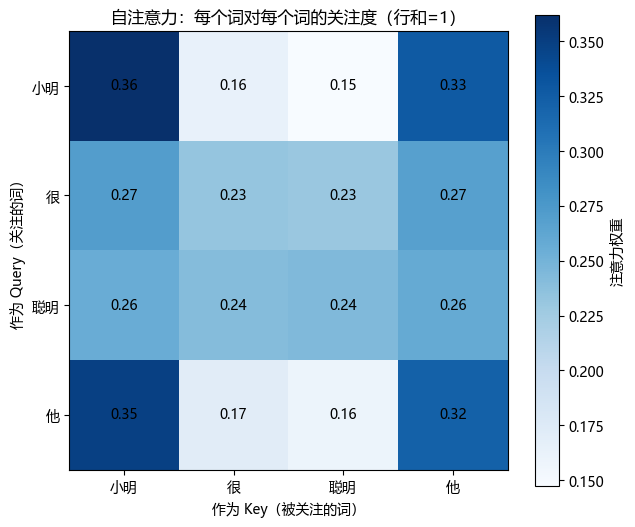

In [47]:
# ---- 自注意力演示：词与词之间的"关注"权重 ----
# 用 4 个"词"（每词一个 2 维向量）模拟一句话，算它们的自注意力权重。
np.random.seed(8)
词向量 = np.array([
    [1.0, 0.0],   # "小明"
    [0.2, 0.1],   # "很"
    [0.1, 0.2],   # "聪明"
    [0.9, 0.1],   # "他"
])
词名 = ['小明', '很', '聪明', '他']

# 简化：Q、K 都用词向量本身，先算 QKᵀ 相似度，再 softmax
相似度 = 词向量 @ 词向量.T            # 4×4 的相似度矩阵
注意力权重 = np.exp(相似度) / np.exp(相似度).sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(注意力权重, cmap='Blues')
ax.set_xticks(range(4)); ax.set_xticklabels(词名)
ax.set_yticks(range(4)); ax.set_yticklabels(词名)
ax.set_xlabel('作为 Key（被关注的词）'); ax.set_ylabel('作为 Query（关注的词）')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{注意力权重[i,j]:.2f}', ha='center', va='center',
                color='white' if 注意力权重[i, j] > 0.5 else 'black')
plt.colorbar(im, label='注意力权重')
ax.set_title('自注意力：每个词对每个词的关注度（行和=1）')
plt.tight_layout()
plt.show()

# 观察：第 4 行"他"这一行，对"小明"(第 1 列) 的注意力最高——
# 说明"他"最关注"小明"，两者被自动关联起来（这正是我们希望模型学到的指代关系）。


## 13.4 多头注意力（Multi-Head Attention）：多角度「关注」

如果只用**一组** Query/Key/Value，每个位置只能按**一种**「关注方式」去看全局——太单一。比如「他」既需要关注「指代的是谁」（小明），又需要关注「和哪个动词搭配」。

**多头注意力**的解决思路：**并行做多组（头）独立的注意力，每组用不同的 $W^Q, W^K, W^V$ 投影，最后把各头的输出拼起来**：

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O$$

- 每个「头」关注不同的方面（一个头关注指代、一个头关注语法、一个头关注语义……）；
- 拼接后让模型综合多个角度的信息；
- 类比：多个专家各看各的，最后把意见汇总。

> 💡 一句话：**单头 = 一种关注方式；多头 = 多种关注方式并行，再综合。** 这是 Transformer 表达力的重要来源。


## 13.5 位置编码：让 Transformer 知道「顺序」

注意力机制本身有一个**致命缺陷**：它**不知道输入的顺序**。因为「所有位置一起加权求和」，把句子里的词打乱顺序，注意力算出来的结果（如果不考虑位置）是**一模一样**的——可「我爱你」和「你爱我」意思完全不同！

解决办法是**位置编码（positional encoding）**：在输入进入网络之前，**给每个位置加一个「表示它是第几个」的向量**，让模型能区分「第一个词」和「第二个词」。

- 可以用「可学习的位置向量」（每个位置学一个向量）；
- 也可以用**固定的正弦/余弦函数**生成（原论文做法），好处是能外推到训练时没见过的更长序列。

> 💡 一句话：**注意力只负责「关注谁」，位置编码负责「记住顺序」，两者配合才能处理有顺序的序列（语言、时序）。**


## 13.6 Transformer 的完整结构：编码器 + 解码器

把前面的零件组装起来，就是 Transformer。它由**编码器（Encoder）**和**解码器（Decoder）**两部分堆叠而成：

**编码器**（把输入序列加工成「富含上下文的表示」），每一层包含：

1. **多头自注意力**：让每个词融合全局信息；
2. **前馈网络（FFN）**：一个小的全连接网络，对每个位置独立做非线性变换；
3. **残差连接 + 层归一化**：让训练稳定、梯度好传（第十二章的残差思想）。

**解码器**（根据编码结果逐步生成输出），除了上面两步，还多一个**「交叉注意力」**：解码时，每个位置去「关注」编码器的输出。

### 两种经典用法

- **只用编码器**：BERT——适合「理解」任务（分类、填空）；
- **只用解码器**：GPT——适合「生成」任务（续写、对话），当前主流大模型几乎都走这条路（第十九章详细讲）。

> 💡 一句话：**Transformer = 堆叠的「多头自注意力 + 前馈网络 + 残差」块**。所有现代大模型的骨架，都源自这里。


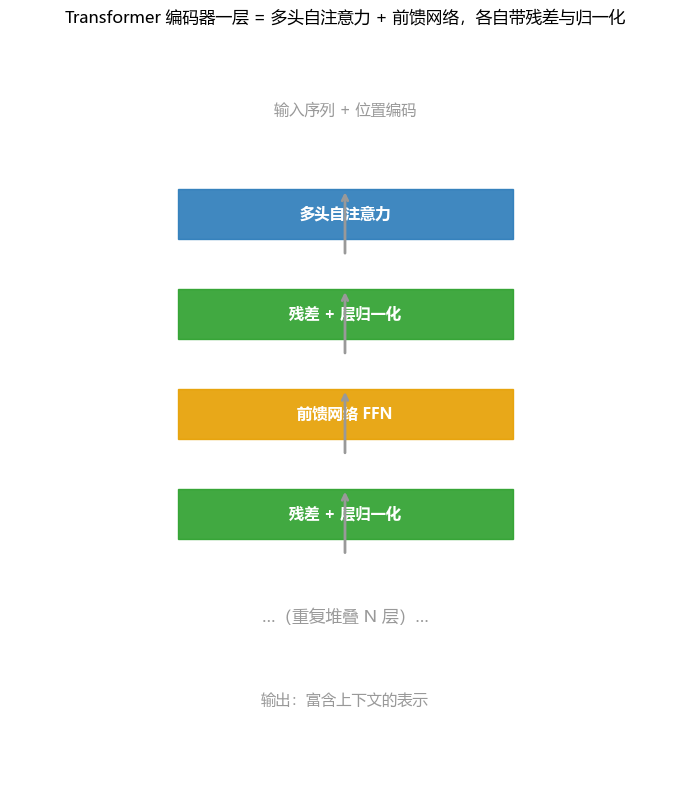

In [48]:
# ---- Transformer 编码器层结构可视化 ----
fig, ax = plt.subplots(figsize=(7, 8))

def 画块(ax, y, 名称, 颜色):
    ax.add_patch(plt.Rectangle((0.25, y), 0.5, 0.06, fill=True, color=颜色, alpha=0.9))
    ax.text(0.5, y + 0.03, 名称, ha='center', va='center', fontsize=11, color='white', weight='bold')

# 输入
ax.text(0.5, 0.95, '输入序列 + 位置编码', ha='center', fontsize=11, color=灰)
# 多头注意力
画块(ax, 0.80, '多头自注意力', 蓝)
# 残差+归一化
画块(ax, 0.68, '残差 + 层归一化', 绿)
# 前馈网络
画块(ax, 0.56, '前馈网络 FFN', 橙)
# 残差+归一化
画块(ax, 0.44, '残差 + 层归一化', 绿)

ax.annotate('', xy=(0.5, 0.86), xytext=(0.5, 0.78), arrowprops=dict(arrowstyle='->', color=灰, lw=2))
ax.annotate('', xy=(0.5, 0.74), xytext=(0.5, 0.66), arrowprops=dict(arrowstyle='->', color=灰, lw=2))
ax.annotate('', xy=(0.5, 0.62), xytext=(0.5, 0.54), arrowprops=dict(arrowstyle='->', color=灰, lw=2))
ax.annotate('', xy=(0.5, 0.50), xytext=(0.5, 0.42), arrowprops=dict(arrowstyle='->', color=灰, lw=2))

ax.text(0.5, 0.34, '…（重复堆叠 N 层）…', ha='center', fontsize=12, color=灰, style='italic')
ax.text(0.5, 0.24, '输出：富含上下文的表示', ha='center', fontsize=11, color=灰)

ax.set_xlim(0, 1); ax.set_ylim(0.15, 1.05)
ax.axis('off')
ax.set_title('Transformer 编码器一层 = 多头自注意力 + 前馈网络，各自带残差与归一化', fontsize=12)
plt.tight_layout()
plt.show()

# 记忆点：Transformer 的核心是"多头自注意力 + FFN + 残差"，重复堆叠很多层。


## 13.7 注意力评分函数：加性 vs 缩放点积（李沐 d2l 第 10 章）

> 📌 **出处**：李沐《动手学深度学习 V2》第 10 章「注意力评分函数」

13.2 讲的注意力用**点积**算 Query 和 Key 的相似度（「缩放点积注意力」）。但「相似度」有多种算法，统称**注意力评分函数** $a(\mathbf{q}, \mathbf{k})$。最常见两种：

**① 加性注意力（Additive Attention，Bahdanau）**

$$a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k})$$

把 query 和 key 各过一个线性层相加，再 $\tanh$，最后用向量 $\mathbf{w}_v$ 打成分数。**query 和 key 维度可以不同**，适合序列到序列场景。

**② 缩放点积注意力（Scaled Dot-Product Attention）**

$$a(\mathbf{q}, \mathbf{k}) = \frac{\mathbf{q} \cdot \mathbf{k}}{\sqrt{d}}$$

直接点积，再除以 $\sqrt{d}$（$d$ 是维度）防止维度大时点积值过大、softmax 后梯度消失。**计算高效（矩阵乘法），是 Transformer 的选择**。

> 💡 **记忆**：**加性注意力 = 线性 + tanh + 打分**（灵活，维度可不同）；**缩放点积 = q·k/√d**（快，Transformer 用）。除 $\sqrt{d}$ 是关键——不除的话大维度下 softmax 会饱和。

## 13.8 注意力在 seq2seq 中的应用：Bahdanau 注意力（李沐 d2l 第 10 章）

> 📌 **出处**：李沐《动手学深度学习 V2》第 10 章「Bahdanau 注意力」

第二十一章的 seq2seq 有个缺陷：解码器每一步只能用编码器**最后一个**隐藏状态，句子一长信息就「挤爆」。**Bahdanau 注意力**让解码器每一步都能「回看」编码器的**所有**位置：

- 解码器当前状态 $\mathbf{q}$ 当 Query，编码器每个位置输出 $\mathbf{k}_i$ 当 Key；
- 用**加性注意力**算出每个位置的相关分数 → softmax → 得到「该关注编码器哪些位置」的权重；
- 加权求和编码器的 Value，得到**上下文向量**，拼进解码器的输入。

效果：解码「翻译第 i 个词」时能自动对齐到源句里最相关的位置——**对齐（alignment）**。这是机器翻译的巨大进步，也是 Transformer「交叉注意力」的前身。


## 13.9 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 注意力 | 每个位置直接加权关注全局，权重由数据算出 |
| Q / K / V | 查询 / 键 / 值：点积算相似度 → softmax → 加权求和 |
| 自注意力 | 序列内部互相看，自动捕捉全局依赖 |
| 多头注意力 | 多组注意力并行，多角度关注再综合 |
| 位置编码 | 补上注意力丢失的「顺序」信息 |
| Transformer | 堆叠的「多头注意力 + FFN + 残差」块 |

🔑 **记忆**：注意力公式 $\text{softmax}(QK^\top/\sqrt{d_k})V$；「缩放点积注意力」是核心；多头 = 多角度；位置编码负责顺序；GPT 用解码器、BERT 用编码器。

> 📌 **下一步**：第十四章进入 **PyTorch 实战**（40 天计划补充）——把前面所有概念（张量、自动求导、反向传播）用 PyTorch 真正落地。


# 第十四章 PyTorch 基础：Tensor 与 Autograd

> 📌 **出处**：⭐ **40 天计划补充**（计划 Day15「PyTorch 基础」）。课程主线到第十三章结束，从这一章起进入 **PyTorch 实战**——把前面学到的「张量、自动求导、反向传播」用工业界最主流的框架真正落地。
> 🎓 **推荐配套**：李沐《动手学深度学习》PyTorch 版（B 站 BV1EY6FBwE8P）第 2~4 章。

---

## 14.1 为什么需要 PyTorch？

前面几章我们都是用 numpy 手写梯度、手写反向传播。这在「两层网络、4 个样本」时还行，但一到**几百层的网络、几百万参数**，手写就完全不可行了。

**PyTorch** 是 Facebook（现 Meta）开源的深度学习框架，它帮我们解决两件最麻烦的事：

1. **自动求导（autograd）**：只要用 PyTorch 定义好「前向计算」，它会**自动算出所有参数的梯度**（第十一章手写的反向传播，它内部全自动做掉了）；
2. **GPU 加速**：张量（Tensor）可以在 GPU 上做海量并行运算，训练大模型快成百上千倍。

> 💡 一句话：**numpy 是「科学计算」，PyTorch 是「能自动求导、能上 GPU 的科学计算」。** 它们的 API 非常像，学起来会很顺。


In [49]:
# ---- PyTorch 环境准备 ----
import torch
import numpy as np

print("PyTorch 版本：", torch.__version__)
# 检测是否有 GPU（没有就退回 CPU）
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("使用的设备：", device, "（GPU 可用：", torch.cuda.is_available(), "）")
# 注：本机是 CPU 版 PyTorch，所有代码仍可正常运行，只是没有 GPU 加速。


PyTorch 版本： 2.14.0+cpu
使用的设备： cpu （GPU 可用： False ）


## 14.2 Tensor（张量）：PyTorch 的「numpy 数组」

**Tensor（张量）** 是 PyTorch 的核心数据结构，可以理解成「能上 GPU、能自动求导的 numpy 数组」。

- **标量** = 0 维张量；**向量** = 1 维张量；**矩阵** = 2 维张量；更高维的统称张量；
- 图像是 `(通道, 高, 宽)` 的 3 维张量，一批图像是 `(批量, 通道, 高, 宽)` 的 4 维张量。

创建张量的常用方式（和 numpy 一一对应）：

| numpy | PyTorch | 说明 |
| --- | --- | --- |
| `np.array(...)` | `torch.tensor(...)` | 从列表创建 |
| `np.zeros / ones` | `torch.zeros / ones` | 全 0 / 全 1 |
| `np.arange(n)` | `torch.arange(n)` | 等差序列 |
| `np.random.rand` | `torch.rand` | [0,1) 均匀随机 |
| `np.random.randn` | `torch.randn` | 标准正态随机 |


In [50]:
# ---- Tensor 基本操作：创建、属性、索引、运算 ----
# ① 创建张量
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
print("张量 a：\n", a)
print("形状 a.shape：", a.shape, "   维度 a.dim()：", a.dim(), "   元素个数 a.numel()：", a.numel())
print("数据类型 a.dtype：", a.dtype, "   所在设备 a.device：", a.device, "\n")

# ② 索引与切片（和 numpy 一样）
print("a[0, 1] =", a[0, 1].item(), "   # .item() 把标量张量取成 Python 数字")
print("a[:, 1] =", a[:, 1], "   # 取第 2 列\n")

# ③ 运算（和 numpy 一样）
b = torch.ones(2, 3)
print("a + b = \n", a + b)
print("a * b = \n", a * b, "   # 逐元素乘（不是矩阵乘！）")
print("a @ b.T = \n", a @ b.T, "   # @ 才是矩阵乘法\n")

# ④ 常用函数
print("a.sum() =", a.sum().item(), "   a.mean() =", a.mean().item(), "   a.max() =", a.max().item())


张量 a：
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
形状 a.shape： torch.Size([2, 3])    维度 a.dim()： 2    元素个数 a.numel()： 6
数据类型 a.dtype： torch.float32    所在设备 a.device： cpu 

a[0, 1] = 2.0    # .item() 把标量张量取成 Python 数字
a[:, 1] = tensor([2., 5.])    # 取第 2 列

a + b = 
 tensor([[2., 3., 4.],
        [5., 6., 7.]])
a * b = 
 tensor([[1., 2., 3.],
        [4., 5., 6.]])    # 逐元素乘（不是矩阵乘！）
a @ b.T = 
 tensor([[ 6.,  6.],
        [15., 15.]])    # @ 才是矩阵乘法

a.sum() = 21.0    a.mean() = 3.5    a.max() = 6.0


In [51]:
# ---- Tensor 与 numpy 互转、以及搬上 GPU ----
# ① Tensor → numpy（共享内存，改一个另一个也变，注意！）
t = torch.tensor([1.0, 2.0, 3.0])
n = t.numpy()
print("Tensor → numpy：", n, type(n))

# ② numpy → Tensor
n2 = np.array([4.0, 5.0, 6.0])
t2 = torch.from_numpy(n2)
print("numpy → Tensor：", t2, type(t2), "\n")

# ③ 搬上 GPU（本机无 GPU，代码仍写出正确写法，运行会自动退回 CPU）
x = torch.randn(3, 3)
x_gpu = x.to(device)     # .to(device) 把张量搬到指定设备
print("搬到设备后：", x_gpu.device, "（本机为 CPU）")

# ④ 修改形状：reshape / view
y = torch.arange(12)
print("reshape 成 3×4：\n", y.reshape(3, 4))


Tensor → numpy： [1. 2. 3.] <class 'numpy.ndarray'>
numpy → Tensor： tensor([4., 5., 6.], dtype=torch.float64) <class 'torch.Tensor'> 

搬到设备后： cpu （本机为 CPU）
reshape 成 3×4：
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


## 14.3 Autograd（自动求导）：PyTorch 的「反向传播引擎」

这是 PyTorch 最核心、也最该**吃透**的功能。回忆第十一章：我们手写了「前向传播 + 反向传播」来算梯度。**PyTorch 的 autograd 会自动完成反向传播**，只要三步：

1. **标记要跟踪的参数**：创建张量时设 `requires_grad=True`；
2. **前向计算**：正常写运算，PyTorch 会在后台**悄悄记录一张「计算图」**；
3. **`.backward()` 求梯度**：调用一次，PyTorch 自动沿计算图反向算出所有参数的梯度，存到各张量的 `.grad` 属性里。

### 原理：一张「计算图」

PyTorch 在你做每个运算时，都把「输入是谁、做了什么运算」记下来，形成一张**有向无环图（DAG）**。`.backward()` 就是沿这张图**从损失出发、用链式法则一路反推**——这正是第十一章「反向传播」的自动化版本。

> 🔑 **记忆**：`requires_grad=True` 标记参数 → 前向计算（自动建图）→ `loss.backward()` 自动求梯度 → 梯度在 `x.grad` 里。


In [52]:
# ---- Autograd 演示：自动求导，对比手算 ----
# 用 y = x² 在 x=3 处的导数，验证 autograd 算得对不对。
x = torch.tensor(3.0, requires_grad=True)   # ① 标记要跟踪梯度

y = x ** 2                                   # ② 前向计算（PyTorch 悄悄建图）
y.backward()                                 # ③ 反向传播，自动求梯度

print(f"y = x²，在 x=3 处的导数 dy/dx = 2x = 6")
print(f"autograd 算得 x.grad = {x.grad.item()}  ✅ 正确")

# 再来一个多步的：y = (x² + 3x)²，验证链式法则
x2 = torch.tensor(2.0, requires_grad=True)
z = x2 ** 2 + 3 * x2
y2 = z ** 2
y2.backward()
# 手算：dy/dx = 2(x²+3x)·(2x+3)，x=2 时 = 2·(4+6)·(4+3) = 140
print(f"\ny = (x²+3x)²，x=2 时手算 dy/dx = 2·10·7 = 140")
print(f"autograd 算得 x2.grad = {x2.grad.item()}  ✅ 自动完成了链式法则")


y = x²，在 x=3 处的导数 dy/dx = 2x = 6
autograd 算得 x.grad = 6.0  ✅ 正确

y = (x²+3x)²，x=2 时手算 dy/dx = 2·10·7 = 140
autograd 算得 x2.grad = 140.0  ✅ 自动完成了链式法则


In [53]:
# ---- Autograd 与第十一章手写反向传播的对应 ----
# 把第十一章"两层网络反向传播"用 autograd 重写，体会它省了多少事。
def sigmoid_t(z):
    return 1 / (1 + torch.exp(-z))

# 同样的单个样本：x=0.6, y=1.0
x = torch.tensor(0.6)
y = torch.tensor(1.0)

# 参数：requires_grad=True 让 PyTorch 跟踪它们
w1 = torch.tensor(0.5, requires_grad=True)
b1 = torch.tensor(-0.3, requires_grad=True)
w2 = torch.tensor(0.2, requires_grad=True)
b2 = torch.tensor(0.1, requires_grad=True)

# 前向传播（和第十一章一模一样，但不用手写反向）
z1 = w1 * x + b1
a1 = sigmoid_t(z1)
y_hat = w2 * a1 + b2
L = 0.5 * (y_hat - y) ** 2

# 一句话自动求所有梯度！
L.backward()

print("第十一章手写反向传播算出的梯度 vs autograd 自动算的梯度：")
print(f"  ∂L/∂w1：手写 -0.0240 vs autograd {w1.grad.item():.4f}")
print(f"  ∂L/∂w2：手写 -0.4000 vs autograd {w2.grad.item():.4f}")
print(f"  ∂L/∂b1：手写 -0.0400 vs autograd {b1.grad.item():.4f}")
print(f"  ∂L/∂b2：手写 -0.8000 vs autograd {b2.grad.item():.4f}")
print("两者一致 → autograd 就是自动化的反向传播 ✅")


第十一章手写反向传播算出的梯度 vs autograd 自动算的梯度：
  ∂L/∂w1：手写 -0.0240 vs autograd -0.0240
  ∂L/∂w2：手写 -0.4000 vs autograd -0.4000
  ∂L/∂b1：手写 -0.0400 vs autograd -0.0400
  ∂L/∂b2：手写 -0.8000 vs autograd -0.8000
两者一致 → autograd 就是自动化的反向传播 ✅


## 14.4 Autograd 的三个关键细节

### ① 梯度会「累加」，要记得清零

默认情况下，每次 `.backward()` 得到的梯度会**累加**到 `.grad` 上（而不是覆盖）。所以每个训练步之前，要手动把梯度清零。两种写法：

- 优化器方式：`optimizer.zero_grad()`（第十六章会讲优化器）；
- 手动方式：`param.grad.zero_()` 或 `param.grad = None`。

### ② 不需要梯度的计算，要「关掉」它

预测、评估模型时，我们**只算前向、不算梯度**。若还开着梯度跟踪，会白耗内存和算力。两种关法：

- `torch.no_grad()` 上下文：`with torch.no_grad():` 块里的计算不建图；
- `x.detach()`：把张量从计算图里「摘」出来，得到不跟踪梯度的副本。

### ③ 计算图默认「用完即弃」

`.backward()` 之后，中间的计算图会被释放以省内存。所以**不能对同一个计算结果重复调用 `.backward()`**（除非设 `retain_graph=True`）。


In [54]:
# ---- Autograd 的三个细节演示 ----
# ① 梯度累加问题
x = torch.tensor(2.0, requires_grad=True)
for i in range(3):
    y = x ** 2
    y.backward()
    print(f"第 {i+1} 次 backward 后 x.grad = {x.grad.item()}（在累加！）")

print("\n正确做法：每次 backward 前清零")
x2 = torch.tensor(2.0, requires_grad=True)
for i in range(3):
    if x2.grad is not None:
        x2.grad.zero_()          # 清零
    y = x2 ** 2
    y.backward()
    print(f"  第 {i+1} 次：x2.grad = {x2.grad.item()}（恒为 4，不再累加）")

# ② 用 no_grad 关闭梯度跟踪（预测时用）
x3 = torch.tensor(3.0, requires_grad=True)
with torch.no_grad():
    y3 = x3 ** 2
print(f"\nno_grad 块里的计算结果 requires_grad = {y3.requires_grad}（False = 不跟踪）")


第 1 次 backward 后 x.grad = 4.0（在累加！）
第 2 次 backward 后 x.grad = 8.0（在累加！）
第 3 次 backward 后 x.grad = 12.0（在累加！）

正确做法：每次 backward 前清零
  第 1 次：x2.grad = 4.0（恒为 4，不再累加）
  第 2 次：x2.grad = 4.0（恒为 4，不再累加）
  第 3 次：x2.grad = 4.0（恒为 4，不再累加）

no_grad 块里的计算结果 requires_grad = False（False = 不跟踪）


## 14.5 【李沐 d2l】预备知识 · 线性代数：张量的矩阵运算

> 📌 **出处**：李沐《动手学深度学习 V2》第 2 章「线性代数」

深度学习里张量（Tensor）的运算本质就是**线性代数**。几个高频操作：

```python
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)  # 5×4 矩阵
A @ A.T           # 矩阵乘（@ 是矩阵乘法）
A.sum()           # 所有元素求和
A.sum(axis=0)     # 沿第 0 维压缩（结果行数变 1），常用来求每列统计量
A.mean(axis=1)    # 沿第 1 维求均值
torch.norm(A)     # L2 范数（所有元素平方和开根号）
```

> 🔑 **记忆**：
> - `@` 是**矩阵乘法**，`*` 是**逐元素相乘**（两者别搞混）；
> - `sum(axis=0)` 是「沿行方向压缩」，把行数压成 1，常用来求每列的均值/方差（例如后面 BatchNorm 会用到）；
> - 张量的「形状 shape」就是线性代数里的「维度」，`reshape` 只是换个视角、不改变数据。


## 14.6 【李沐 d2l】预备知识 · 概率：从分布里抽样

> 📌 **出处**：李沐《动手学深度学习 V2》第 2 章「概率」

机器学习处理的是**不确定性**，概率是它的语言。用 torch 从不同分布抽样：

```python
torch.normal(mean=0, std=1, size=(3, 4))  # 正态分布抽样（最常用）
torch.rand(2, 3)                           # [0,1) 均匀分布
torch.randint(0, 10, (2, 3))              # 整数均匀分布
```

> 🔑 **记忆**：
> - 初始化网络权重常用 `torch.normal(0, 0.01, ...)`（小方差正态，避免一开始就饱和）；
> - 「训练 = 从数据分布里学规律」：模型要拟合的是数据的**概率分布**，而不只是背下每个样本；
> - 概率论三件套——**概率质量函数（离散）/ 概率密度函数（连续）/ 条件概率**，是后面所有损失函数（交叉熵等）的数学地基。


## 14.7 【李沐 d2l】预备知识 · 数据预处理与查阅文档

> 📌 **出处**：李沐《动手学深度学习 V2》第 2 章「数据预处理 / 查阅文档」

- **数据预处理**：用 `pandas.read_csv()` 读表格数据、处理缺失值（删除 / 插值）——本笔记第 7 章已系统展开；
- **查阅文档**：遇到不认识的 API，用 `dir(对象)` 看有哪些方法、`help(函数)` 看说明。这是李沐反复强调的「会查文档」基本功。

> 💡 预备知识总结：**数据操作（Tensor）+ 线性代数 + 微积分（自动求导）+ 概率**，四块拼成深度学习的数学地基，后面所有章节都是在这四块上盖楼。


## 14.8 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| Tensor | 能上 GPU、能自动求导的「numpy 数组」 |
| 创建/索引/运算 | 和 numpy 几乎一样（`@` 是矩阵乘） |
| requires_grad | 标记要跟踪梯度的参数 |
| 计算图 | PyTorch 前向时偷偷记录，反向时沿它求导 |
| backward | 一句话自动算出所有参数的梯度 |
| 梯度清零 | 梯度默认累加，每步要 `zero_grad()` |

🔑 **记忆**：三步曲 = `requires_grad=True` → 前向算 loss → `loss.backward()`；梯度在 `.grad` 里，训练每步前要清零；预测用 `torch.no_grad()`。

> 📌 **下一步**：第十五章讲**数据加载与数据增强**——用 `Dataset` / `DataLoader` 高效喂数据，并学会扩充数据、抑制过拟合。


# 第十五章 数据加载与数据增强

> 📌 **出处**：⭐ **40 天计划补充**（计划 Day15「PyTorch 基础：DataLoader」、Day17「数据增强」）。上一章学了 Tensor 和 autograd，这一章解决「**怎么高效地把数据喂给模型**」和「**数据不够怎么造**」两个问题。
> 🎓 **推荐配套**：李沐《动手学深度学习》PyTorch 版第 3~4 章。

---

## 15.1 为什么需要 Dataset 和 DataLoader？

训练时数据可能有几十万条，不能一次全塞进内存，也不能一条条手动喂。PyTorch 用两个组件分工解决：

- **`Dataset`（数据集）**：定义「**数据从哪来、怎么读取一条**」——它只负责「第 i 条数据是什么」，不管批量；
- **`DataLoader`（数据加载器）**：把 Dataset 包装起来，负责「**自动分批（batch）、打乱（shuffle）、并行加载（num_workers）**」，把一批批数据送到训练循环。

这个「Dataset 管单条、DataLoader 管批量」的分工，是 PyTorch 最优雅的设计之一。

> 💡 一句话：**Dataset 回答「单条数据怎么取」，DataLoader 回答「怎么打包成一批批高效喂给模型」。**


In [55]:
# ---- 自定义 Dataset：把「数据 + 标签」组织起来 ----
from torch.utils.data import Dataset, DataLoader

# 自定义一个数据集：继承 Dataset，实现 __len__ 和 __getitem__ 两个方法
class 线性数据集(Dataset):
    """生成 y = 3x + 2 + 噪声 的 100 条数据。"""
    def __init__(self, n=100):
        torch.manual_seed(42)
        self.x = torch.rand(n, 1) * 10            # 输入 x ∈ [0, 10)
        self.y = 3.0 * self.x + 2.0 + torch.randn(n, 1) * 0.5   # 真实关系 + 噪声

    def __len__(self):
        return len(self.x)                        # 数据集有多大

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]           # 返回第 idx 条 (输入, 标签)

ds = 线性数据集(100)
print("数据集大小：", len(ds))
print("第 0 条数据：(x, y) =", ds[0][0].item(), ",", ds[0][1].item(), "\n")

# DataLoader 打包：每批 16 条、打乱、用 0 个额外进程
loader = DataLoader(ds, batch_size=16, shuffle=True, num_workers=0)

print("DataLoader 遍历一个 batch：")
for 批x, 批y in loader:
    print("  x 形状：", 批x.shape, "  y 形状：", 批y.shape, "（16 条 × 1 维）")
    break


数据集大小： 100
第 0 条数据：(x, y) = 8.82269287109375 , 28.788455963134766 

DataLoader 遍历一个 batch：
  x 形状： torch.Size([16, 1])   y 形状： torch.Size([16, 1]) （16 条 × 1 维）


## 15.2 DataLoader 的三个关键参数

- **`batch_size`**：每批多少条。太小训练慢、太大会爆内存，常见 32/64/128（呼应第六章）；
- **`shuffle=True`**：每个 epoch 随机打乱顺序。**训练时一定要 True**（防止模型记住数据顺序），验证/测试时 False；
- **`num_workers`**：用几个子进程并行读数据。CPU 加载慢时可以调大（如 4），但 Windows 上常设 0 避免多进程问题。

还有一个容易忽略的点：**`drop_last=True`** 会在「最后一批不足 batch_size」时丢弃它，避免最后一批形状不一致导致某些操作报错。

> 💡 一个 epoch = 把整个数据集完整过一遍（`shuffle=True` 时每轮顺序都不同）。训练通常要跑很多个 epoch。


## 15.3 数据增强：数据不够，就「无中生有」

**数据增强（Data Augmentation）** 是抑制过拟合（第八章）的一大利器，尤其对**图像**。核心思想：**对已有训练样本做「合理的小变形」，制造新的训练样本**。

为什么有效？第八章说过拟合的根源是「模型记住了训练数据」。数据增强让模型每次看到「同一张图的不同样子」，它就没法去死记原图，被迫学到**真正的、变换不变的本质特征**——猫翻转了还是猫，模型必须认出来。

常见图像增强（`torchvision.transforms` 里都有）：

| 增强 | 效果 | 说明 |
| --- | --- | --- |
| `RandomHorizontalFlip` | 随机水平翻转 | 猫脸朝左朝右都是猫 |
| `RandomRotation` | 随机旋转 | 旋转 ±N 度 |
| `RandomCrop` | 随机裁剪 | 裁出一块再缩放 |
| `ColorJitter` | 随机调亮度/对比度/饱和度 | 模拟不同光照 |
| `RandomResizedCrop` | 随机缩放再裁剪 | 模拟不同距离/构图 |
| `Normalize` | 标准化 | 让像素均值 0、方差 1（配合缩放） |

> 💡 关键：增强**只在训练时用**，测试时只用「缩放 + 归一化」这些确定性的变换（不做随机变形）。


In [56]:
# ---- 数据增强演示：同一张图的不同"增强"版本 ----
from PIL import Image
from torchvision import transforms

# 造一张简单的"测试图"：左上画一个圆、右下画一个方块
img_arr = np.zeros((80, 80, 3), dtype=np.uint8)
img_arr[5:35, 5:35] = [255, 100, 100]        # 左上：红色方块
yy, xx = np.ogrid[:30, :30]
circle = (xx - 15) ** 2 + (yy - 15) ** 2 <= 14 ** 2
img_arr[45:75, 45:75][circle] = [100, 150, 255]   # 右下：蓝色圆
原图 = Image.fromarray(img_arr)

# 定义一组增强变换（每个都是"随机"的）
增强组 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),      # 一定水平翻转
    transforms.RandomRotation(degrees=30),       # 随机旋转 ±30°
    transforms.ColorJitter(brightness=0.5, contrast=0.5),  # 随机亮度/对比度
    transforms.RandomResizedCrop(size=80, scale=(0.7, 1.0)),  # 随机缩放裁剪
])

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
axes[0].imshow(原图); axes[0].set_title('原图'); axes[0].axis('off')
for ax in axes[1:]:
    增强图 = 增强组(原图)          # 每次调用产生不同的随机结果
    ax.imshow(增强图); ax.set_title('数据增强后'); ax.axis('off')
plt.suptitle('数据增强：同一张图，随机生成多种"合法变形"', fontsize=13)
plt.tight_layout()
plt.show()

# 观察：翻转、旋转、变色、缩放裁剪，让模型学到"变换不变"的本质特征。


ModuleNotFoundError: No module named 'torchvision'

## 15.4 图像数据的标准流水线：transform 组合

实际处理图像时，会把「增强 + 预处理」组合成一个 `transforms.Compose` 流水线，训练集和测试集用**不同的** transform：

```python
# 训练集：随机增强 + 转张量 + 归一化
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),               # PIL图/H×W×C → 张量 C×H×W，且缩到 [0,1]
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),  # 标准化到 [-1,1]
])

# 测试集：只做确定的变换
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])
```

两个要点：

- **`ToTensor()`**：把 `PIL` 图像或 numpy 数组转成 PyTorch 张量，并**自动把像素从 [0,255] 缩到 [0,1]**、把形状从 `H×W×C` 变成 `C×H×W`（PyTorch 卷积要求通道在前）；
- **`Normalize(mean, std)`**：对每个通道做 $(x - \text{mean})/\text{std}$，把数据缩到利于训练的范围（呼应第七章的 Z-Score 标准化）。

> 💡 这些就是标准套路，训练图像模型时基本照搬即可。


## 15.5 【李沐 d2l】图像增广：翻转、裁剪、颜色抖动

> 📌 **出处**：李沐《动手学深度学习 V2》第 13 章「图像增广」
> 📎 **完整可运行代码**：`实战代码_李沐/图像增广与微调.ipynb`

15.3 讲了「数据不够就无中生有」的直觉，这里补 d2l 的**具体做法**。图像增广就是**对训练图片做随机扰动**，让模型见过更多「变体」，本质是一种**正则化**（抑制过拟合）。torchvision 提供三大类：

| 增广 | 函数 | 作用 |
| --- | --- | --- |
| 翻转 | `RandomHorizontalFlip` / `RandomVerticalFlip` | 左右/上下镜像（猫反过来还是猫） |
| 裁剪 | `RandomResizedCrop` / `RandomCrop` | 随机裁剪一块再放大（平移/尺度不变性） |
| 颜色 | `ColorJitter(brightness, contrast, saturation, hue)` | 随机调亮度/对比度/饱和度/色调 |

> 🔑 **记忆**：增广只用在**训练集**（测试集要原图评估），常用「随机翻转 + 随机裁剪 + 颜色抖动」组合。增广 = 免费的数据，是小数据集训练的标配。


## 15.6 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| Dataset | 定义「第 i 条数据怎么取」，实现 `__len__`/`__getitem__` |
| DataLoader | 自动分批、打乱、并行加载 |
| batch_size / shuffle | 每批条数 / 训练时是否打乱 |
| 数据增强 | 对训练样本做随机变形，制造新样本、抑制过拟合 |
| ToTensor / Normalize | 转张量并缩到 [0,1] / 标准化到均值 0 方差 1 |

🔑 **记忆**：Dataset 管单条、DataLoader 管批量；训练集增强（随机变形）、测试集只用确定性预处理；`ToTensor` 自动缩像素并转成 `C×H×W`。

> 📌 **下一步**：第十六章讲**标准训练循环与模型搭建**——用 `nn.Module` 定义网络、`nn.Linear`/`nn.ReLU` 搭层，写出工业级训练循环（含优化器、checkpoint）。


# 第十六章 模型搭建与标准训练循环

> 📌 **出处**：⭐ **40 天计划补充**（计划 Day15「PyTorch 基础：nn.Module、训练循环」、Day17「checkpoint」）。前两章学了 Tensor、autograd、DataLoader，这一章把它们组装成**一个真正能跑的完整模型**，写出工业级标准的训练循环。
> 🎓 **推荐配套**：李沐《动手学深度学习》PyTorch 版第 4~6 章。

---

## 16.1 用 nn.Module 定义模型

前面（第十一、十四章）我们都是「手动管理参数 $w, b$」。真实项目里，用 PyTorch 的 **`nn.Module`** 来组织模型，好处是：**自动管理参数、能打印结构、能一键迁移到 GPU、能保存加载**。

定义模型的两个要点：

1. **继承 `nn.Module`**；
2. 在 `__init__` 里定义层，在 `forward` 里写「前向计算」（输入怎么一层层变成输出）。

`forward` 定义好之后，PyTorch 会自动为它建计算图、支持反向传播。


In [ ]:
# ---- nn.Module 定义一个多层感知机 MLP ----
import torch.nn as nn

class 简单MLP(nn.Module):
    """三层 MLP：输入 → 隐藏(ReLU) → 隐藏(ReLU) → 输出。"""
    def __init__(self, 输入维度, 隐藏维度, 输出维度):
        super().__init__()
        self.层1 = nn.Linear(输入维度, 隐藏维度)   # 线性层：z = Wx + b
        self.层2 = nn.Linear(隐藏维度, 隐藏维度)
        self.层3 = nn.Linear(隐藏维度, 输出维度)
        self.relu = nn.ReLU()                      # 激活函数（可复用）

    def forward(self, x):
        x = self.relu(self.层1(x))                 # 线性 → 激活
        x = self.relu(self.层2(x))
        x = self.层3(x)                            # 输出层不做激活（回归）
        return x

model = 简单MLP(输入维度=2, 隐藏维度=8, 输出维度=1)
print(model)          # 打印模型结构
print("\n模型参数量：", sum(p.numel() for p in model.parameters()))

# 试跑一次前向
x = torch.randn(4, 2)      # 4 个样本、2 个特征
y = model(x)
print("输入形状", x.shape, "→ 输出形状", y.shape)


## 16.2 常用层：nn.Linear、激活函数、nn.Sequential

| 层 | 作用 | 说明 |
| --- | --- | --- |
| `nn.Linear(in, out)` | 全连接层 $y = Wx + b$ | 权重 $W$ 和偏置 $b$ 自动注册为参数 |
| `nn.ReLU()` | ReLU 激活 | `max(0, x)` |
| `nn.Sigmoid()` | sigmoid | 压到 (0,1) |
| `nn.Dropout(p)` | Dropout（第八章） | 训练时随机丢弃，测试自动关闭 |
| `nn.Conv2d(...)` | 卷积层（第十二章） | 图像特征提取 |
| `nn.MaxPool2d(...)` | 最大池化（第十二章） | 下采样 |

如果网络是**顺序的一串层**，可以用 **`nn.Sequential`** 写得更简洁：

```python
model = nn.Sequential(
    nn.Linear(2, 8), nn.ReLU(),
    nn.Linear(8, 8), nn.ReLU(),
    nn.Linear(8, 1),
)
```

> 💡 `nn.Module` 适合复杂结构（有分支、跳跃连接），`nn.Sequential` 适合简单顺序结构。两者都能打印、训练、保存。


## 16.3 损失函数与优化器：nn 和 optim 全家桶

PyTorch 把第十章「损失函数」和第六章「优化器」都封装好了：

**损失函数（`torch.nn`）**：

- `nn.MSELoss()`：均方误差，回归用；
- `nn.L1Loss()`：平均绝对误差 MAE，抗离群点；
- `nn.CrossEntropyLoss()`：交叉熵，分类用（**注意：它内部已包含 softmax**，所以模型最后一层不要再加 softmax）；
- `nn.BCEWithLogitsLoss()`：二分类交叉熵（内部含 sigmoid）。

**优化器（`torch.optim`）**：

- `optim.SGD(params, lr, momentum=0.9)`：小批量梯度下降，可加动量；
- `optim.Adam(params, lr=0.001)`：Adam（第六章），默认首选；
- 都支持 `weight_decay` 参数 = 第八章的 **L2 权重衰减**。

> 🔑 **记忆**：分类用 `CrossEntropyLoss`（自带 softmax），回归用 `MSELoss`；优化器默认 `Adam`；`weight_decay` = L2 正则。


In [ ]:
# ---- 损失函数 + 优化器的使用 ----
import torch.optim as optim

# 造一个小例子：多分类（3 类）
logits = torch.randn(2, 3)               # 2 个样本，每个输出 3 个"分数"（未过 softmax）
target = torch.tensor([0, 2])            # 真实类别

ce = nn.CrossEntropyLoss()               # 交叉熵（内部自动 softmax）
loss = ce(logits, target)
print("交叉熵损失 =", loss.item(), "（CrossEntropyLoss 内部已含 softmax）")

# 回归例子：MSE
mse = nn.MSELoss()
pred = torch.tensor([1.0, 2.0, 3.0]); true = torch.tensor([1.5, 2.5, 2.5])
print("MSE 损失 =", mse(pred, true).item(), "\n")

# 优化器：把模型参数交给它
model2 = 简单MLP(2, 8, 1)
opt_sgd = optim.SGD(model2.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
opt_adam = optim.Adam(model2.parameters(), lr=0.001)
print("SGD 优化器（含动量 + L2 权重衰减）：", opt_sgd)
print("Adam 优化器：", opt_adam)


## 16.4 标准训练循环（五段式模板）

把前面所有零件串起来，就是一个**工业级标准训练循环**。它的骨架（🔑 要背下来）：

```python
for epoch in range(总轮数):
    # ---------- 训练阶段 ----------
    model.train()                              # 打开训练模式（Dropout 生效）
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)      # 搬上 GPU
        optimizer.zero_grad()                  # ① 清零梯度
        pred = model(x)                        # ② 前向
        loss = criterion(pred, y)              # ③ 算损失
        loss.backward()                        # ④ 反向求梯度
        optimizer.step()                       # ⑤ 更新参数

    # ---------- 验证阶段 ----------
    model.eval()                               # 打开评估模式（Dropout 关闭）
    with torch.no_grad():                      # 不跟踪梯度，省内存
        for x, y in valid_loader:
            pred = model(x)
            # 累积验证损失 / 准确率
```

五个核心动作的顺序绝不能乱：**`zero_grad → forward → loss → backward → step`**。

- `model.train()` / `model.eval()` 切换模式，影响 Dropout、BatchNorm 等层的表现；
- `torch.no_grad()` 关掉验证时的梯度计算，提速省内存。

下面的代码用回归问题完整跑一遍，并加上**早停 + 保存最优 checkpoint**（第八章的早停、checkpoint 落到代码）。


In [ ]:
# ---- 完整训练循环：回归 + 早停 + 保存最优模型 ----
from torch.utils.data import DataLoader, TensorDataset

# 造数据：y = 3x + 2 + 噪声（x ∈ [0,10]）
torch.manual_seed(0)
X = torch.rand(800, 1) * 10
y = 3.0 * X + 2.0 + torch.randn(800, 1) * 1.5

# 划分：训练 600 / 验证 200
X_train, X_valid = X[:600], X[600:]
y_train, y_valid = y[:600], y[600:]

# TensorDataset 直接把 (x, y) 包成 Dataset
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid, y_valid), batch_size=128, shuffle=False)

model = 简单MLP(1, 32, 1)                    # 1 输入 → 32 隐藏 → 1 输出
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

train_losses, valid_losses = [], []
最佳验证损失 = float('inf')
早停计数 = 0

for epoch in range(200):
    # ---- 训练 ----
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()                 # ① 清零
        pred = model(xb)                      # ② 前向
        loss = criterion(pred, yb)            # ③ 损失
        loss.backward()                       # ④ 反向
        optimizer.step()                      # ⑤ 更新

    # ---- 验证 ----
    model.eval()
    with torch.no_grad():
        总损失 = sum(criterion(model(xb), yb).item() for xb, yb in valid_loader)
        验证损失 = 总损失 / len(valid_loader)
    train_losses.append(loss.item())
    valid_losses.append(验证损失)

    # ---- 早停 + 保存最优 ----
    if 验证损失 < 最佳验证损失:
        最佳验证损失 = 验证损失
        torch.save(model.state_dict(), 'best_model.pt')   # 保存最优参数
        早停计数 = 0
    else:
        早停计数 += 1
        if 早停计数 >= 20:                                # 连续 20 轮没进步就停
            print(f"第 {epoch} 轮触发早停！")
            break

print(f"最佳验证损失 = {最佳验证损失:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, color=蓝, lw=2, label='训练损失')
ax.plot(valid_losses, color=红, lw=2, label='验证损失')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE 损失')
ax.set_title('训练/验证损失曲线')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 加载最优模型验证：在几个 x 上预测，对比真实关系 y=3x+2
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    测试x = torch.tensor([[0.0], [2.0], [5.0], [8.0], [10.0]])
    预测 = model(测试x)
    真实 = 3.0 * 测试x + 2.0
print("加载最优模型后，对比预测值和真实关系 y=3x+2：")
for xi, pi, yi in zip(测试x.ravel(), 预测.ravel(), 真实.ravel()):
    print(f"  x={xi:4.0f} → 预测 {pi:.2f}，真实 {yi:.2f}")


## 16.5 分类任务的标准训练循环（含准确率）

回归用 MSE，分类用**交叉熵 + 准确率（accuracy）**。分类循环和回归几乎一样，只是多一步「把预测分数转成类别，算准确率」。这里用 sklearn 造一个三分类数据完整演示。

> 💡 关于模型评估（准确率、混淆矩阵、精确率/召回率/F1），第十七章会专门展开——这一章先体会「分类训练循环」和「回归」的异同。


In [ ]:
# ---- 分类训练循环：三分类 + 准确率 ----
from sklearn.datasets import make_classification

# 造三分类数据（4 个特征）
Xc, yc = make_classification(n_samples=600, n_features=4, n_informative=4,
                             n_redundant=0, n_classes=3, random_state=1)
Xc = torch.tensor(Xc, dtype=torch.float32)
yc = torch.tensor(yc, dtype=torch.long)

Xc_train, Xc_valid = Xc[:480], Xc[480:]
yc_train, yc_valid = yc[:480], yc[480:]

train_loader = DataLoader(TensorDataset(Xc_train, yc_train), batch_size=32, shuffle=True)
valid_loader = DataLoader(TensorDataset(Xc_valid, yc_valid), batch_size=128)

# 模型：4 输入 → 16 隐藏 → 3 输出（多分类）
model_c = nn.Sequential(
    nn.Linear(4, 16), nn.ReLU(),
    nn.Linear(16, 3),          # 输出 3 个分数（CrossEntropyLoss 会自己 softmax）
)
criterion_c = nn.CrossEntropyLoss()
optimizer_c = optim.Adam(model_c.parameters(), lr=0.01)

for epoch in range(100):
    model_c.train()
    for xb, yb in train_loader:
        optimizer_c.zero_grad()
        loss = criterion_c(model_c(xb), yb)
        loss.backward()
        optimizer_c.step()

# 验证：算准确率
model_c.eval()
with torch.no_grad():
    logits = model_c(Xc_valid)
    pred类 = logits.argmax(dim=1)                 # 取分数最高的类
    准确率 = (pred类 == yc_valid).float().mean()
print(f"验证集准确率 = {准确率.item():.4f}（{准确率.item()*100:.1f}%）")


## 16.6 保存与加载模型（checkpoint）

训练到一半的模型、最优模型，都要能存下来再恢复。两种保存方式：

- **只存参数**（推荐）：`torch.save(model.state_dict(), path)`，加载时先建好同结构模型再 `model.load_state_dict(torch.load(path))`；
- **存整个模型**：`torch.save(model, path)`，加载 `model = torch.load(path)`——简单但和代码结构绑定，换环境易出问题。

> 💡 更完整的 checkpoint 会把「模型参数 + 优化器状态 + 当前 epoch + 最佳指标」一起存，方便**断点续训**（训练大模型时尤其重要，第十九章还会遇到）。


In [ ]:
# ---- 保存 / 加载 checkpoint（含优化器状态，可断点续训） ----
checkpoint = {
    'model_state': model_c.state_dict(),        # 模型参数
    'optimizer_state': optimizer_c.state_dict(),# 优化器状态（Adam 的动量等）
    'epoch': 100,
    'best_acc': 准确率.item(),
}
torch.save(checkpoint, 'checkpoint.pt')
print("已保存 checkpoint（含模型 + 优化器 + 指标）")

# 模拟"恢复训练"
model新 = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 3))
optimizer新 = optim.Adam(model新.parameters(), lr=0.01)
ck = torch.load('checkpoint.pt')
model新.load_state_dict(ck['model_state'])
optimizer新.load_state_dict(ck['optimizer_state'])
print(f"已恢复：epoch={ck['epoch']}, 最优准确率={ck['best_acc']:.4f}，可继续训练")


## 16.7 【李沐 d2l】深度学习计算：自定义块、参数管理、读写模型

> 📌 **出处**：李沐《动手学深度学习 V2》第 5 章「层和块 / 参数管理 / 自定义层 / 读写文件」
> 📎 **完整可运行代码**：`实战代码_李沐/深度学习计算-自定义层与参数管理.ipynb`

16.1 讲了用 `nn.Module` 定义 MLP，这一节补上更底层的三件事：

```python
# ① 自定义块：继承 nn.Module
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(20, 256)
        self.out = nn.Linear(256, 10)
    def forward(self, X):
        return self.out(torch.relu(self.hidden(X)))

# ② 自定义带参数的层：用 nn.Parameter 声明
self.weight = nn.Parameter(torch.randn(in_, out_))

# ③ 保存 / 加载：只存 state_dict（推荐）
torch.save(net.state_dict(), 'model.params')
net.load_state_dict(torch.load('model.params'))
```

> 🔑 **记忆**：
> - **块 = `nn.Module`**：`__init__` 建层、`forward` 写前向，是所有复杂网络的地基；
> - 可学习参数要用 **`nn.Parameter`** 包起来，才会被 `parameters()` 收集、被优化器更新；
> - 保存模型**只存 `state_dict()`**（比存整个对象更可移植），断点续训再把优化器状态一起存进 dict。


## 16.8 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| nn.Module | 定义模型：`__init__` 建层、`forward` 写前向 |
| nn.Sequential | 顺序层的一行简写 |
| 损失函数 | MSELoss（回归）、CrossEntropyLoss（分类，自带 softmax） |
| 优化器 | SGD（可加动量）、Adam，`weight_decay` = L2 |
| 训练循环五步 | zero_grad → forward → loss → backward → step |
| checkpoint | 保存模型/优化器状态，支持断点续训 |

🔑 **记忆**：训练循环五步顺序绝不能乱；`CrossEntropyLoss` 已含 softmax（输出层不要再加）；`model.train()`/`model.eval()` 切换模式；早停看验证损失。

> 📌 **下一步**：第十七章讲**模型评估**——准确率之外，还要看懂混淆矩阵、精确率/召回率/F1，才能正确判断模型好坏（40 天计划重点）。


# 第十七章 模型评估：混淆矩阵、精确率、召回率、F1

> 📌 **出处**：⭐ **40 天计划补充**（计划 Day16「模型评估：混淆矩阵、P/R/F1」）。上一章训练完只看了「准确率」，但**准确率会骗人**。这一章讲清楚：面对一个分类模型，怎么正确地判断它到底好不好。

---

## 17.1 为什么「准确率」不够用？

准确率（accuracy）= 预测对的 / 总数。看起来直观，但遇到**类别不平衡**就彻底失灵。

经典例子：判断「某疾病」的模型，1000 人里只有 10 人患病。若模型**啥都不学、一律预测「没病」**，准确率高达 99%——但它一个病人都没抓出来，**毫无用处**。

问题根源：准确率把「没病的 990 人」和「有病的 10 人」**一视同仁**。而在很多场景里（疾病、欺诈、垃圾邮件），「少数的重要类别」才是我们真正关心的。

> 💡 所以我们需要**更细的评估指标**，它们都建立在一个基础工具上——**混淆矩阵**。


## 17.2 混淆矩阵：把「对错」拆成四种情况

**混淆矩阵（Confusion Matrix）** 把预测结果和真实标签交叉，分成四类。以「正类 = 患病」为例（🔑 四个词必须分清）：

| | 预测为正类 | 预测为负类 |
| --- | --- | --- |
| **真实为正类** | **TP**（真阳性：病人被查出） | **FN**（假阴性：病人被漏掉 ❌） |
| **真实为负类** | **FP**（假阳性：好人被误诊 ❌） | **TN**（真阴性：好人被排除） |

- **TP（True Positive）**：真阳性——正类预测成正类 ✅；
- **TN（True Negative）**：真阴性——负类预测成负类 ✅；
- **FP（False Positive）**：假阳性——负类被误报成正类 ❌（第一类错误，误报）；
- **FN（False Negative）**：假阴性——正类被漏报成负类 ❌（第二类错误，漏报）。

准确率 = $\frac{TP + TN}{TP + TN + FP + FN}$——它把四种情况混在一起，所以会掩盖「FN 很多」这种致命问题。


In [ ]:
# ---- 混淆矩阵可视化 ----
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 假设：真实标签（1=患病，0=健康）和模型预测
真实 = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0])
预测 = np.array([1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0])

cm = confusion_matrix(真实, 预测, labels=[0, 1])
print("混淆矩阵（行=真实，列=预测）：")
print("       预测0  预测1")
print(f"真实0   {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"真实1   {cm[1,0]:4d}   {cm[1,1]:4d}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['健康(0)', '患病(1)'])
disp.plot(cmap='Blues')
plt.title('混淆矩阵：对角线是对的分类，其他是错误')
plt.show()

# 解读：TP=6（病人被查出）、FN=3（病人漏诊）、FP=1（好人误诊）、TN=10（好人排除）。


## 17.3 精确率（Precision）与召回率（Recall）

从混淆矩阵的四个数，能提炼出两个「专门关注正类」的指标（🔑 核心）：

### 精确率 Precision = 预测的正类里，有多少是真对的

$$\text{Precision} = \frac{TP}{TP + FP}$$

它回答：**「模型说是正类的，有多少真的是正类？」** —— 衡量「**宁缺毋滥**」。Precision 高 = 不怎么冤枉好人（误报少）。

### 召回率 Recall = 真实的正类里，有多少被找出来了

$$\text{Recall} = \frac{TP}{TP + FN}$$

它回答：**「真实的正类，模型抓出了多少？」** —— 衡量「**宁错杀不放过**」。Recall 高 = 很少漏掉病人（漏报少）。

### 两者的「跷跷板」

Precision 和 Recall 常常**此消彼长**：把判断标准调严格（更难判成阳性），Precision 升、Recall 降；调宽松，Recall 升、Precision 降。

> 💡 怎么选，看业务：
> - **疾病筛查 / 欺诈检测**：要 **Recall 高**（宁可多查，不能漏诊）；
> - **垃圾邮件过滤 / 推荐**：要 **Precision 高**（宁可漏掉，不能误伤正常邮件）。


In [ ]:
# ---- 精确率 / 召回率 / F1 计算 ----
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

精确率 = precision_score(真实, 预测)
召回率 = recall_score(真实, 预测)
F1 = f1_score(真实, 预测)

print(f"精确率 Precision = {精确率:.3f}  （预测为正的里面，真的为正的比例）")
print(f"召回率 Recall   = {召回率:.3f}  （真实为正的里面，被找出来的比例）")
print(f"F1 分数         = {F1:.3f}\n")

# 一张表看全所有指标
print("完整分类报告（classification_report）：")
print(classification_report(真实, 预测, target_names=['健康', '患病'], zero_division=0))


## 17.4 F1 分数：Precision 和 Recall 的「调和平均」

Precision 和 Recall 单独看都片面，**F1 分数**把它们综合成一个数：

$$F_1 = \frac{2 \cdot P \cdot R}{P + R} = \frac{2}{\frac{1}{P} + \frac{1}{R}}$$

- 用的是**调和平均**（不是算术平均），所以**只要 P 或 R 有一个很低，F1 就会被拉低**——它「惩罚」单方面差劲，要求两者都高；
- 取值范围 [0, 1]，1 表示 P 和 R 都完美。

> 💡 F1 是「类别不平衡」场景下最常用的综合指标。除了 F1，还有给不同权重的一般形式 $F_\beta$（$\beta>1$ 偏重 Recall，$\beta<1$ 偏重 Precision）。


## 17.5 ROC 曲线与 AUC：衡量「排序」能力

还有一个重要的评估视角：模型输出的是**概率/分数**，而不只是硬分类。**ROC 曲线**和 **AUC** 衡量「模型把正类排在负类前面」的能力：

- **ROC 曲线**：横轴是「假阳性率 FPR」、纵轴是「真阳性率 TPR（= Recall）」，通过变化分类阈值画出一条曲线；
- **AUC**：ROC 曲线下的面积，取值 [0.5, 1]。AUC = 1 表示完美排序；AUC = 0.5 表示和瞎猜一样；AUC 越高，模型越能把正负类区分开。

> 💡 AUC 的好处：**不依赖具体阈值**，也不受「类别比例」影响，适合比较不同模型。但需要模型输出概率，所以要 `predict_proba` 或分数。


In [ ]:
# ---- ROC 曲线与 AUC 演示 ----
from sklearn.metrics import roc_curve, auc

# 造两组"模型分数"：正类的分数应该普遍更高
np.random.seed(0)
正类分数 = np.random.randn(50) + 1.5      # 均值高
负类分数 = np.random.randn(50)            # 均值低
分数 = np.concatenate([负类分数, 正类分数])
标签 = np.array([0]*50 + [1]*50)

fpr, tpr, _ = roc_curve(标签, 分数)
auc值 = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, color=红, lw=2.5, label=f'ROC 曲线（AUC={auc值:.3f}）')
ax.plot([0, 1], [0, 1], color=灰, ls='--', lw=1.5, label='瞎猜（AUC=0.5）')
ax.set_xlabel('假阳性率 FPR'); ax.set_ylabel('真阳性率 TPR（=召回率）')
ax.set_title('ROC 曲线：越贴近左上角，区分能力越强')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 记忆点：AUC 越接近 1 越好，0.5 等于瞎猜；ROC 曲线越"拱"向左上角越好。


## 17.6 多分类的评估：微平均 / 宏平均

前面的 P/R/F1 都是**二分类**的。多分类怎么办？两种聚合方式：

- **宏平均（macro）**：先对**每个类**分别算 P/R/F1，再取**算术平均**——每个类**同等重要**（小类不被大类别淹没，适合类别不平衡）；
- **微平均（micro）**：把所有类的 TP/FP/FN **加起来**再统一算——按样本量加权，大类主导；
- **加权平均（weighted）**：按每个类的样本数加权平均。

`classification_report` 里三行都会给（macro avg / weighted avg 等）。看哪个，取决于「小类重不重要」。


## 17.7 本章小结

| 概念 | 一句话直觉 | 公式 |
| --- | --- | --- |
| 混淆矩阵 | 把预测拆成 TP/TN/FP/FN 四类 | —— |
| 准确率 | 对的比例（类别不平衡时会骗人） | (TP+TN)/总数 |
| 精确率 | 预测为正的里面，真的为正 | TP/(TP+FP) |
| 召回率 | 真实为正的里面，抓出多少 | TP/(TP+FN) |
| F1 | P 和 R 的调和平均 | 2PR/(P+R) |
| AUC | 区分正负类的排序能力 | ROC 下面积 |

🔑 **记忆**：精确率看「误报」、召回率看「漏报」；筛查重召回、过滤重精确；类别不平衡看 F1/AUC 而不是准确率。

> 📌 **下一步**：第十八章讲**迁移学习**——不再从零训练，而是「站在巨人的肩膀上」复用预训练模型（40 天计划重点）。


# 第十八章 迁移学习

> 📌 **出处**：⭐ **40 天计划补充**（计划 Day16「迁移学习」）。前面训练模型都是**从零开始、随机初始化**。但现实中，我们没有几百万张标注图、也没有几百块 GPU 去从头训练一个大网络。**迁移学习**让我们「站在巨人的肩膀上」。

---

## 18.1 为什么需要迁移学习？

从头训练一个图像识别模型，通常需要：

- **海量数据**（ImageNet 有 1400 万张标注图）；
- **巨额算力**（大模型要几百张 GPU 训练几天到几周）；
- **精心调参**（学习率、正则化……一个都不能错）。

而现实中，我们的任务往往数据很少（比如只有几百张「猫狗分类」图）。**直接从头训练 → 严重过拟合，效果极差。**

迁移学习解决的正是这个矛盾：**把别人已经训练好的、学到了通用知识的大模型「拿过来」，用我们的小数据「微调」一下，就能得到很好的效果。**

> 💡 直觉：一个学完了「图像通用特征」（边缘、纹理、形状、物体部件）的模型，离「猫狗分类」只差最后一点点。我们不必重新学「什么是边缘」，只需让它「把通用特征适配到我们的任务」。


## 18.2 迁移学习的核心思想：底层通用、高层专用

一个训练好的深度神经网络（如 ResNet），它的**各层学到的知识是分层的**：

- **底层（浅层）**：学**通用特征**——边缘、颜色、纹理、角点。这些对**几乎所有图像任务都通用**；
- **中层**：学**较通用部件**——形状、纹理组合、简单物体部件；
- **高层（深层）**：学**任务专用**——具体物体的组合，和原任务强绑定。

迁移学习的依据就在这里：**底层特征可以「复用」，只有高层需要针对新任务调整。**

两种主流策略（下一节展开）：

1. **特征提取（冻结 backbone）**：把预训练模型当「固定的特征提取器」，只训练我们新加的分类头；
2. **微调（fine-tuning）**：在预训练权重基础上，用**很小的学习率**继续训练整个（或部分）网络。

> 💡 一句话：**复用别人学好的「通用特征」，只在自己任务上做「小改动」。**


## 18.3 两种策略：特征提取 vs 微调

### 策略一：特征提取（Feature Extraction / 冻结 Backbone）

- **做法**：加载预训练模型，**冻结**（不更新）它的所有权重，只把最后一层换成我们任务需要的输出层，**只训练这一层**；
- **适用**：我们的数据**很少**、和预训练任务**很像**（比如都是自然图像）；
- **优点**：极快、极不容易过拟合；缺点：如果新任务和原任务差太远，通用特征可能不够用。

### 策略二：微调（Fine-tuning）

- **做法**：加载预训练权重作为**初始值**，用**很小的学习率**（如 1e-4，比从头训练小一个量级）继续训练**整个网络**或**后面几层**；
- **适用**：数据相对多一些、和原任务有差异；
- **关键**：学习率一定要**很小**，否则会「破坏」预训练学好的通用特征。

### 常用折中

**先冻结底层、只训高层 → 等新分类头收敛后 → 再解冻全部、用更小学习率微调。** 这是最稳妥的工程实践。


In [ ]:
# ---- 迁移学习实战：加载预训练 ResNet，改最后一层 ----
import torchvision.models as models

# 加载预训练 ResNet18 的结构（weights=None 表示只拿结构，不下载预训练权重；
# 真实项目里应传 weights=models.ResNet18_Weights.IMAGENET1K_V1 加载学好的权重）
resnet = models.resnet18(weights=None)

print("ResNet18 原始结构（最后一层）：")
print(resnet.fc, "\n")     # 原始输出 1000 类（ImageNet）

# 关键操作：把最后一层换成我们的任务（比如 2 类：猫/狗）
特征维度 = resnet.fc.in_features          # 最后一层输入的特征维度（512）
resnet.fc = nn.Linear(特征维度, 2)          # 换成 2 输出的分类头

print("修改后最后一层：", resnet.fc)
print("模型总参数量：", sum(p.numel() for p in resnet.parameters()))


In [ ]:
# ---- 冻结 backbone（特征提取策略）：只训练新的分类头 ----
# ① 冻结：把需要"固定"的参数 requires_grad 设为 False
for name, param in resnet.named_parameters():
    if 'fc' not in name:                   # 除了最后一层 fc，其余全部冻结
        param.requires_grad = False

# ② 检查：现在只有 fc 层的参数需要梯度
可训练参数 = [n for n, p in resnet.named_parameters() if p.requires_grad]
print("需要训练的参数（应只有最后一层 fc）：", 可训练参数)

# ③ 优化器只传"需要梯度"的参数
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.001
)
print("优化器管理的参数量：", sum(p.numel() for p in resnet.parameters() if p.requires_grad))

# ④ 试跑一次前向：输入一张 3×224×224 的"假图像"
假图像 = torch.randn(1, 3, 224, 224)       # 1 张图、3 通道、224×224
输出 = resnet(假图像)
print("\n输入形状", 假图像.shape, "→ 输出形状", 输出.shape, "（1 张图 × 2 类）")


## 18.4 PyTorch 迁移学习的标准流程

把上面两步串起来，就是 PyTorch 迁移学习的标准套路：

1. **加载预训练模型**：`model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)`；
2. **改输出层**：`model.fc = nn.Linear(model.fc.in_features, 我的类别数)`；
3. **冻结 backbone**（特征提取）或**用小学习率微调**（微调策略）；
4. **用和预训练时一致的预处理**：`ResNet18_Weights.IMAGENET1K_V1.transforms()` 能直接拿到官方推荐的 transform（缩放、归一化）；
5. **正常训练**：套用第十六章的训练循环即可。

> 💡 关键坑：预训练模型的输入是**按特定均值和标准差归一化**过的（ImageNet 的 mean/std），所以**一定要用配套的预处理**，否则输入分布不对，预训练特征全废。用 `weights.transforms()` 自动拿官方 transform，最省心。


## 18.5 迁移学习的应用与常见预训练模型

除了图像，迁移学习在 NLP 里更是**统治级**的存在——现在的大模型几乎都是「预训练 + 微调」的产物（第十九章详细讲）：

- **图像**：ResNet、VGG、EfficientNet（ImageNet 预训练）；
- **文本**：BERT、GPT 系列（海量语料预训练，下游任务微调）；
- **多模态**：CLIP（图像+文本对齐）。

一个趋势值得记住：**「预训练大模型 + 下游微调」已经成为深度学习的默认范式**——先在超大通用数据上预训练学「通识」，再在小任务数据上微调学「专长」。

> 💡 这和人类学习很像：先上通识课（预训练），再学专业技能（微调），而不是每学一个新技能都从识字开始。


## 18.6 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 迁移学习 | 复用预训练模型，适配自己的小数据任务 |
| 特征提取 | 冻结 backbone，只训练新分类头（数据少时用） |
| 微调 | 用很小学习率继续训练整个/部分网络 |
| 改输出层 | 换掉最后一层 fc，改成自己的类别数 |
| 配套预处理 | 必须用预训练时的归一化方式 |

🔑 **记忆**：底层通用、高层专用 → 复用底层、改高层；数据少用特征提取（冻结），数据多可微调（小学习率）；`model.fc = nn.Linear(...)` 改输出层。

> 📌 **下一步**：第十九章讲**大模型概念**（GPT / LLaMA / LoRA）——把迁移学习的「预训练 + 微调」推向极致，一窥当今大模型的原理。


# 第十九章 大模型概念：GPT、LLaMA 与 LoRA

> 📌 **出处**：⭐ **40 天计划补充**（计划 Day18「Transformer 与大模型概念」、Day19「大模型基础」）。这一章是全书「深度学习」主线的终点，也是时代的前沿——把第十三章的 Transformer、第十八章的迁移学习串起来，看清当今大语言模型（LLM）的全貌。

---

## 19.1 什么是大语言模型（LLM）

**大语言模型（Large Language Model，LLM）** 就是**参数量极大、在海量文本上训练的 Transformer 模型**，代表作：GPT、LLaMA、Claude、通义千问等。

它本质上做的事极其简单——**预测下一个词（token）**：

$$P(\text{下一个词} \mid \text{前面的所有词})$$

「大」体现在两点：

1. **参数大**：GPT-3 有 1750 亿参数，GPT-4、LLaMA 3 更大；
2. **数据大**：在几乎整个互联网的文本上预训练，见过几万亿个词。

> 💡 神奇之处：任务简单（预测下一个词），但当模型足够大、数据足够多时，它竟**涌现**出了理解、推理、编程、翻译等能力——这是「规模效应」的威力。


## 19.2 GPT：只用解码器的自回归生成

第十三章说过：Transformer 有编码器（BERT）和解码器（GPT）两种用法。**GPT 走的是「只用解码器」路线**，做**自回归（autoregressive）生成**：

- 给一个开头「今天天气」，模型预测下一个最可能的词 → 「今天天气很」；
- 把预测出的词接回去，再预测下一个 → 「今天天气很好」；
- 如此**一个词一个词往后「接龙」**，直到生成完整的回答。

这就是「ChatGPT 逐字吐字」的底层原理——**它不是一次写出全文，而是一步一步预测下一个词，每步选一个词接上**。

### 采样：为什么同样的提示能生成不同的回答

预测出的是「下一个词的**概率分布**」。生成时怎么从这个分布里选词，有几种策略：

- **贪心（greedy）**：每步选概率最高的词——确定但容易重复、平淡；
- **随机采样（sampling）**：按概率随机抽——多样但可能跑偏；
- **温度（temperature）**：调低温度 → 分布更尖锐（更确定、更保守）；调高 → 更平均（更多样、更天马行空）。

> 💡 这就是「temperature」参数（很多 AI 对话产品可调）的由来。


In [ ]:
# ---- 自回归生成概念演示：按概率一步步"接龙" ----
def softmax(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

# 模拟：给定"今天"，模型预测下一个词的概率分布（这里人为指定）
词表 = ['天气', '我', '他', '很', '好']
np.random.seed(0)

# 演示"温度"如何影响采样（分布越尖锐越确定）
logits = np.array([2.0, 0.5, 0.3, 1.0, 0.8])
for 温度 in [0.3, 1.0, 2.0]:
    分布 = softmax(logits / 温度)          # 除以温度再 softmax
    print(f"温度={温度} 的下一个词概率分布：", dict(zip(词表, np.round(分布, 3))))

print("\n温度越低 → 分布越集中在最高概率的词（更确定、保守）；")
print("温度越高 → 分布越平均（更多样、随机）。")


## 19.3 LLaMA：开源大模型的代表

GPT 是闭源的，而 **LLaMA**（Meta 出品）把大模型**开源**了，极大推动了整个社区。它有几个重要设计：

- **只用解码器的 Transformer**，和 GPT 同源，但工程实现更高效（如用 **RoPE 旋转位置编码**、**SwiGLU 激活**、**RMSNorm** 归一化等改进）；
- **参数规模可大可小**：从 7B（70 亿）到 70B、405B 等，小模型能跑在单张消费级显卡上，让个人也能研究大模型；
- 开源催生了大量**衍生模型**（如羊驼 Alpaca、国内的 ChatGLM、Qwen 等）。

> 💡 LLaMA 的意义：**让大模型不再是巨头专属，个人和中小企业也能下载、微调、部署。** 这也是「大模型平民化」的开端。


## 19.4 大模型的训练三阶段：预训练 → 微调 → 对齐

大模型不是一步训练完的，而是**分阶段**（🔑 重要框架）：

### 阶段一：预训练（Pre-training）

在**海量无标注文本**上，做「预测下一个词」的自监督训练。学到的只是「**会说话**」——能续写、能接话，但**不一定听话、不一定安全**。

### 阶段二：监督微调（Supervised Fine-Tuning，SFT）

用**人工编写的「问题-理想回答」对**，继续训练模型，教它「**按指令办事**」。这一阶段后模型变得「听话」，会认真回答问题。

### 阶段三：对齐（Alignment / RLHF）

用**人类反馈**（给模型的回答打分）进一步训练（典型方法是 **RLHF，基于人类反馈的强化学习**），让模型「**更安全、更有用、更符合人类价值观**」。

> 💡 一句话：**预训练学「知识」，微调学「听话」，对齐学「安全有用」。** 现在你用的 ChatGPT / Claude 都是走完三阶段的产物。


## 19.5 LoRA：低秩适配，让小显存也能微调大模型

第十八章的迁移学习要「微调」整个大模型——但大模型有几百亿参数，**全量微调需要巨大的显存**（光存梯度就存不起）。**LoRA（Low-Rank Adaptation，低秩适配）** 是当前最流行的**参数高效微调（PEFT）**方法，解决这个难题。

### 核心思想：不直接改原权重，改一个「低秩增量」

原模型的权重矩阵 $W$（形状 $d \times d$）**保持冻结不动**。LoRA 额外加一个「增量」$\Delta W$，并把它分解成两个**小矩阵**的乘积：

$$\Delta W = B A, \quad \text{其中}\ A \in \mathbb{R}^{r \times d},\ B \in \mathbb{R}^{d \times r},\ r \ll d$$

最终输出：$h = Wx + \Delta W\, x = Wx + B A x$

### 为什么省？

- $W$ 有 $d \times d$ 个参数，而 $A, B$ 加起来只有 $2dr$ 个参数；
- 当 $r$ 很小（如 8、16）时，$2dr \ll d^2$——**要训练的参数减少了成百上千倍**；
- 训练时只需存 $A, B$ 的梯度，显存骤降，单张显卡就能微调几十亿参数的大模型。

> 💡 LoRA 的直觉：**大模型的大部分权重「不用动」，我们只需在旁路加两个小矩阵，学会「要往哪个方向微调」。** 这成了当前微调大模型的标配技术。


In [ ]:
# ---- LoRA 低秩分解：参数量对比 ----
# 假设一个权重矩阵 W 是 d×d，LoRA 用两个 d×r 的小矩阵近似它的"增量"。
d = 4096          # 大模型某层的维度
r = 8             # LoRA 的秩（很小的数）

全量参数 = d * d
lora参数 = 2 * d * r

print(f"原权重矩阵 W 的参数：{d}×{d} = {全量参数:,}")
print(f"LoRA 增量 A、B 的参数：2×{d}×{r} = {lora参数:,}")
print(f"LoRA 只需训练原参数的 {lora参数/全量参数*100:.2f}% ！\n")

# 用 torch 演示：冻结 W，只训练 A、B
import torch
W = torch.randn(d, d)                # 原权重（冻结，不训练）
A = torch.randn(r, d, requires_grad=True)   # 可训练的小矩阵
B = torch.zeros(d, r, requires_grad=True)   # 可训练的小矩阵（初始为 0，保证 ΔW 从 0 开始）

# 前向：h = Wx + B(Ax)
x = torch.randn(d)
h = W @ x + B @ (A @ x)
print("前向输出 h 的形状：", h.shape)
print("原权重 W 是否要梯度：", W.requires_grad, "（False = 冻结）")
print("LoRA 矩阵 A、B 是否要梯度：", A.requires_grad, B.requires_grad, "（True = 只训练它们）")


## 19.6 大模型使用中的几个重要概念

了解这些概念，能帮你更好地使用和讨论大模型：

### 上下文长度与 Token

模型按 **token（词元）** 处理文本（一个汉字、一个英文单词片段≈1 个 token）。模型一次能处理的 token 数上限叫**上下文长度（context length）**——太长会截断或报错。

### 提示词工程（Prompt Engineering）

大模型是「预测下一个词」，输出质量**强依赖提示词怎么写**。写好提示词的技巧（角色设定、给示例 few-shot、分步骤 CoT 思维链）能显著提升效果。

### RAG（检索增强生成）

大模型可能**幻觉（hallucination）**——一本正经地编造不存在的事实。**RAG** 的做法：先用检索系统从外部知识库找到相关文档，再把文档和问题一起喂给模型，让它「**照着资料回答**」，大幅减少幻觉。

### 幻觉（Hallucination）

大模型会自信地输出错误信息。根本原因是它「预测下一个词」而非「查数据库」，所以**重要事实一定要交叉验证**，别轻信。

> 💡 这些是当前大模型应用层的核心议题，面试和工作里高频出现。


## 19.7 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| LLM | 海量参数 + 海量文本训练的 Transformer |
| GPT / 自回归 | 一步步预测下一个词，逐词生成 |
| 温度 | 控制生成多样性：低保守、高多样 |
| LLaMA | 开源大模型代表，让大模型平民化 |
| 训练三阶段 | 预训练（知识）→ SFT（听话）→ 对齐（安全） |
| LoRA | 低秩分解，只训小矩阵微调大模型 |
| RAG / 幻觉 | 检索增强减少编造 |

🔑 **记忆**：GPT 用解码器自回归生成；预训练 → SFT → RLHF 三阶段；LoRA 用 $\Delta W = BA$（低秩）省显存；大模型会幻觉，重要事实要验证。

> 📌 **下一步**：进入**附录**——全书公式速查表 + 记忆清单，把散落在各章的 🔑 重点汇总成一份可随时翻阅的速查手册。


# 第二十章 循环神经网络 RNN

> 📌 **出处**：李沐《动手学深度学习 V2》第 8 章「循环神经网络」
> 📎 **完整可运行代码**：`实战代码_李沐/RNN-从零实现.ipynb`、`RNN-简洁实现.ipynb`
> ⭐ **定位**：CNN 处理**图像**（空间结构），RNN 处理**序列**（时间/顺序结构）。它是最基础的序列模型，也是理解 GRU、LSTM、Transformer 的前提。

## 20.1 为什么需要 RNN：处理「序列」数据

很多数据是**有顺序的**：一句话、一段语音、一段时间序列的股价。顺序信息不能打乱。全连接网络把输入当「一堆互不相干的数」，会**丢掉顺序**。

**RNN（循环神经网络）** 的核心：给网络加一个**隐藏状态（hidden state）**，让它「记住」之前看到的东西。每读入一个词，就**更新一次隐藏状态**，把当前输入和「之前的记忆」融合起来。

## 20.2 循环结构：用同一个网络反复处理每个时间步

RNN 在每个时间步做同样的事，参数**共享**：

$$\mathbf{h}_t = \phi(\mathbf{W}_{xh} \mathbf{x}_t + \mathbf{W}_{hh} \mathbf{h}_{t-1} + \mathbf{b}_h)$$

$$\mathbf{o}_t = \mathbf{W}_{ho} \mathbf{h}_t + \mathbf{b}_o$$

- $\mathbf{x}_t$：第 $t$ 个时间步的输入；
- $\mathbf{h}_t$：第 $t$ 步的**隐藏状态**（「记忆」），由当前输入 $\mathbf{x}_t$ 和上一步记忆 $\mathbf{h}_{t-1}$ 共同决定；
- 同一个 $\mathbf{W}_{xh}, \mathbf{W}_{hh}, \mathbf{W}_{ho}$ 在所有时间步**复用**（这就是「循环」）。

> 💡 展开来看，RNN 就是一条「链」：$\mathbf{x}_1 \to \mathbf{h}_1 \to \mathbf{h}_2 \to \dots \to \mathbf{h}_T$。每一步的输出 $\mathbf{o}_t$ 都能拿来做预测（比如预测下一个词）。

## 20.3 从零 vs 简洁实现

| | 从零 | 简洁 |
| --- | --- | --- |
| 隐藏状态更新 | 手写 `H = tanh(X@W_xh + H@W_hh + b_h)` | `nn.RNN` 一行 |
| 循环 | 手写 for 循环遍历时间步 | `nn.RNN` 内部自动循环 |
| 参数 | 手动 `W_xh, W_hh, b_h, W_ho, b_o` | `nn.RNN` 自动管理 |

> 🔑 **记忆**：RNN 的本质 = **「参数共享的循环」**。同一个权重矩阵反复用在每个时间步，把序列压缩进一个不断更新的隐藏状态里。

## 20.4 通过时间反向传播 BPTT

RNN 的损失来自**所有时间步**，梯度要**沿着时间轴**从最后一步一路回传到第一步，这就是 **BPTT（Back-Propagation Through Time）**。

问题：梯度要穿过 $\mathbf{W}_{hh}$ **连乘很多次**（序列越长乘得越多），若 $\mathbf{W}_{hh}$ 的特征值 >1 会**梯度爆炸**，<1 会**梯度消失**。这是 RNN 的固有痛点，也直接催生了下一章的 GRU / LSTM。

> 📌 **下一步**：第二十一章讲 GRU 和 LSTM——用「门」来解决 RNN 的梯度消失问题。


# 第二十一章 现代循环神经网络：GRU / LSTM / seq2seq

> 📌 **出处**：李沐《动手学深度学习 V2》第 9 章「现代循环神经网络」
> 📎 **完整可运行代码**：`实战代码_李沐/GRU与LSTM.ipynb`、`seq2seq机器翻译.ipynb`

## 21.1 为什么要「门」：RNN 记不住长依赖

普通 RNN 的隐藏状态每次都被**整体覆盖**：$\mathbf{h}_t = \phi(\mathbf{W}_{xh}\mathbf{x}_t + \mathbf{W}_{hh}\mathbf{h}_{t-1} + b)$。序列一长，早期的信息在反复连乘中**被冲淡**（梯度消失），模型记不住「很久以前」的内容。

**GRU 和 LSTM** 的解法：引入**门（gate）**，让网络自己决定「该记住什么、该忘记什么」，从而把重要信息**长期保留**。

## 21.2 GRU（门控循环单元）

GRU 用两个门控制隐藏状态的更新：

- **重置门** $\mathbf{R}_t$：决定「上一记忆有多少参与当前候选」；
- **更新门** $\mathbf{Z}_t$：决定「旧记忆保留多少、新信息写入多少」。

$$\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1} + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t$$

> 💡 直觉：更新门 $\mathbf{Z}_t$ 接近 1 时**几乎不更新**（把旧记忆原样保留），接近 0 时**整体刷新**。这样网络能「选择性遗忘」，长依赖得以保留。

## 21.3 LSTM（长短期记忆网络）

LSTM 更精细，用**三个门** + 一个**独立的「细胞状态」** $\mathbf{C}_t$：

- **遗忘门**：决定丢掉哪些旧信息；
- **输入门**：决定写入哪些新信息；
- **输出门**：决定输出多少。

细胞状态 $\mathbf{C}_t$ 像一条「传送带」，只做**加法/乘法**，信息能沿它**几乎无损地**流过很长距离——这正是 LSTM 记住长依赖的秘诀。

> 🔑 **记忆**：GRU = 2 个门（重置/更新），结构简单、参数少；LSTM = 3 个门 + 细胞状态，表达力更强。二者都靠「门 + 选择性遗忘」解决梯度消失，是 RNN 的实际标配。

## 21.4 seq2seq 与机器翻译

**seq2seq（序列到序列）** 用两个 RNN 解决「不定长输入 → 不定长输出」的任务（机器翻译、摘要）：

- **编码器（Encoder）**：把输入句子逐词读入，压缩成最后一个隐藏状态（「语义向量」）；
- **解码器（Decoder）**：从这个状态出发，逐词**生成**输出句子（每一步输出一个词，作为下一步的输入）。

> 💡 seq2seq 的局限：编码器把整句话压成**一个固定长度向量**，句子一长信息就「挤爆」了。解决它正是**注意力机制**（下一章 Transformer）——让解码器每一步能「回看」编码器的**任意位置**，而不是只看最后一个状态。


# 第二十二章 计算机视觉实战：目标检测 / 语义分割 / 风格迁移

> 📌 **出处**：李沐《动手学深度学习 V2》第 13 章「计算机视觉」
> 📎 **完整可运行代码**：`实战代码_李沐/目标检测-SSD.ipynb`、`语义分割-FCN.ipynb`、`风格迁移.ipynb`
> ⭐ **定位**：前面学的 CNN 都在做「整张图给一个标签」（分类）。本章进入 CV 的**四大任务**，讲清「图里有几个物体、在哪里、像素属于什么、怎么生成新图」。

## 22.1 计算机视觉的四大任务

| 任务 | 问题 | 输出 | 例子 |
| --- | --- | --- | --- |
| **分类** | 图里是什么？ | 一个标签 | 猫 |
| **目标检测** | 图里有哪些物体、在哪？ | 多个框 + 类别 | 「框出猫和狗」 |
| **语义分割** | 每个像素属于哪类？ | 像素级分类图 | 「猫/背景/天空」 |
| **风格迁移/生成** | 换一种风格生成图 | 新图片 | 「梵高风格的猫」 |

## 22.2 目标检测：边界框与锚框

检测要输出**边界框（bounding box）**——用 4 个数表示一个框：中心 $(c_x, c_y)$ + 宽高 $(w, h)$，或左上/右下角坐标。

因为「图里物体数量不定、位置不定」，检测器用**锚框（anchor box）**策略：在图上**密集地撒大量预设框**（不同位置、不同宽高比、不同尺度），然后让网络预测「每个锚框里有没有物体 + 是什么 + 怎么微调框」。

## 22.3 IoU 与非极大值抑制 NMS

- **IoU（交并比）**：衡量两个框「重叠多少」，$\text{IoU} = \frac{|A \cap B|}{|A \cup B|}$。它是判断「预测框对不对」的标准（IoU > 0.5 算预测正确）。
- **NMS（非极大值抑制）**：检测器会对同一个物体输出**一堆重叠的框**。NMS 按置信度排序，保留最高分的框，**删掉与它 IoU 过高的冗余框**，最后每个物体只留一个框。

## 22.4 单发多框检测 SSD

**SSD（Single Shot MultiBox Detector）** 是经典的单阶段检测器：**一次前向**直接输出所有锚框的类别和偏移，速度快。它把 CNN 当骨干提取特征，在**多个不同尺度的特征图**上各设一批锚框（大尺度特征图负责小物体，小尺度特征图负责大物体），同时预测类别 + 框偏移。

> 💡 「单阶段」（SSD、YOLO）直接回归框，快但精度略低；「两阶段」（R-CNN 系列）先提候选区域再精修，慢但更准。实践里 **YOLO 系列**是实时检测的主流。

## 22.5 语义分割与转置卷积

**语义分割**要输出一张「和输入同尺寸」的标签图（每个像素一个类别）。但 CNN 的池化会让特征图**变小**，所以需要「**上采样**」把它放大回原尺寸——关键工具是**转置卷积（Transposed Convolution）**：

- 普通卷积把「大图 → 小图」（下采样）；转置卷积反过来「小图 → 大图」（上采样）；
- 转置卷积**不是**卷积的精确逆，而是「把每个像素按卷积核权重扩散到更大区域」，照样可以学习。

## 22.6 全卷积网络 FCN

**FCN（Fully Convolutional Network）** 把分类网络末尾的**全连接层全部换成卷积层**，使网络能输出任意尺寸的**逐像素预测**。典型结构：

1. 用卷积+池化**下采样**提取特征（编码器）；
2. 用转置卷积**上采样**恢复尺寸（解码器）；
3. 用**跳跃连接**融合浅层细节和深层语义，让分割边界更精细。

这个「编码器-解码器 + 跳跃连接」结构（即后来的 **U-Net**）是语义分割的标准范式。

## 22.7 风格迁移：内容 + 风格损失

**风格迁移**：把「内容图」的内容 + 「风格图」的风格合成为一张新图。方法（Gatys et al.）：

- 用预训练 CNN 提取特征（某层当「内容表示」，各层 Gram 矩阵当「风格表示」）；
- **内容损失**：生成图与内容图在内容层的特征要接近；
- **风格损失**：生成图与风格图的 **Gram 矩阵**（刻画纹理/颜色相关性）要接近；
- 直接优化**生成图本身**的像素，让两个损失都最小。

> 🔑 **记忆**：目标检测 = 锚框 + IoU + NMS；语义分割 = 转置卷积上采样 + FCN/U-Net；风格迁移 = 内容损失（特征匹配）+ 风格损失（Gram 矩阵匹配）。

> 📌 **下一步**：第二十三章进入李沐《实用机器学习》——树模型与集成学习。


# 第二十三章 树模型与集成学习

> 📌 **出处**：李沐《实用机器学习》「树模型：决策树、随机森林、梯度提升树」+「组合模型：Bagging、Boosting、Stacking」
> 📎 **完整可运行代码**：`实战代码_李沐/决策树与随机森林.ipynb`、`梯度提升树.ipynb`、`Bagging-Boosting-Stacking.ipynb`
> ⭐ **定位**：深度学习擅长图像/文本/语音，但在**表格数据（结构化数据）**上，**树模型 + 集成**常是更优解——更准、更快、更好解释，是工业界与 Kaggle 的「默认首选」。

## 23.1 为什么表格数据用树模型

表格数据 = 一行一个样本、一列一个特征（数字或类别）。这种数据量通常不大、特征有明确物理含义，**树模型**能天然处理类别特征、抓非线性、几乎不用特征缩放，且**可解释**（能画出决策路径）。

## 23.2 决策树：递归切分

核心：不断问「哪个特征、在哪个值切一刀，能最快把数据分干净」。衡量「纯不纯」用：

- **基尼不纯度 Gini**：随机抽两个样本、标到不同类的概率，越小越纯；
- **信息熵 Entropy**：$H = -\sum_k p_k \log p_k$，越乱越大。

单棵树容易过拟合（把噪声也背下来），所以需要「种很多棵」。

## 23.3 随机森林：并行投票（降方差）

**Bagging** 思路：Bootstrap 有放回采样出多份数据 → 每份训一棵树 → 多数投票。关键是多一份「随机」：每次切分只从**随机抽出的 k 个特征**里选。树之间独立、并行，平均后方差变小、更抗过拟合，还能输出**特征重要性**。

## 23.4 梯度提升树 GBDT：串行补漏（降偏差）

**Boosting** 思路：一个个**串行**训练，每棵新树专门拟合「前一轮的**残差**」（真实值 − 当前预测），让误差沿梯度方向逐步下降。能把偏差压到很低，但要小心过拟合、训练慢（难并行）。工业级实现 **XGBoost / LightGBM / CatBoost** 是 Kaggle 表格竞赛的标配。

## 23.5 集成三大流派对比

| 流派 | 并行/串行 | 代表 | 核心作用 |
| --- | --- | --- | --- |
| Bagging | 并行 | 随机森林 | 降方差（稳） |
| Boosting | 串行 | GBDT / XGBoost | 降偏差（准） |
| Stacking | 并行 + 元模型 | StackingClassifier | 取长补短 |

**Stacking**：把多个异质模型的输出当新特征，再训一个**元模型**学「该更信谁」。

## 23.6 树模型 vs 深度学习：怎么选

| 场景 | 选谁 |
| --- | --- |
| 表格数据（几百~几十万行） | 树模型（XGB / LGBM / 随机森林） |
| 图像 / 文本 / 语音 | 深度学习（CNN / Transformer） |
| 需要解释（金融 / 医疗） | 树模型（可画决策路径） |
| 数据量巨大、端到端 | 深度学习 |

## 23.7 本章小结

| 概念 | 一句话直觉 |
| --- | --- |
| 决策树 | 递归切分，像 if-else 流程图 |
| 随机森林 | 一堆不同的树投票，降方差 |
| 梯度提升 | 串行拟合残差，降偏差 |
| Bagging / Boosting / Stacking | 并行投票 / 串行补漏 / 元模型融合 |

> 🔑 **记忆**：**表格数据首选树模型**——随机森林稳、梯度提升准，XGB / LGBM 是竞赛标配。**Bagging 降方差、Boosting 降偏差、Stacking 取长补短**。


# 附录：公式速查表与记忆清单

> 本附录把全书散落在各章的 **🔑 记忆点** 和 **核心公式** 汇总成一份速查手册，方便随时翻阅、考前突击、面试复习。每个公式后面标注了它所在的章节，看不懂就翻回去。

---

## A.1 公式速查表

### 机器学习基础

| 公式 | 名称 | 章节 |
| --- | --- | --- |
| $\hat y = wx + b$ | 线性回归假设函数 | 第4章 |
| $J = \frac{1}{m}\sum(\hat y_i - y_i)^2$ | 均方误差 MSE | 第4章 |
| $\boldsymbol{\theta} = (X^\top X)^{-1}X^\top y$ | 正规方程 | 第4章 |
| $\theta \leftarrow \theta - \eta\nabla L(\theta)$ | 梯度下降更新 | 第5章 |
| $v \leftarrow \gamma v + \eta\nabla L,\ \theta\leftarrow\theta-v$ | 动量 Momentum | 第5章 |

### 优化器（第6章）

| 公式 | 名称 |
| --- | --- |
| $v_t = v_{t-1} + g_t^2$ | AdaGrad（梯度平方累加） |
| $v_t = \beta v_{t-1} + (1-\beta)g_t^2$ | RMSProp（指数平均） |
| $m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t$ | Adam 一阶矩（动量） |
| $v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2$ | Adam 二阶矩 |
| $\theta_{t+1}=\theta_t - \frac{\eta}{\sqrt{\hat v_t}+\epsilon}\hat m_t$ | Adam 更新 |

### 特征工程与正则化（第7、8章）

| 公式 | 名称 |
| --- | --- |
| $x' = \frac{x-\min}{\max-\min}$ | Min-Max 归一化 |
| $x' = \frac{x-\mu}{\sigma}$ | Z-Score 标准化 |
| $L_{\text{new}} = L + \lambda\sum w_i^2$ | L2 正则化（Ridge） |
| $L_{\text{new}} = L + \lambda\sum |w_i|$ | L1 正则化（Lasso） |

### 逻辑回归与分类（第9、10章）

| 公式 | 名称 |
| --- | --- |
| $\sigma(z) = \frac{1}{1+e^{-z}}$ | Sigmoid |
| $L = -[y\log\hat y + (1-y)\log(1-\hat y)]$ | 二分类交叉熵 |
| $\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$ | Softmax |
| $L_{\text{hinge}} = \max(0, 1-y\hat y)$ | Hinge Loss |

### 深度学习（第11、12、13章）

| 公式 | 名称 |
| --- | --- |
| $\sigma'(z) = \sigma(z)(1-\sigma(z))$ | Sigmoid 导数 |
| $(I*K)(i,j)=\sum_u\sum_v I(i{+}u,j{+}v)K(u,v)$ | 二维卷积 |
| $\text{输出} = F(x) + x$ | 残差连接（ResNet） |
| $\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$ | 缩放点积注意力 |

### 模型评估（第17章）

| 公式 | 名称 |
| --- | --- |
| $\text{Precision} = \frac{TP}{TP+FP}$ | 精确率 |
| $\text{Recall} = \frac{TP}{TP+FN}$ | 召回率 |
| $F_1 = \frac{2PR}{P+R}$ | F1 分数 |


## A.2 记忆清单（全书 🔑 汇总）

### 机器学习
- 🔑 训练三步曲：**模型 → 损失 → 优化**（第1章）
- 🔑 三种学习：**监督 / 无监督 / 强化**；三大任务：**回归 / 分类 / 结构化学习**（第1章）
- 🔑 分类用**交叉熵**、回归用 **MSE**（第9、10章）
- 🔑 正规方程 $\theta=(X^\top X)^{-1}X^\top y$（第4章）
- 🔑 梯度下降三种变体：**BGD（全量）/ SGD（1条）/ MBGD（一批）**（第5章）
- 🔑 特征缩放 Z-Score：$x'=(x-\mu)/\sigma$（第5、7章）

### 优化
- 🔑 **Adam = 动量 + RMSProp**，默认超参数 lr=0.001、β1=0.9、β2=0.999、ε=1e-8（第6章）
- 🔑 高维空间里**鞍点远比局部最小常见**（第6章）

### 特征工程
- 🔑 缩放参数**只在训练集算**，再套到验证/测试集（防数据泄露）（第7章）
- 🔑 **无序类别用 one-hot**，有序类别可用 label encoding（第7章）
- 🔑 **L1 归零做特征选择（Lasso）**、L2 收缩不归零（Ridge）（第8章）

### 正则化
- 🔑 正则化强度 λ 越大 → 模型越简单 → 越不易过拟合（但过大欠拟合）（第8章）
- 🔑 **Dropout 训练时开、测试时关**（第8章）

### 深度学习
- 🔑 反向传播 = 链式法则的高效实现（第11章）
- 🔑 训练循环五步：**zero_grad → forward → loss → backward → step**（第16章）
- 🔑 CNN 两大核心：**局部连接 + 权值共享**（第12章）
- 🔑 残差连接 `输出 = F(x) + x`，缓解梯度消失（第12章）
- 🔑 注意力公式 $\text{softmax}(QK^\top/\sqrt{d_k})V$（第13章）
- 🔑 分类用 `CrossEntropyLoss`（**自带 softmax**，输出层不要再加）（第16章）

### 大模型
- 🔑 训练三阶段：**预训练（知识）→ SFT（听话）→ 对齐（安全）**（第19章）
- 🔑 LoRA：$\Delta W = BA$（低秩分解），冻结大矩阵只训小矩阵（第19章）


## A.3 学习路线回顾：全书的逻辑主线

回看整份笔记，它其实是一条**不断递进**的主线：

1. **机器学习是什么**（第1~3章）：概念、任务、训练三步曲、怎么诊断问题；
2. **经典模型**（第4~10章）：线性回归 → 梯度下降 → 优化器 → 特征工程 → 正则化 → 逻辑回归 → 损失函数；
3. **深度学习**（第11~13章）：神经网络 → 反向传播 → CNN → Transformer；
4. **PyTorch 实战**（第14~16章）：Tensor/autograd → 数据 → 模型与训练循环；
5. **进阶主题**（第17~19章）：评估 → 迁移学习 → 大模型。

> 💡 建议复习顺序：先按这条主线通读一遍，再用本附录的「公式表 + 记忆清单」做第二遍「查漏补缺」。

---

## A.4 40 天计划与本笔记的对照

这份笔记**以课程结构为主线**，同时把 40 天学习计划要求、但课程没覆盖的知识点，补充在了对应位置：

| 40 天计划要求 | 补充到笔记的位置 |
| --- | --- |
| PyTorch 基础（Tensor/autograd） | 第14章 |
| DataLoader / 数据增强 | 第15章 |
| nn.Module / 训练循环 / checkpoint | 第16章 |
| 模型评估（混淆矩阵/P/R/F1） | 第17章 |
| 迁移学习 | 第18章 |
| 大模型概念（GPT/LLaMA/LoRA） | 第19章 |

> 🎓 如果时间充裕，建议按「📌 出处」和「🎓 推荐配套」里标注的课程，回到 B 站看原始视频，把笔记里的直觉和老师的原话对应起来。

**至此，笔记完结。** 恭喜你走完了「机器学习 + 深度学习」的完整入门之路！🚀
